In [2]:
from ISIn import BurstDetector
from utils import plot_spikes, plot_spikes_with_bursts, plot_histogram_with_bursts

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Baseline Burst Detection 

## Load Data

### Basline

In [3]:
recording_per_ch = pd.read_pickle('./data/spikes_baseline_processed.pkl')

## Histogram of Spikes per Well

In [4]:
recording_per_ch

,Channel,Time,well,channel,spike_count
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1....",A5,11,19572
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2...",A5,12,9228
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ...",A5,13,5365
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1...",A5,14,23267
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62...",A5,21,11932
...,...,...,...,...,...
379,F8_34,"[1.40888, 1.95128, 2.24448, 2.58248, 2.61496, ...",F8,34,9202
380,F8_41,"[0.41984, 0.47576, 0.5532, 1.60848, 2.23488, 2...",F8,41,1691
381,F8_42,"[0.92936, 2.122, 2.24208, 2.30432, 3.20448, 3....",F8,42,7138
382,F8_43,"[10.2164, 12.16048, 26.43208, 32.93592, 47.397...",F8,43,309


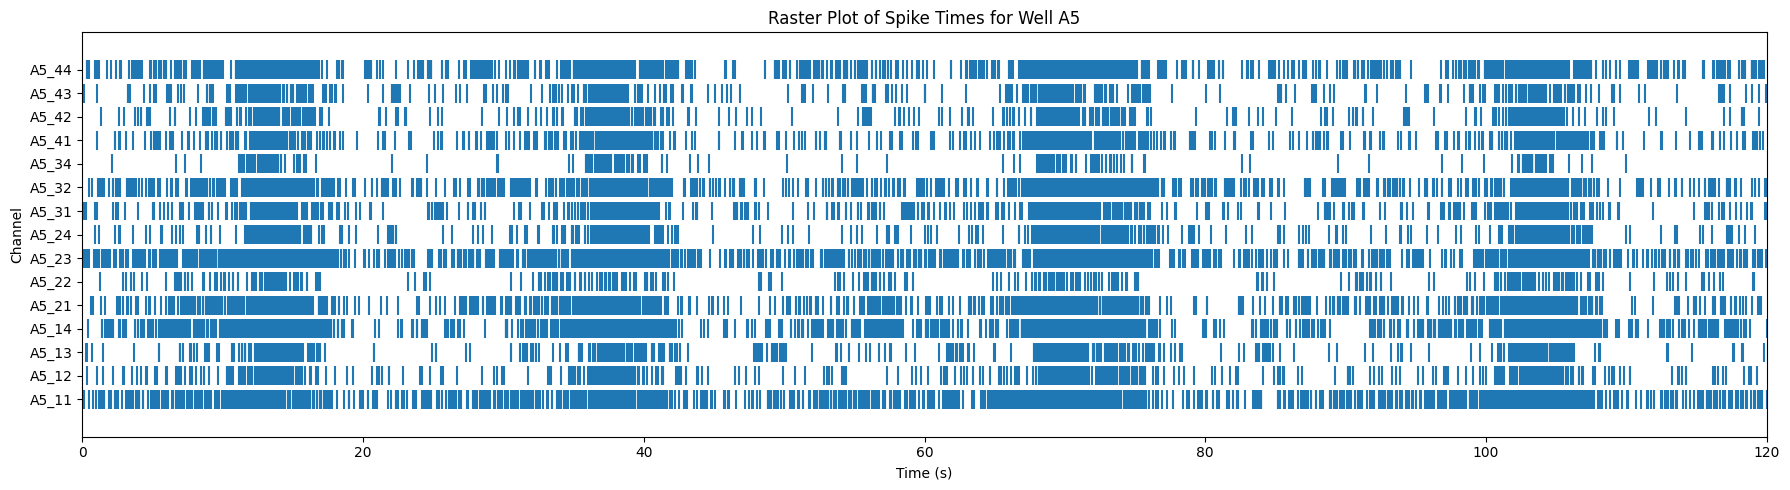

In [5]:
recording_per_ch_A5 = recording_per_ch[recording_per_ch["well"] == "A5"].reset_index(drop=True)
plot_spikes(recording_per_ch_A5, duration=120, well="A5")

In [6]:
recording_per_ch_A5

,Channel,Time,well,channel,spike_count
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1....",A5,11,19572
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2...",A5,12,9228
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ...",A5,13,5365
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1...",A5,14,23267
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62...",A5,21,11932
5,A5_22,"[1.27584, 2.92672, 3.14424, 3.46696, 3.71912, ...",A5,22,2977
6,A5_23,"[0.14096, 0.19104, 0.36968, 0.46536, 0.84968, ...",A5,23,14027
7,A5_24,"[0.89104, 1.19424, 2.36192, 2.598, 2.69712, 3....",A5,24,6599
8,A5_31,"[0.10256, 0.27464, 0.2792, 0.93864, 1.0784, 2....",A5,31,7202
9,A5_32,"[0.512, 0.69528, 1.13296, 1.29328, 1.42896, 1....",A5,32,9545


**Ungroup the spikes by channel and plot the histogram of spike times for well A5.**

In [7]:
# merge and sort the spike times from all channels in well A5
spike_time_stamps_A5 = []
for channel in recording_per_ch_A5["Channel"].unique():
    channel_spikes = recording_per_ch_A5[recording_per_ch_A5["Channel"] == channel]["Time"].tolist()[0]
    spike_time_stamps_A5.extend(channel_spikes)
spike_time_stamps_A5 = np.sort(spike_time_stamps_A5)

In [8]:
spike_time_stamps_A5

array([9.83200000e-02, 1.02560000e-01, 1.39360000e-01, ...,
       1.79985016e+03, 1.79988656e+03, 1.79994968e+03], shape=(154174,))

### Helper function: recording_per_ch -> spike_time_stamps

In [9]:
def get_spike_time_stamps(recording_per_ch):
    spike_time_stamps = [
        spike
        for spikes in recording_per_ch["Time"]
        for spike in spikes
    ]

    return np.sort(spike_time_stamps) 

In [10]:
spike_time_stamps_A5 = get_spike_time_stamps(recording_per_ch_A5)
spike_time_stamps_A5

array([9.83200000e-02, 1.02560000e-01, 1.39360000e-01, ...,
       1.79985016e+03, 1.79988656e+03, 1.79994968e+03], shape=(154174,))

(0.0, 120.0)

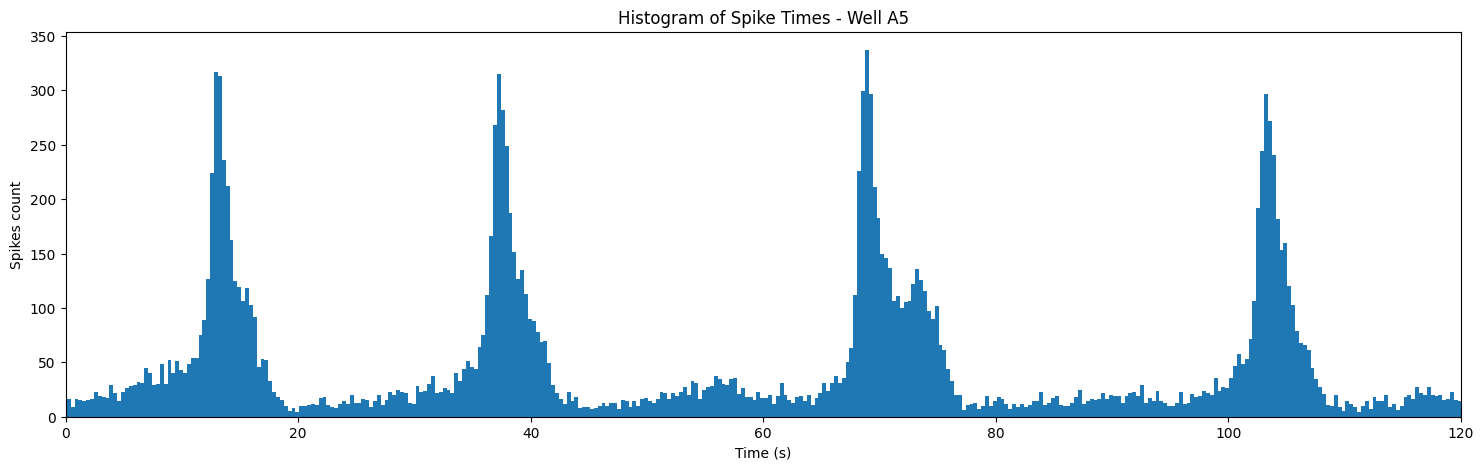

In [11]:
plt.figure(figsize=(18, 5))
plt.hist(spike_time_stamps_A5, bins=30 * 60 * 3)
plt.title("Histogram of Spike Times - Well A5")
plt.xlabel("Time (s)")
plt.ylabel("Spikes count")
plt.xlim(0, 120)

## `ISIn` algorithm: Probability of Burst of $N$ Spikes happens within a particular time window $isi_N$[ms].


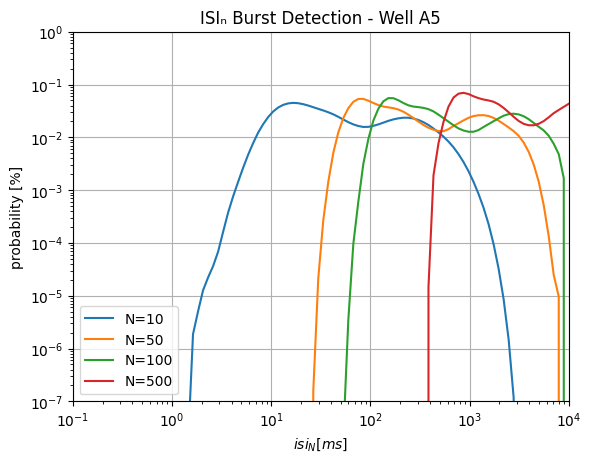

In [12]:
ax = BurstDetector.plot(
        spiketime=spike_time_stamps_A5,
        n_list=[10, 50, 100, 500],
    )

plt.title(f"ISIₙ Burst Detection - Well A5")

plt.show()

### ISIₙ Burst Detection — Explanation - (Bakkum, 2014)

network burst can ba simple defined as as ≥50 spikes with an ISI of ≤100 ms, involving
at least 35% of the electrode array within a 20 ms window inside the candidate burst. Here we will explain more sophisticated method called `ISIn` (Inter-Spike Interval of N spikes) which is a generalization of the ISI-based burst detection method.

Let spike times (sorted, in ms) be:

$
t_1, t_2, \dots, t_M
$

where $M$ is the total number of spikes.


#### 1️. Compute $ \mathrm{ISI}_N $

Choose a value of $N$.

$
\mathrm{ISI}_N(i) = t_{i+N-1} - t_i
$

for

$
i = 1, 2, \dots, M - (N-1)
$

Interpretation:

> Time required for **N consecutive spikes** to occur.

Total number of values:

$
M - (N-1)
$

This is a sliding window over spikes.


### 2️. Build Histogram

1. Compute all $ \mathrm{ISI}_N $ values.
2. Use log-spaced bins.
3. Normalize counts to probabilities.
4. Plot on log–log axes.

The histogram answers:

> How often does the network produce N spikes within X milliseconds?

#### 3️. Interpretation

- `Small ISIₙ (left side)` → spikes packed tightly → burst-like
- `Large ISIₙ (right side)` → spikes spread out → background/tonic

If bursts exist, the histogram often shows:

- A left peak (burst regime)
- A right peak (non-burst regime)
- A valley between them

The valley is used as the **threshold** the balance between `sensitivity` and `specificity`.

#### 4️. What Changing N Does

Increasing $N$:

- Measures longer spike blocks
- Smooths variability
- Emphasizes sustained high-rate activity
- Suppresses small, noisy fluctuations

Mathematically:

$
\mathrm{ISI}_N = \sum_{k=0}^{N-2} \mathrm{ISI}_2(i+k)
$

So larger $N$ averages over more local ISIs.


#### 5️. How to Decide Which N is Better

There is no universally "correct" N.  
You choose N based on separation quality and biological meaning.

- A `good N` shows:

  - Clear bimodality
  Two distinguishable regimes (burst vs background).

  - Deep valley between regimes
  A stable threshold can be placed.

  - Stable threshold location
  Small data perturbations don’t move the valley much.

  - Burst duration matches biology
  Detected bursts should align with known network dynamics.

- Practical Intuition from our Plot shown above

  - Small N (e.g., 10)  
    - Sensitive to short bursts  
    - May include noise  
    - Sometimes weaker separation  

  - Medium N (50–100)  
    - Often strongest separation  
    - Good compromise  
    - Robust threshold  

  - Very large N (500)  
    - Detects only very large bursts  
    - Ignores small ones  
    - Histogram shifts right (requires long sustained activity)

 
- Conceptual Rule of Thumb

  - Choose N approximately equal to:

    > The minimum number of spikes that you biologically consider a burst.

  - Examples:

    - Small network bursts → N ≈ 10–50  
    - Large synchronized events → N ≈ 50–200  
    - Only very strong global events → N ≥ 200  


### Practical Strategy

1. Plot several N values (as we did).
2. Look for:
   - Strongest bimodal structure
   - Most stable valley
3. Run detection for each N.
4. Compare:
    - Alignment with raw raster plots
   - Number of bursts
   - Burst durations
   
The best N produces bursts that:

- Match visual inspection - shows balanced sensitivity/specificity in burst detection
- Are robust to small threshold changes

### Burst detection for well A5

In [13]:
n = 10
threshold = 100
duration = 45 #sec

In [14]:
bursts = BurstDetector.detect(spiketime=spike_time_stamps_A5, n=n, threshold=threshold)

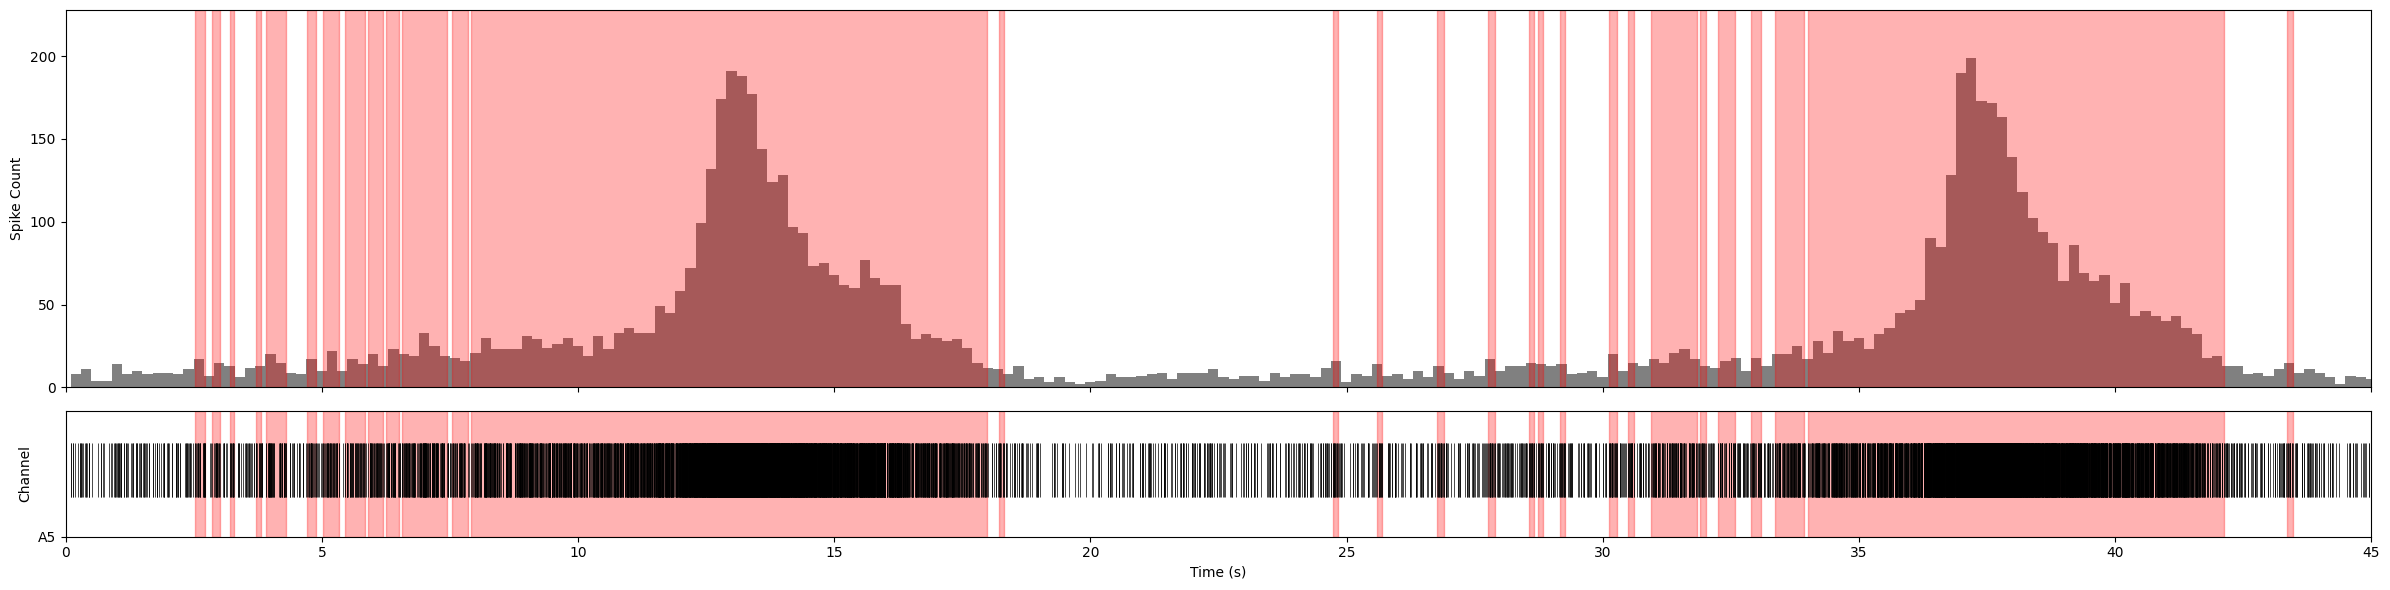

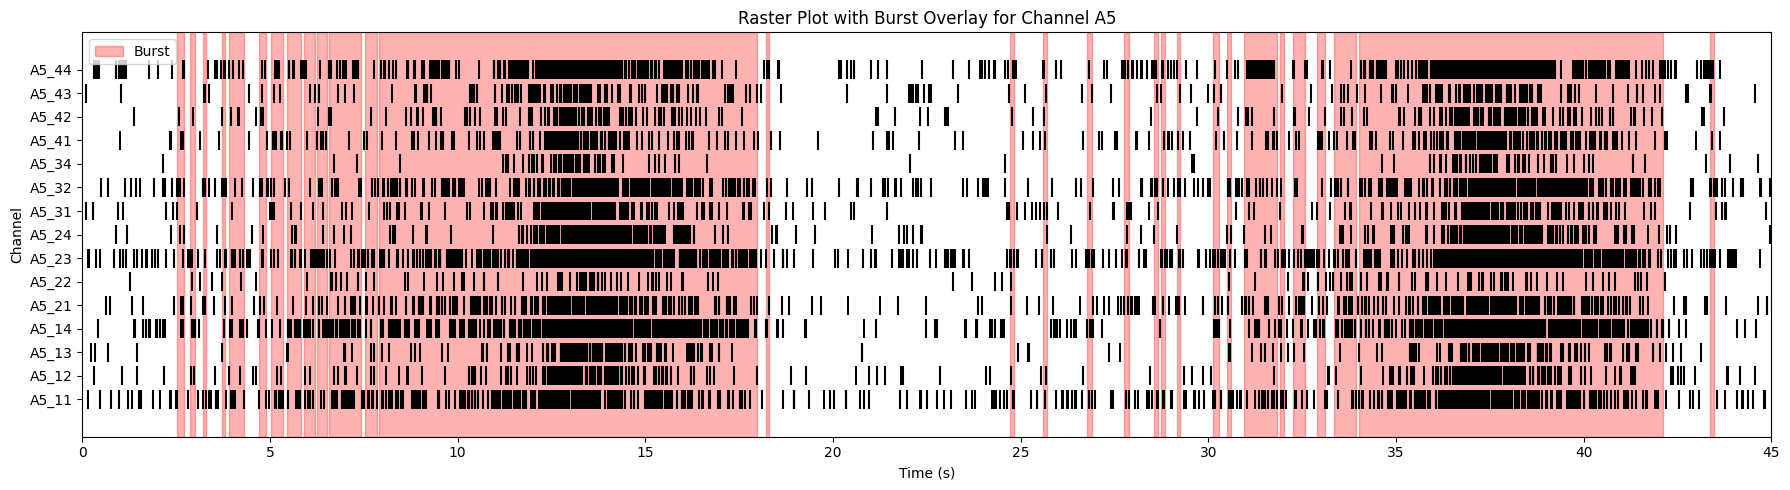

In [15]:
plot_histogram_with_bursts(spike_time_stamps_A5, bursts=bursts, duration=duration, well="A5")
plot_spikes_with_bursts(recording_per_ch_A5, bursts, duration=duration, well="A5")

### ISIₙ graph for all wells

| Class | Label | Condition    | Description               | Well  |
|:-----:|:-----:|:-------------|:----------------|:----------------|
| 0     | 0     | Control      | Healthy                   | C5-C8 |
| 1     | 1     | Gabazine     | Hyper                     | A5-A8 |
| 2     | 1     | Kainic Acid  | Hyper                     | B5-B8 |
| 4     | 2     | GABA         | Hypo                      | D5-D8 |
| 5     | 2     | CNQX         | Hypo                      | E5-E8 |
| 6     | 2     | D-AP5        | Hypo                      | F5-F8 |


In [16]:
classnames = [1,1,1,1,2,2,2,2,0,0,0,0,4,4,4,4,5,5,5,5,6,6,6,6]
wells = ["A5", "A6", "A7", "A8", 
         "B5", "B6", "B7", "B8", 
         "C5", "C6", "C7", "C8", 
         "D5", "D6", "D7", "D8", 
         "E5", "E6", "E7", "E8",
         "F5", "F6", "F7", "F8"]

labels = [1, 1, 1, 1, 
          1, 1, 1, 1, 
          0, 0, 0, 0, 
          2, 2, 2, 2, 
          2, 2, 2, 2, 
          2, 2, 2, 2]

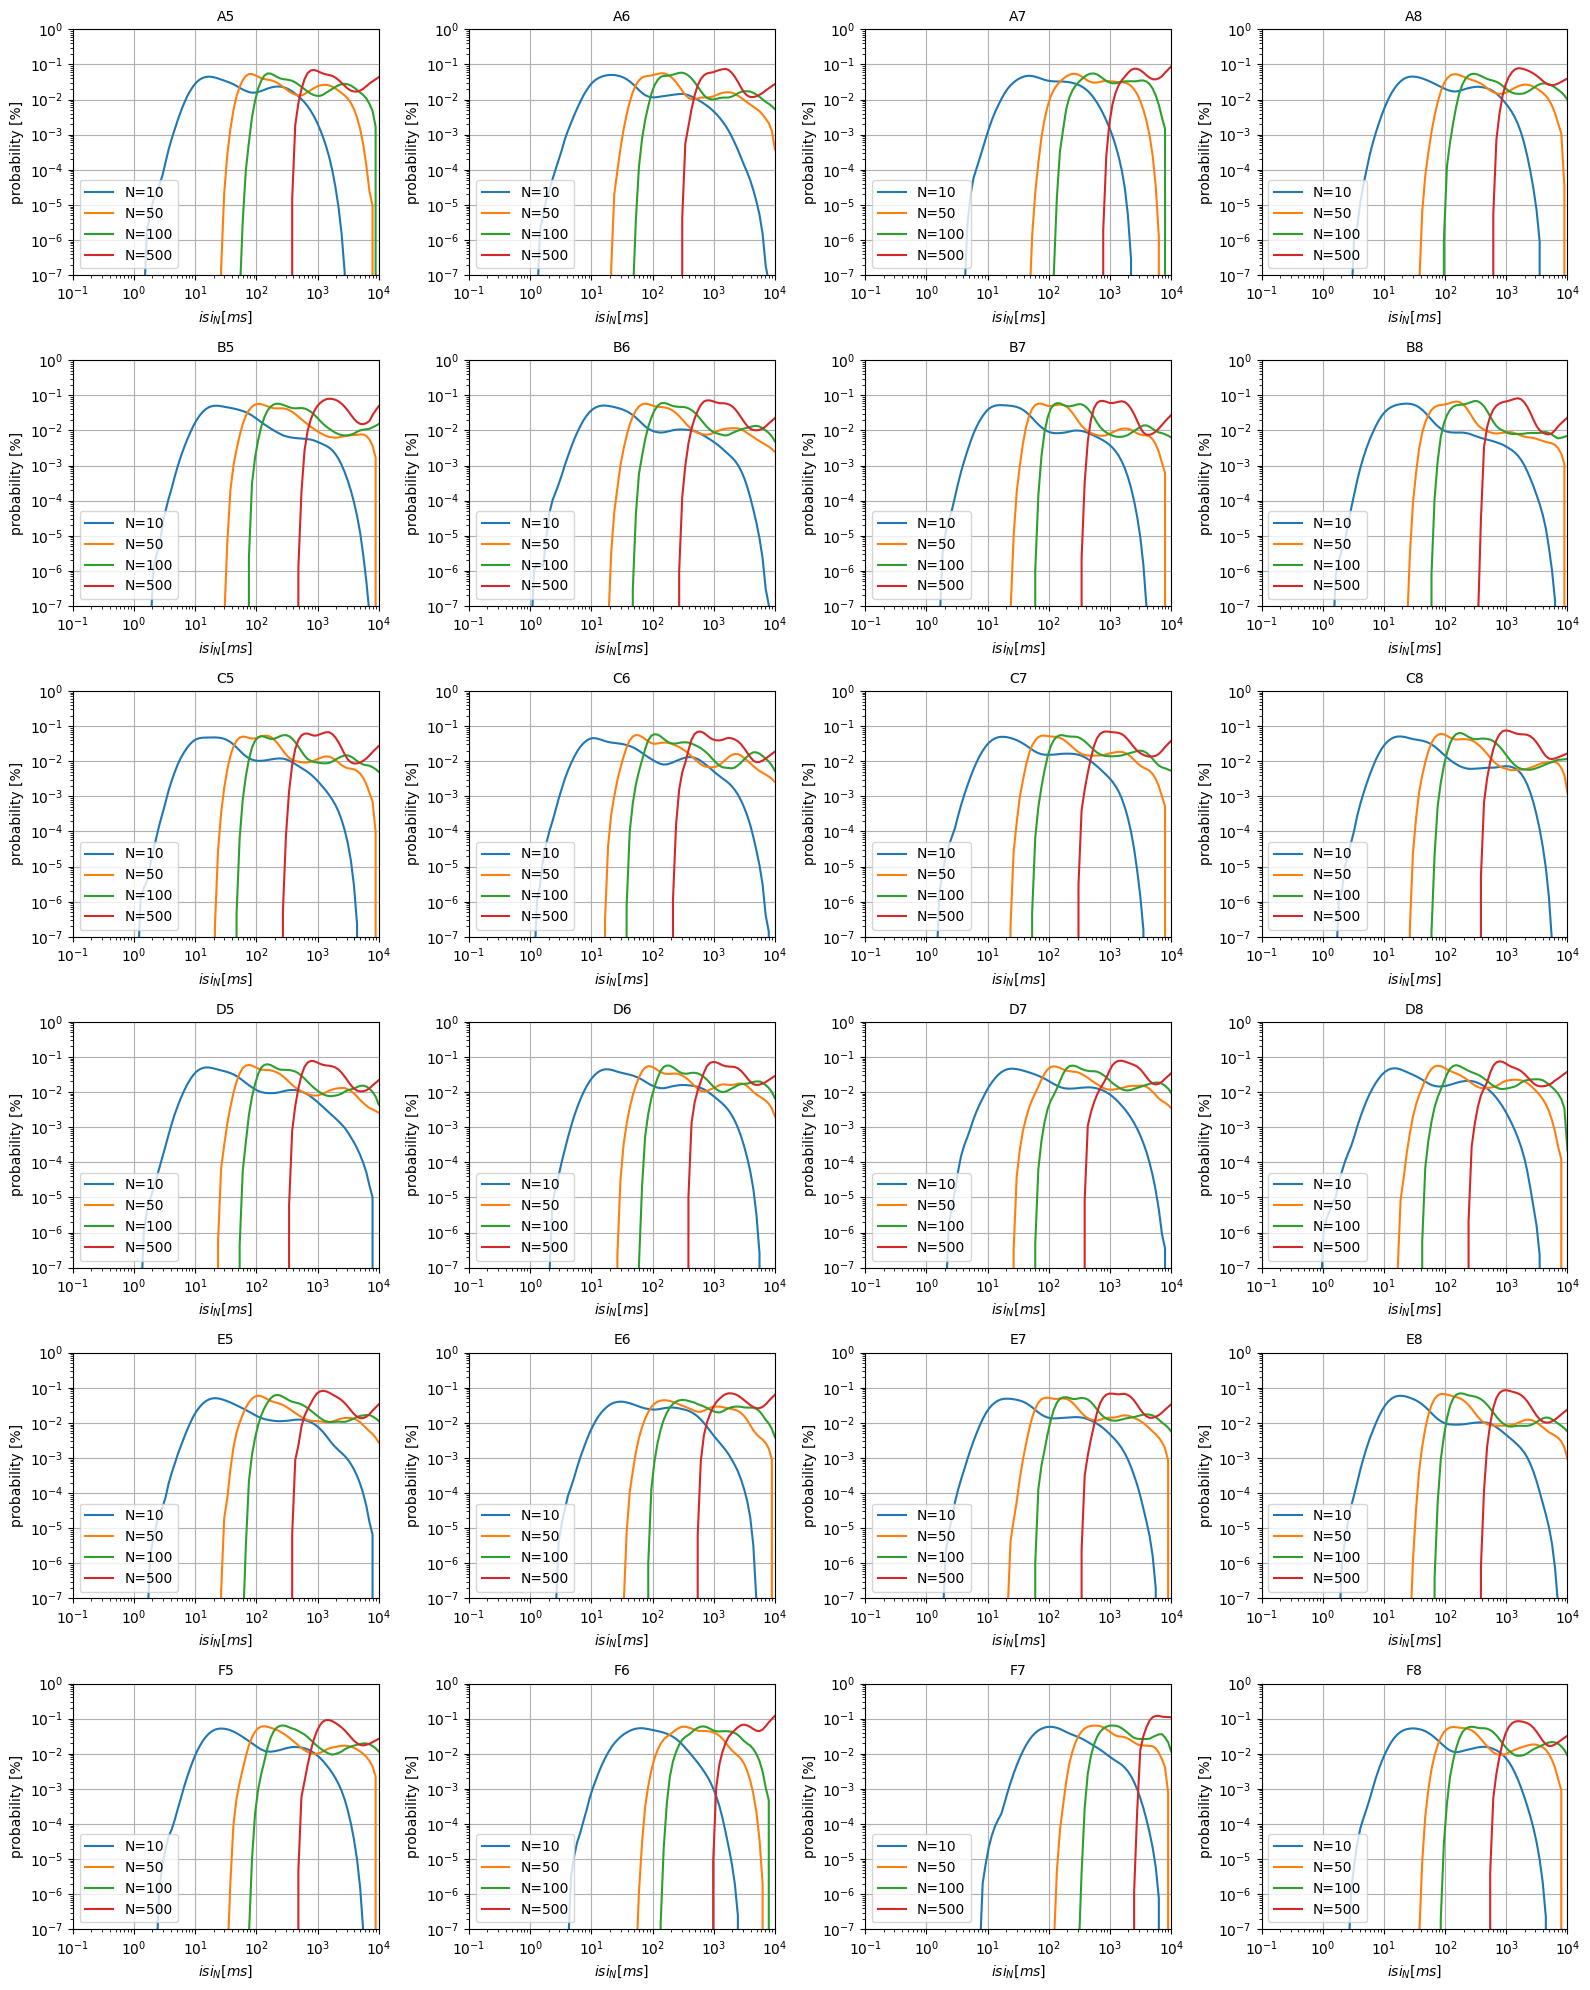

In [17]:
# Create figure with 6x4 subplots (24 wells total)
fig, axes = plt.subplots(6, 4, figsize=(16, 20))
axes = axes.flatten()

for idx, well in enumerate(wells):
    recording_per_ch_filtered = recording_per_ch[recording_per_ch["well"] == well].reset_index(drop=True)

    spike_time_stamps = get_spike_time_stamps(recording_per_ch_filtered)
    
    # Plot on the specific subplot
    ax = BurstDetector.plot(
        spiketime=spike_time_stamps  ,
        n_list=[10, 50, 100, 500],
        ax=axes[idx]  # Specify which axis to plot on
    )
    axes[idx].set_title(f"{well}", fontsize=10)

plt.tight_layout()
plt.show()

### Burst detection for all wells

In [18]:
n = 10

threshold_dict = {
    "A5": 100, "A6": 100, "A7": 100, "A8": 100,
    "B5": 200, "B6": 100, "B7": 100, "B8": 100,
    "C5": 100, "C6": 100, "C7": 100, "C8": 100,
    "D5": 100, "D6": 100, "D7": 100, "D8": 100,
    "E5": 100, "E6": 100, "E7": 100, "E8": 100,
    "F5": 150, "F6": 150, "F7": 150, "F8": 150,
}

duration = 30 #sec

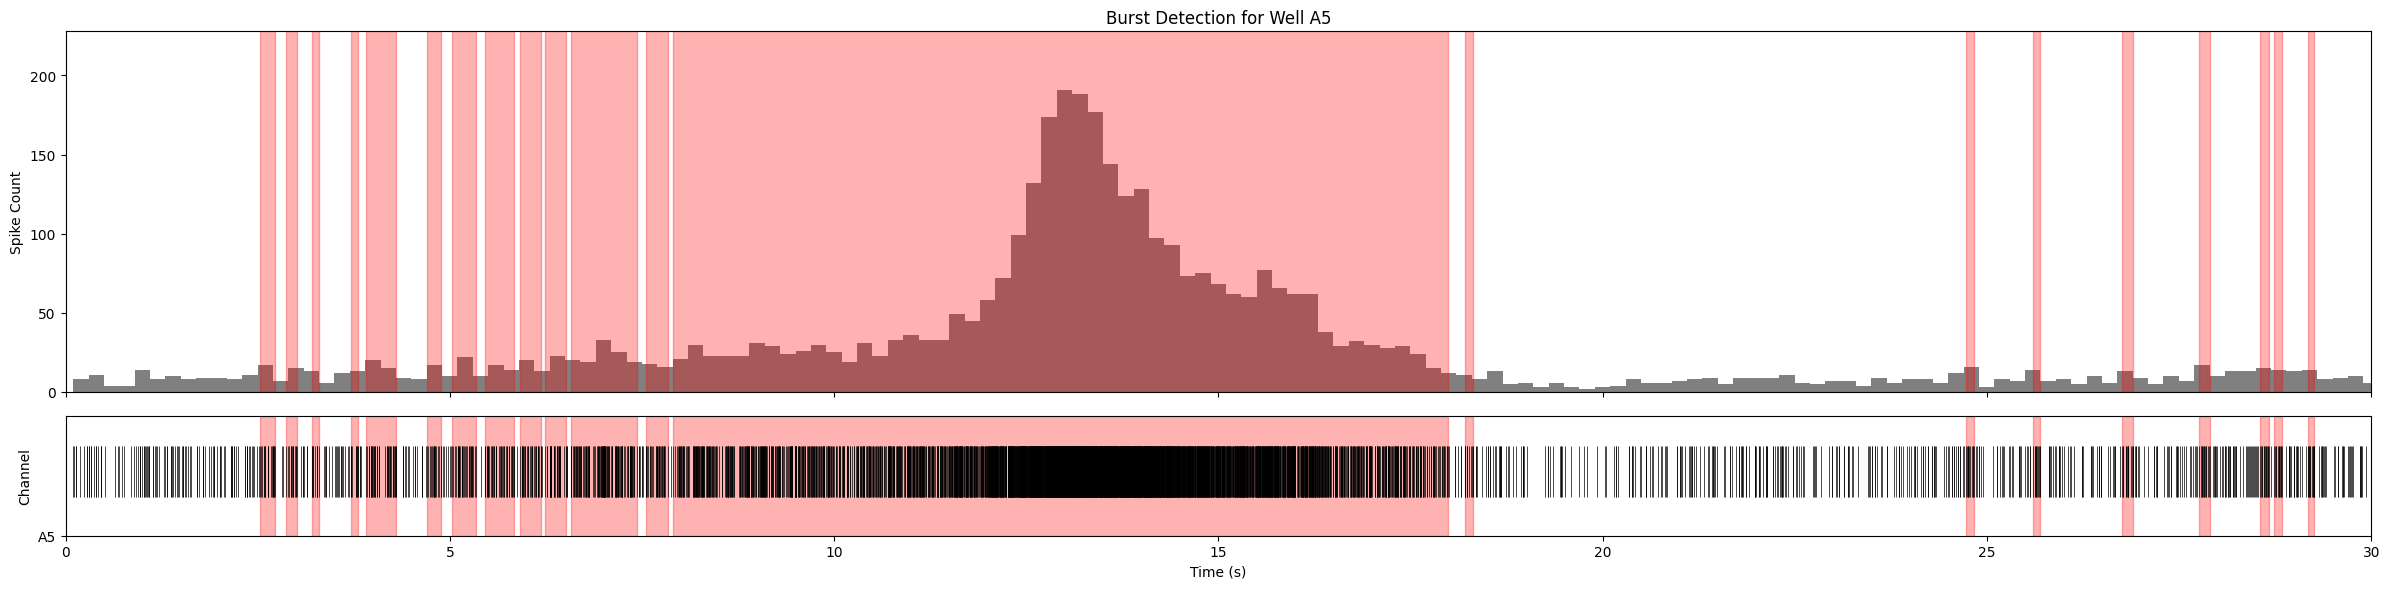

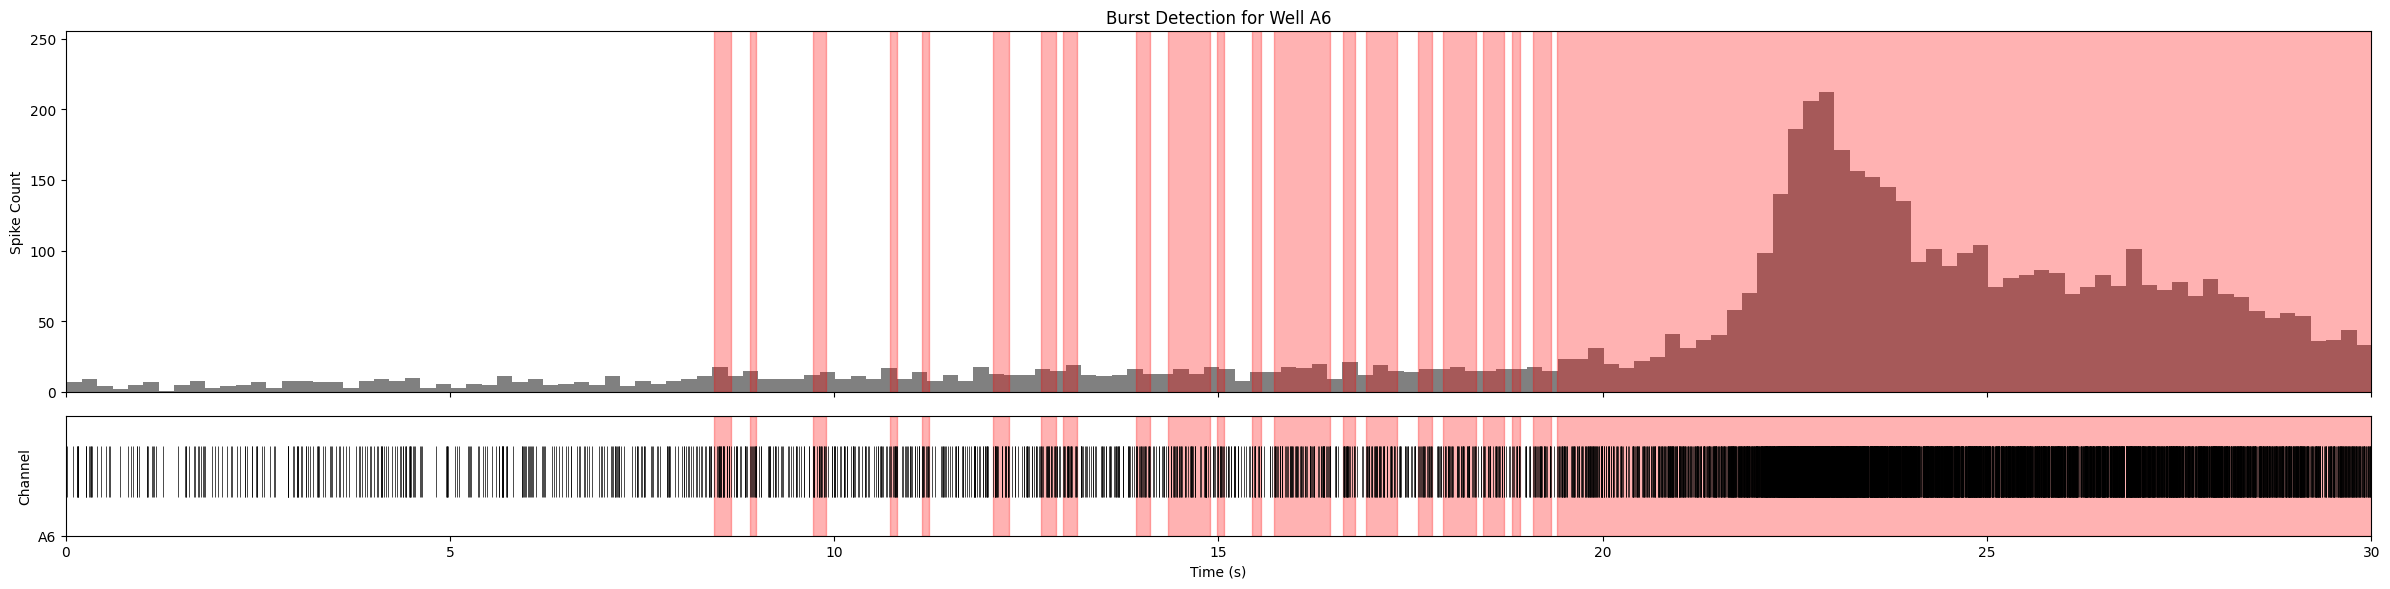

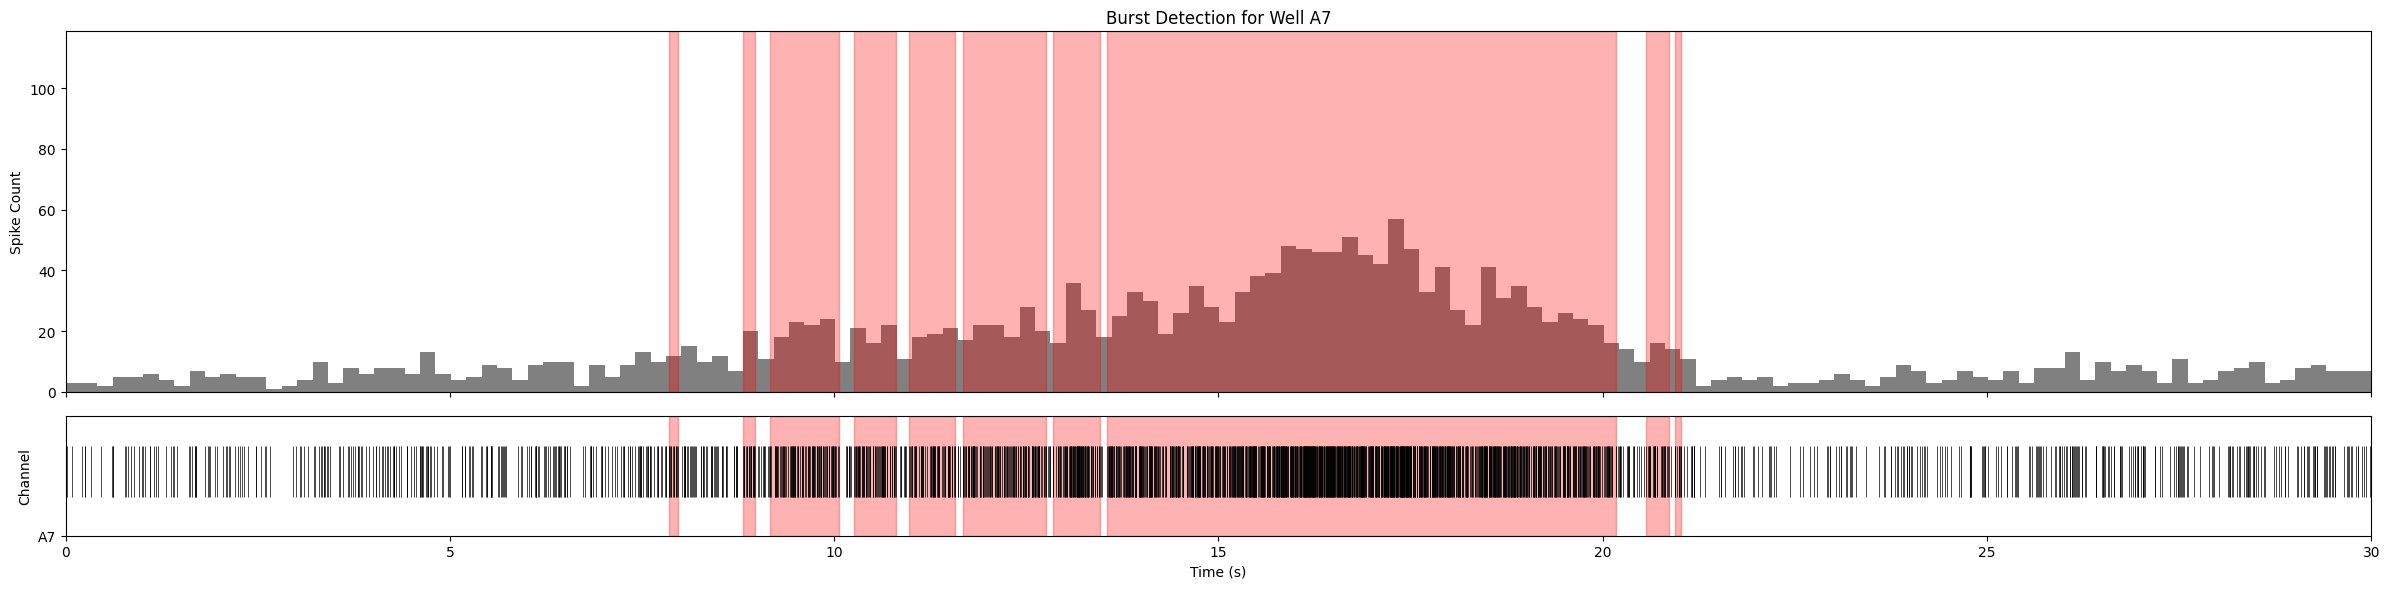

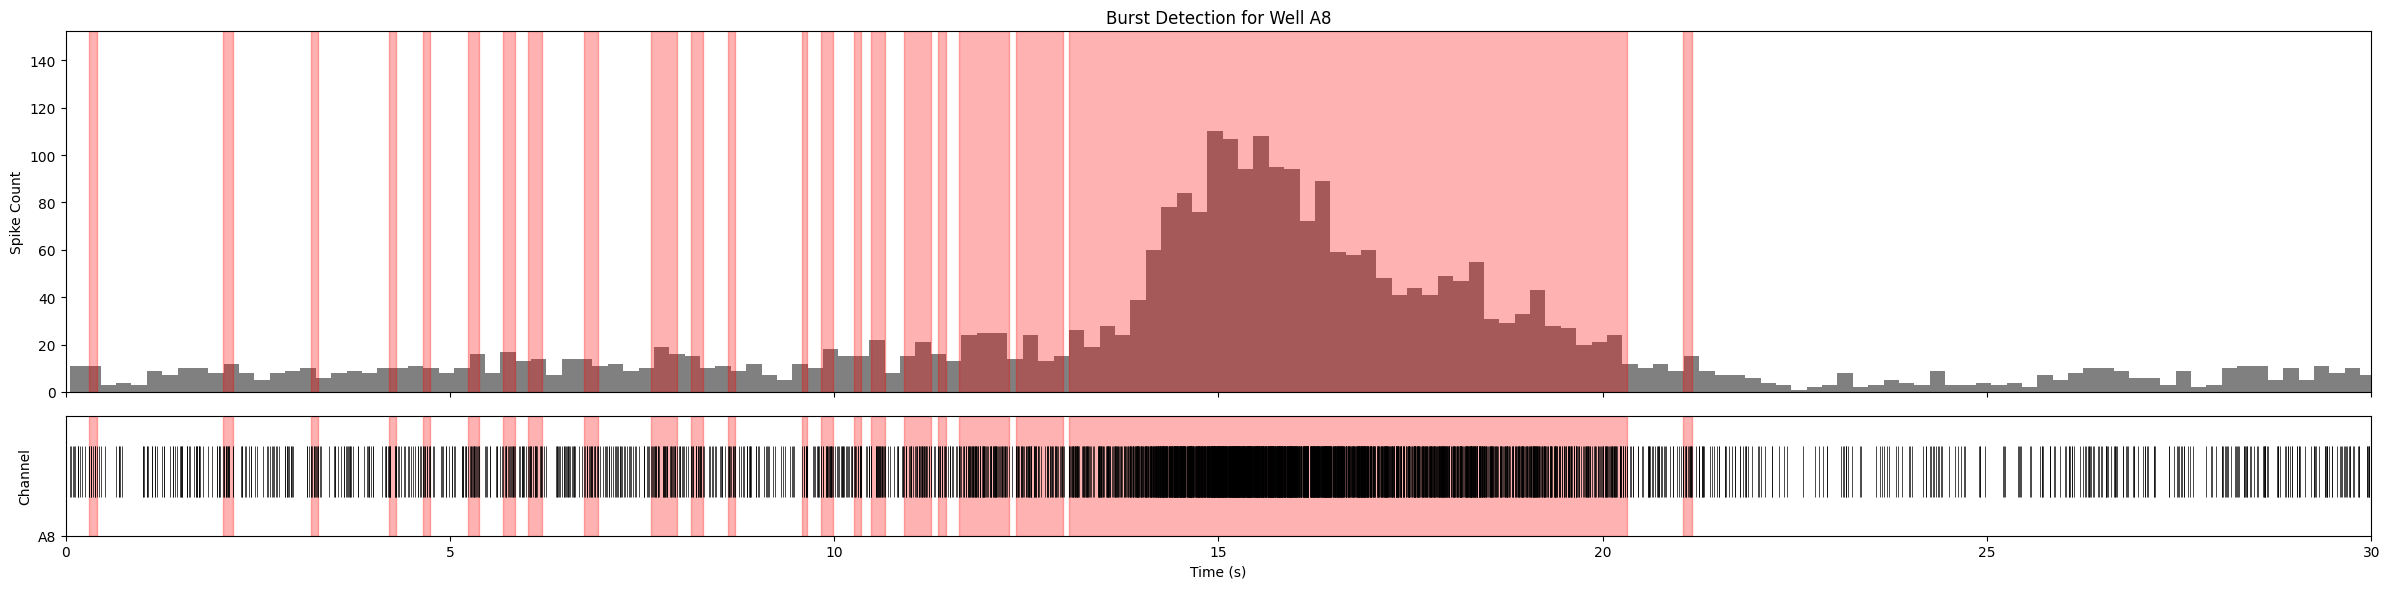

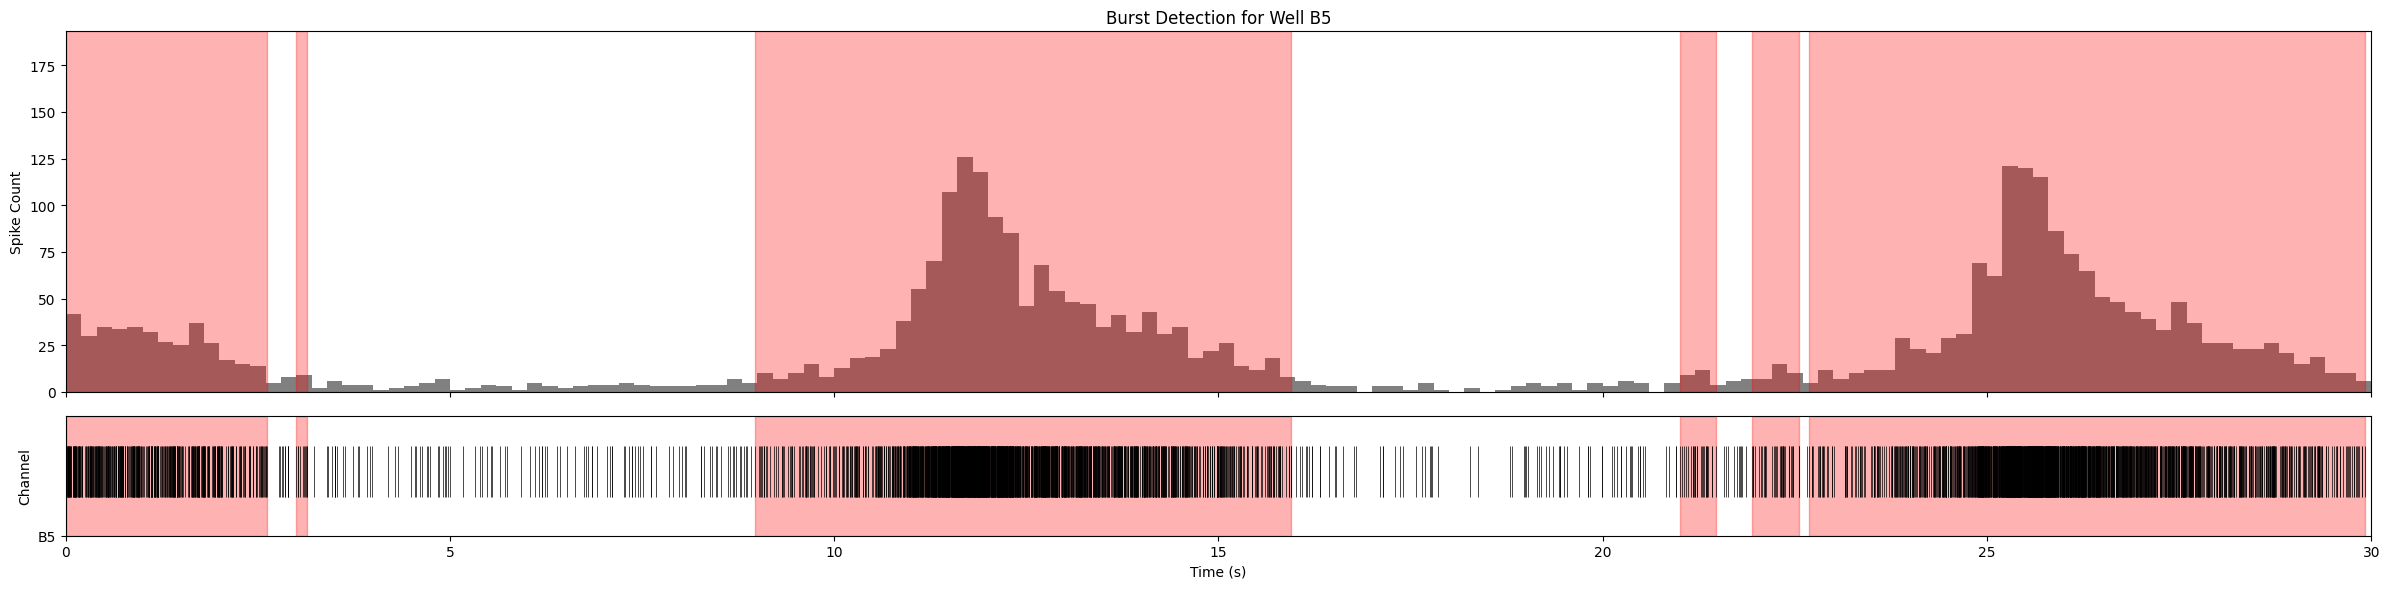

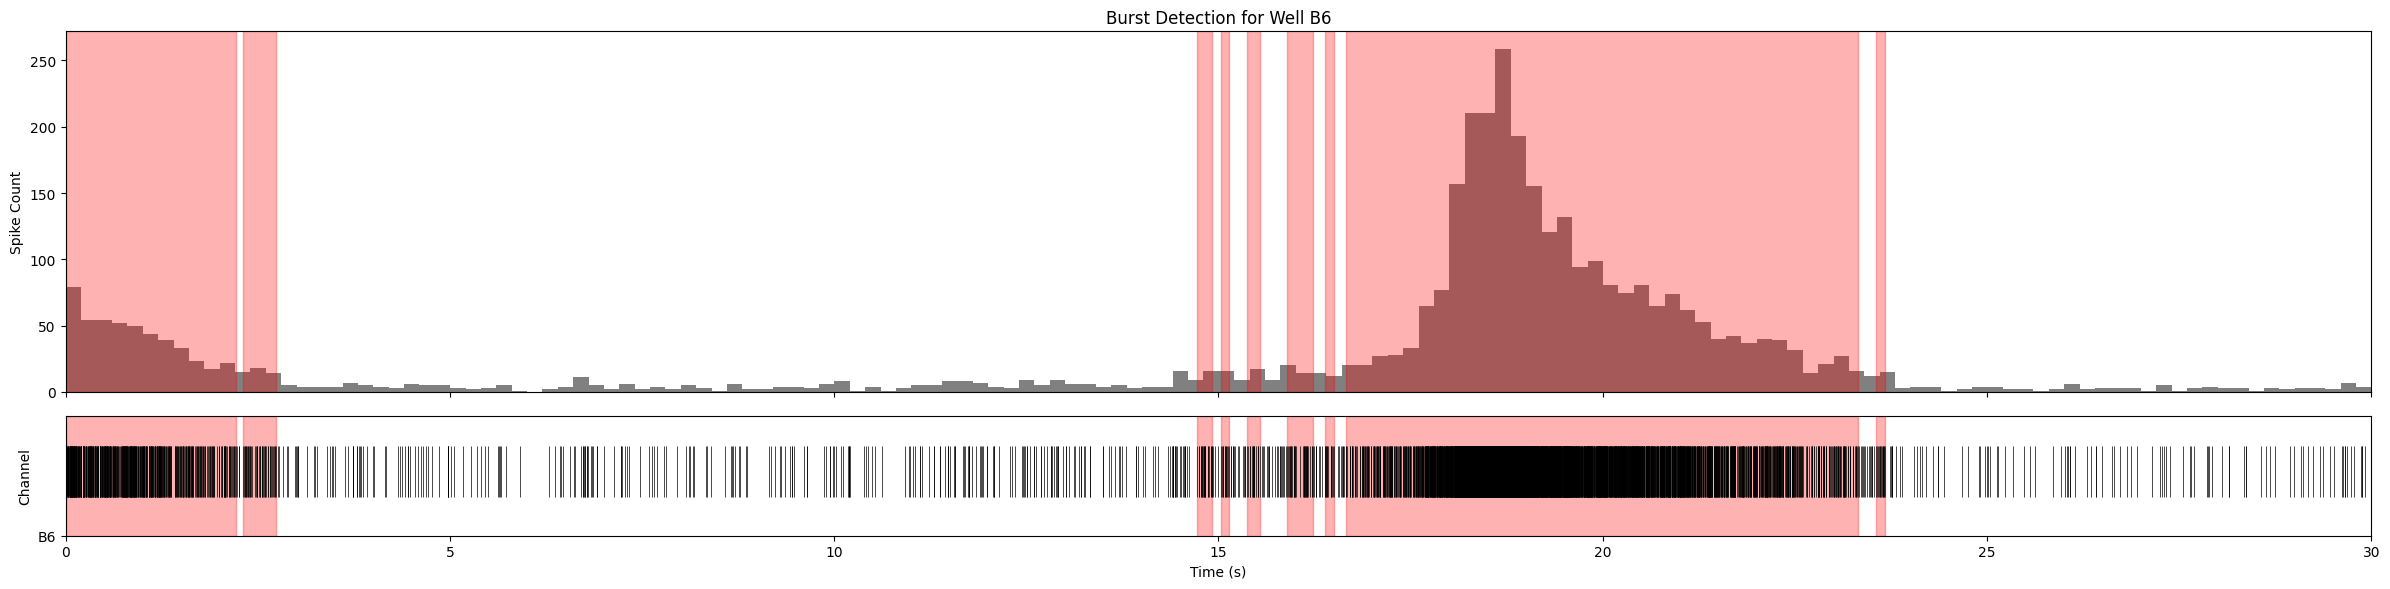

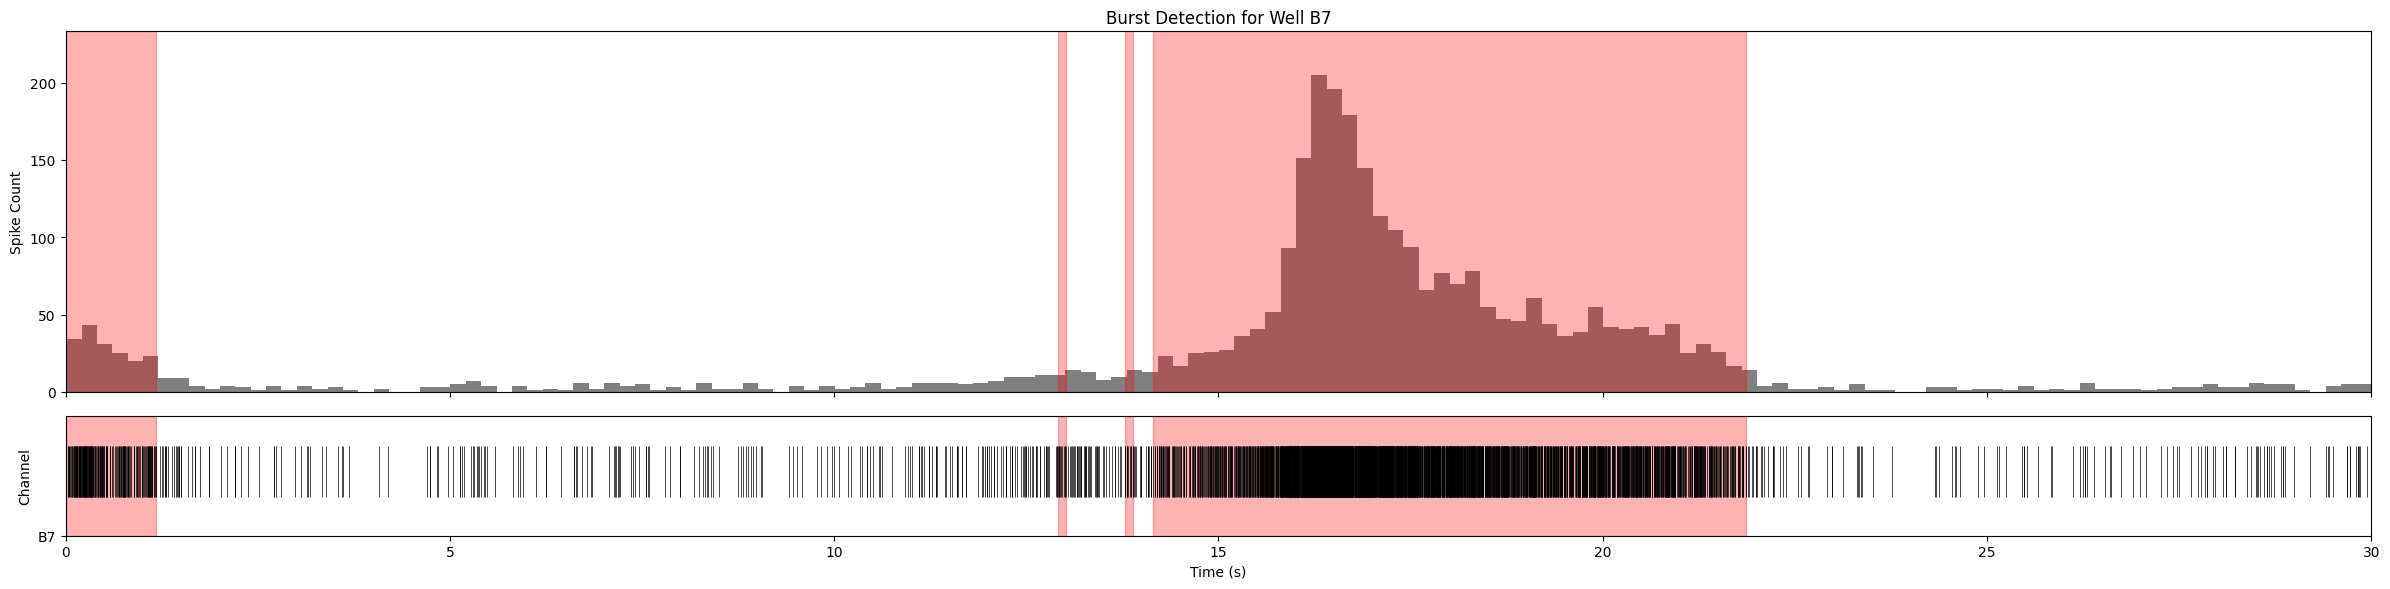

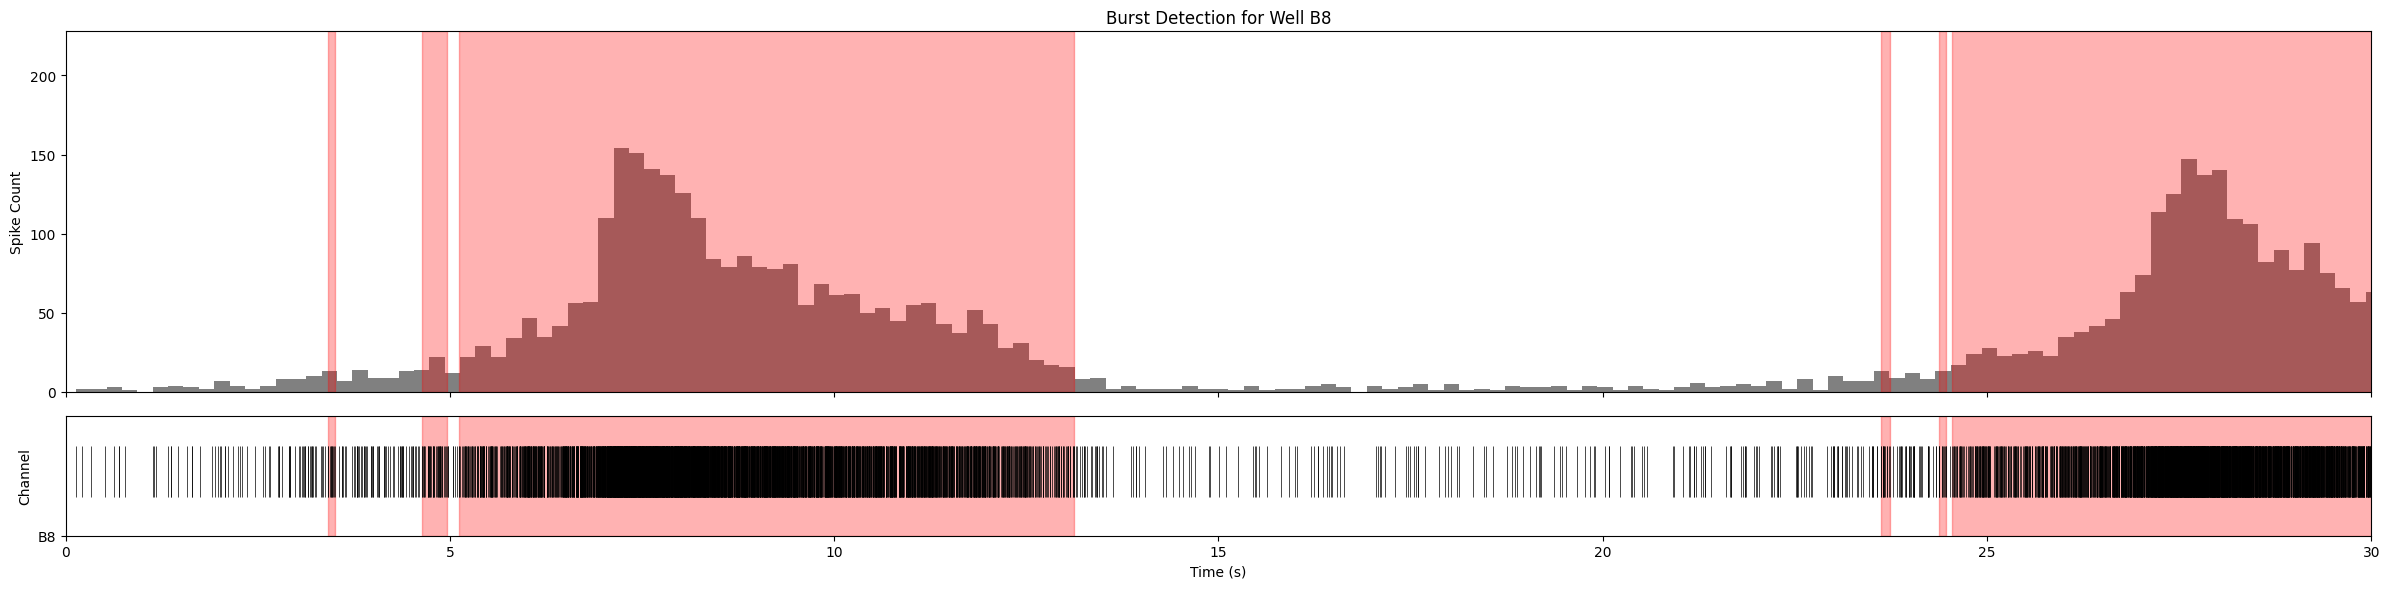

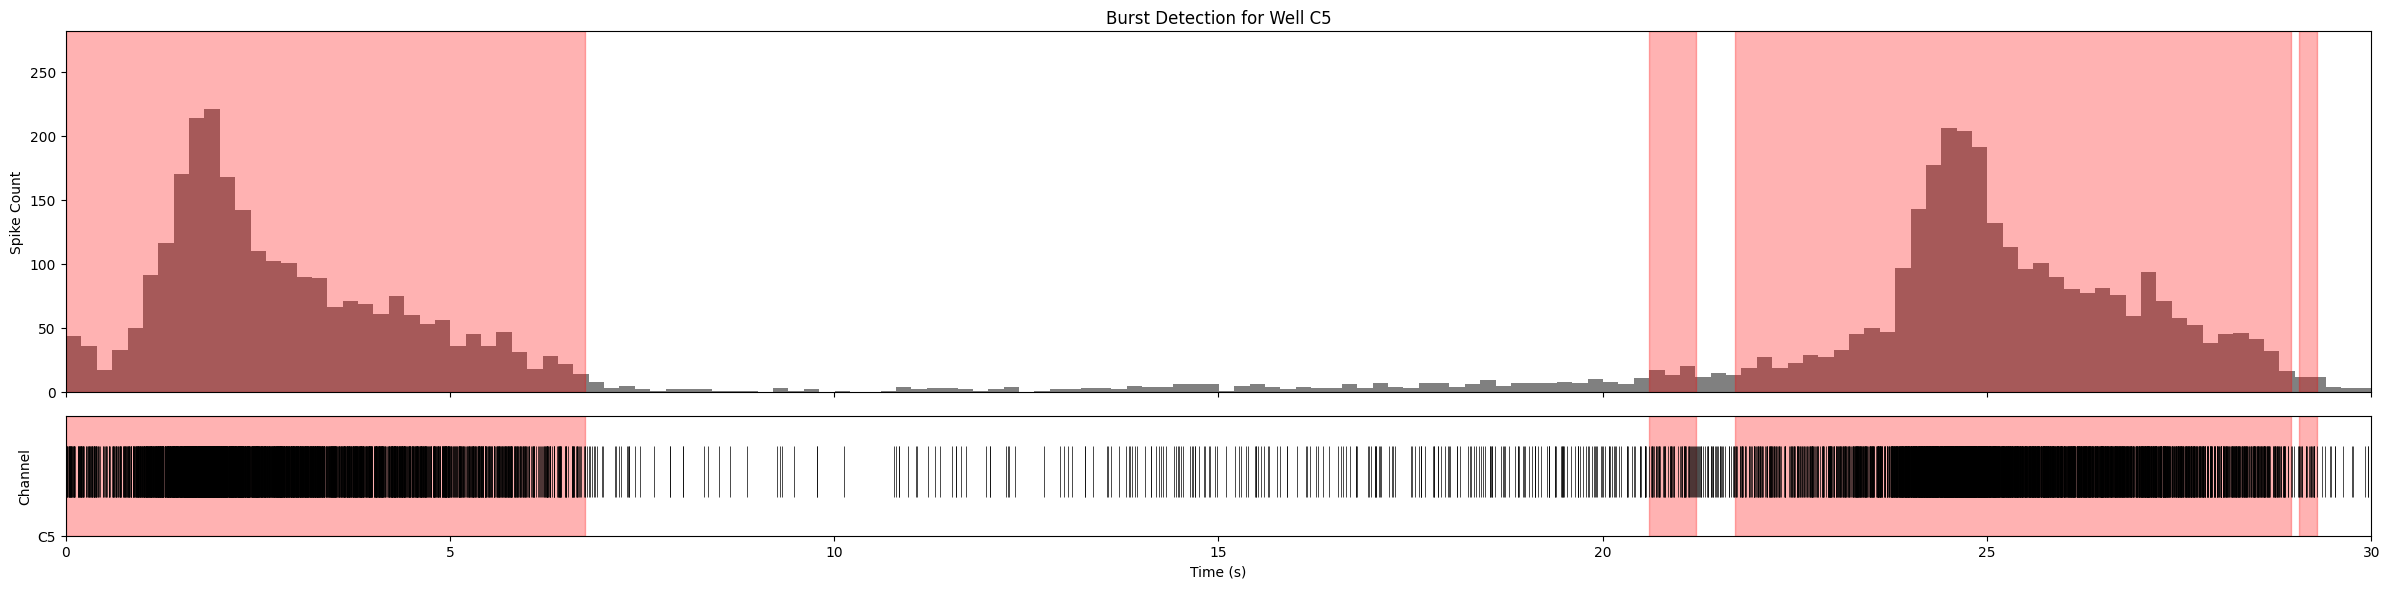

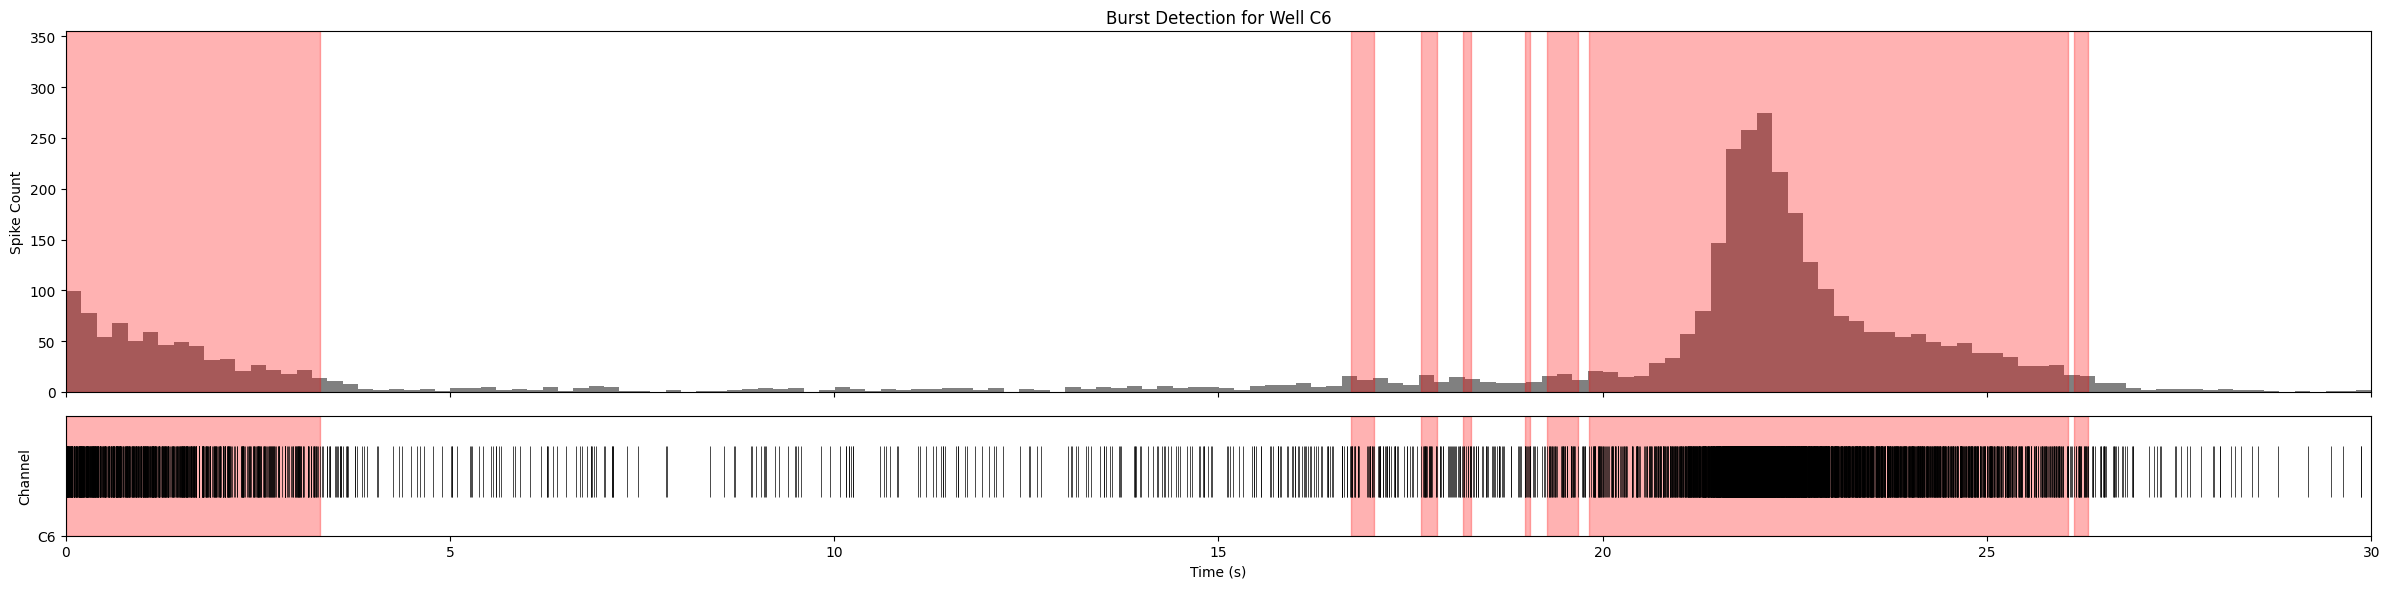

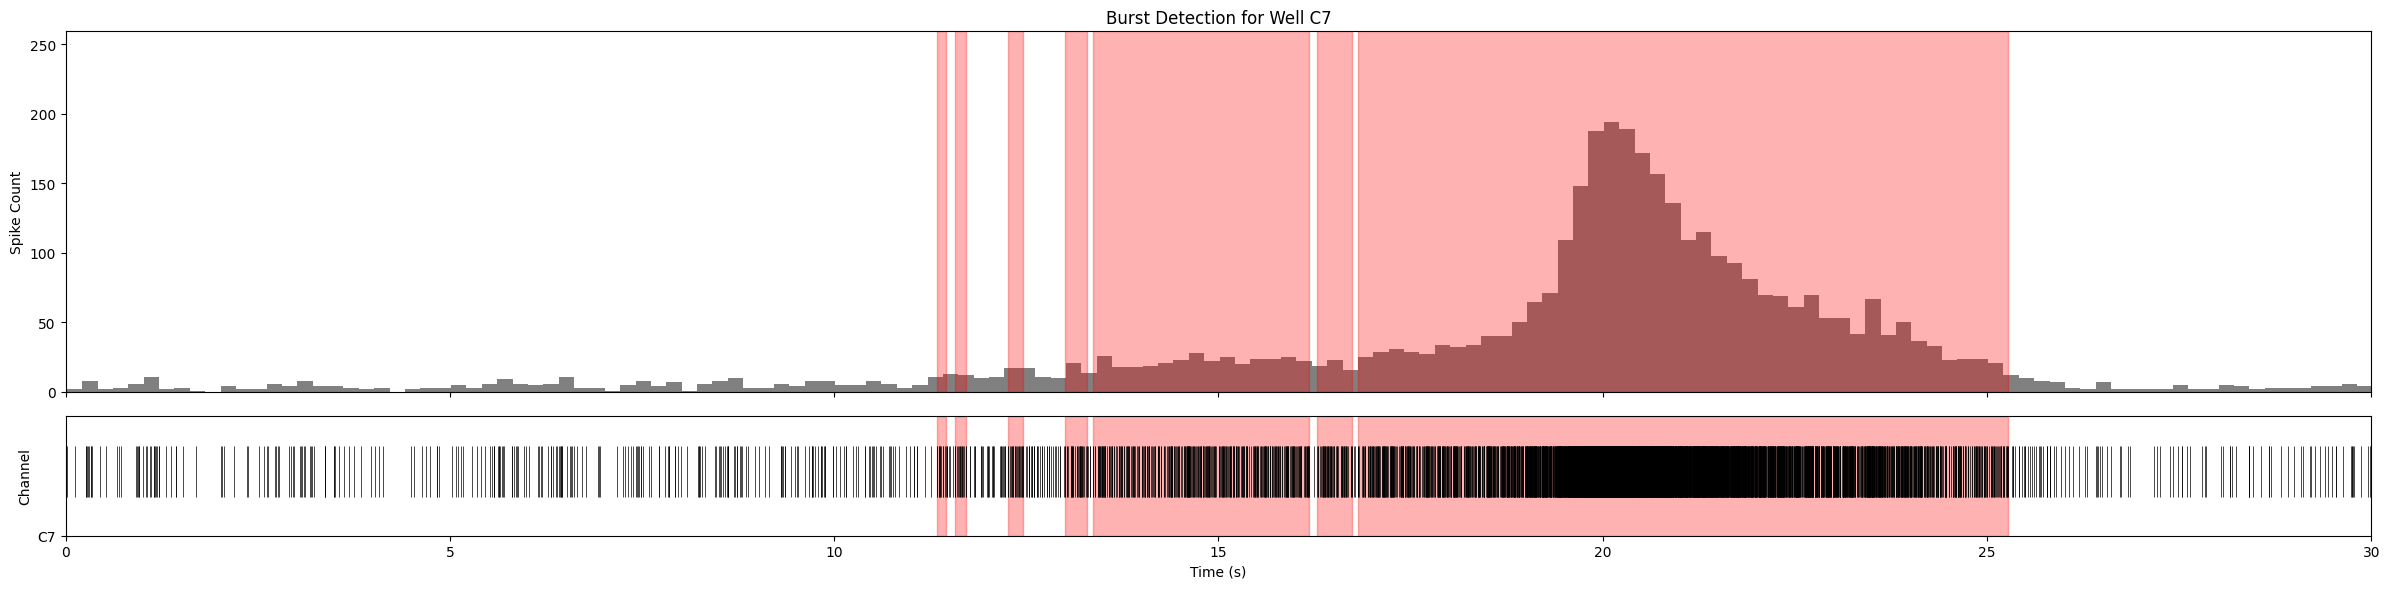

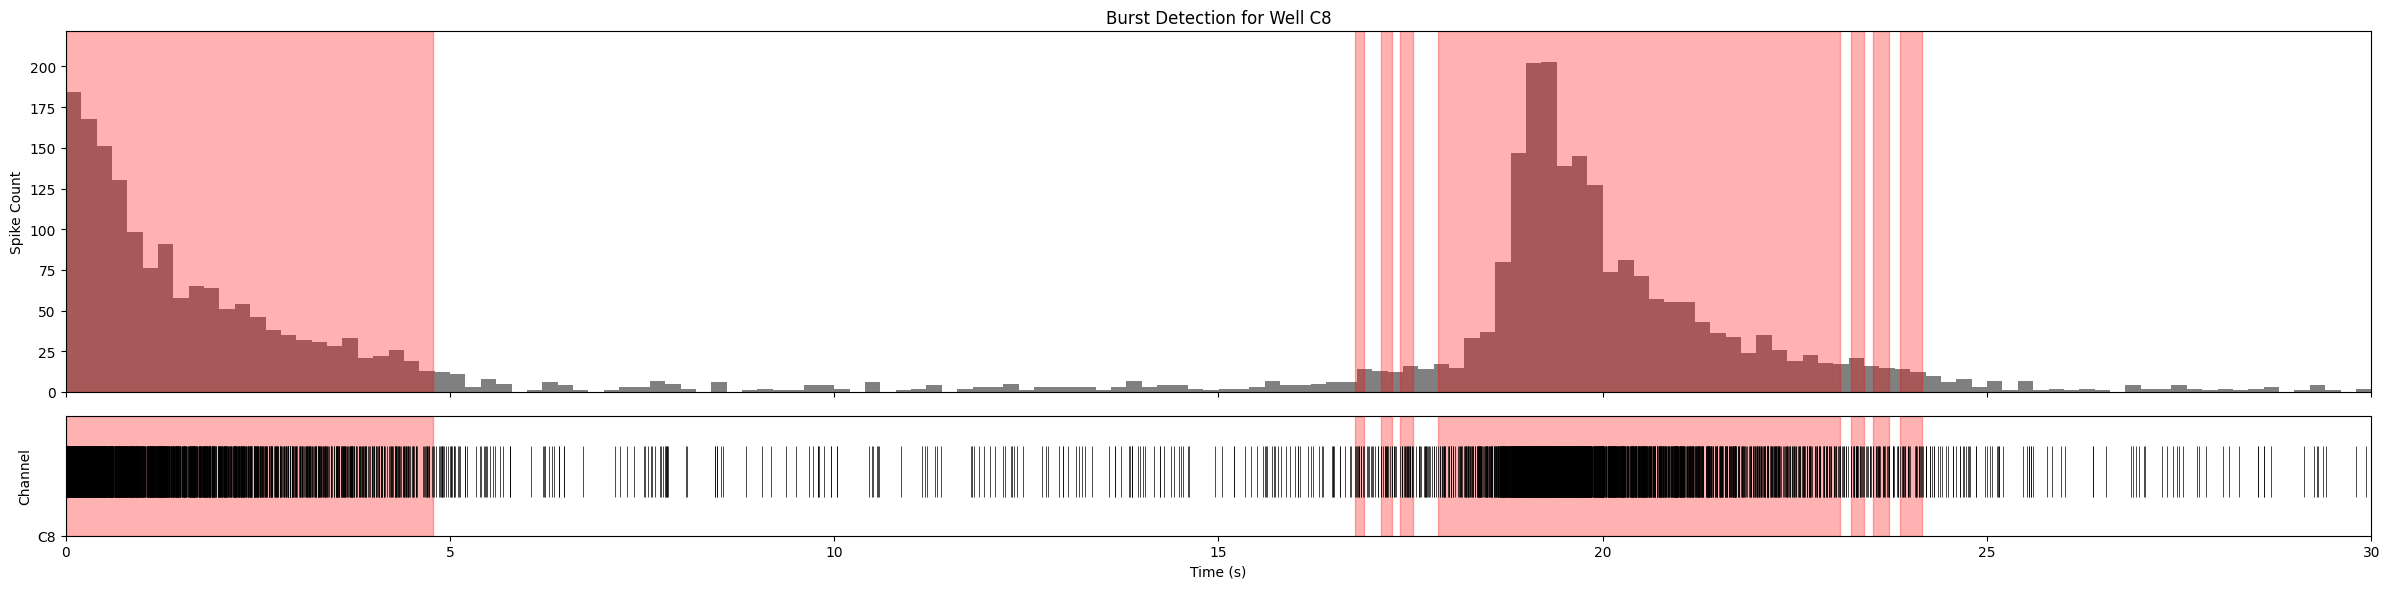

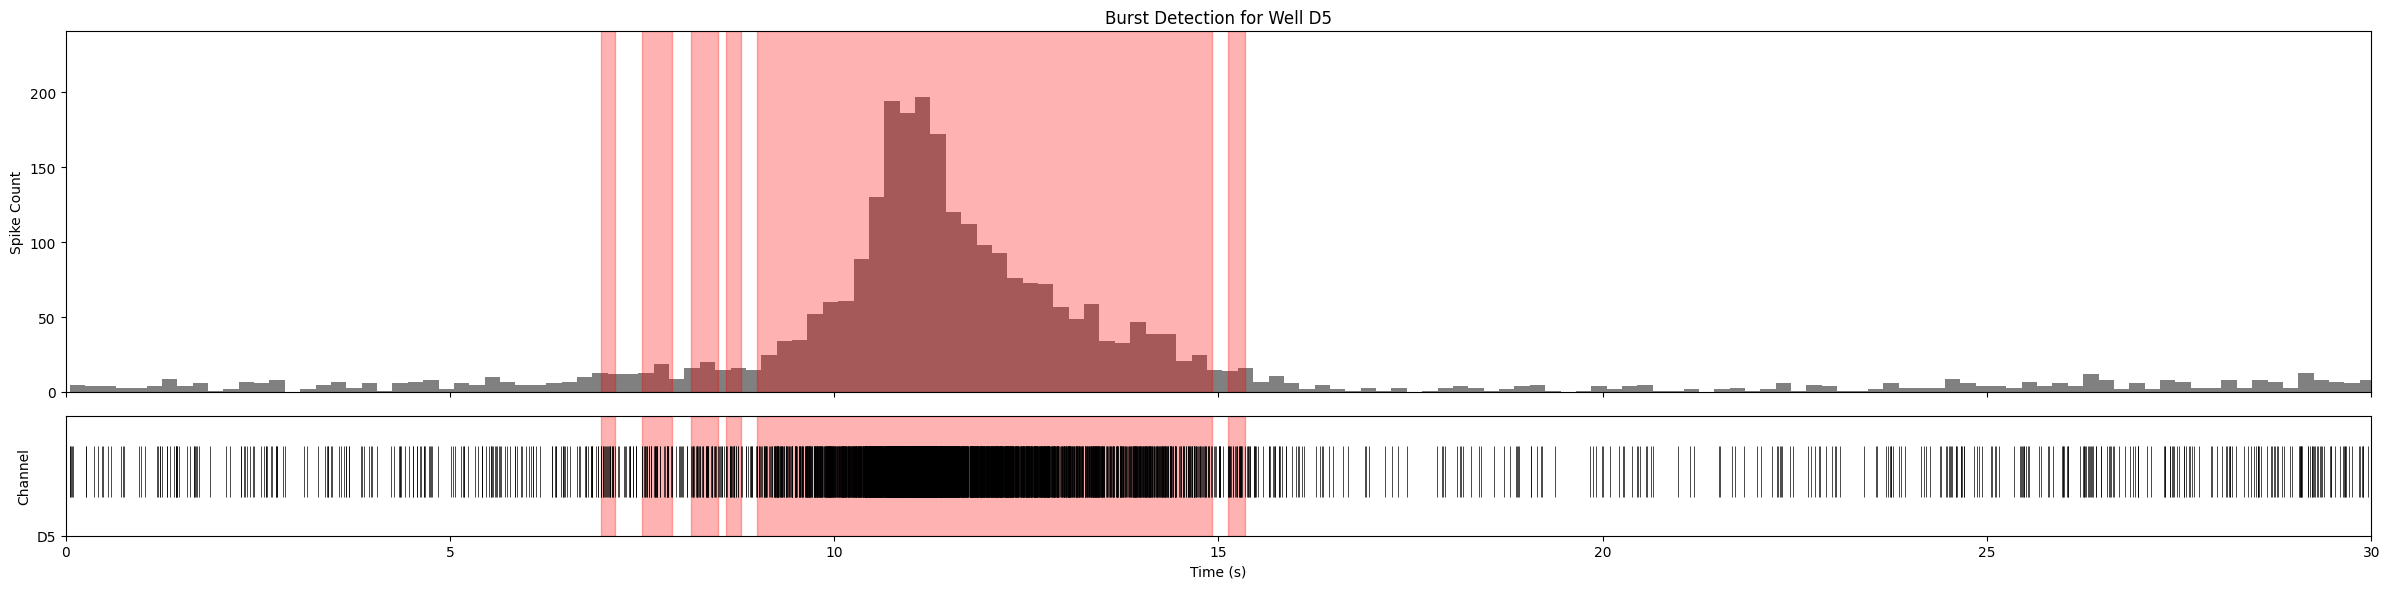

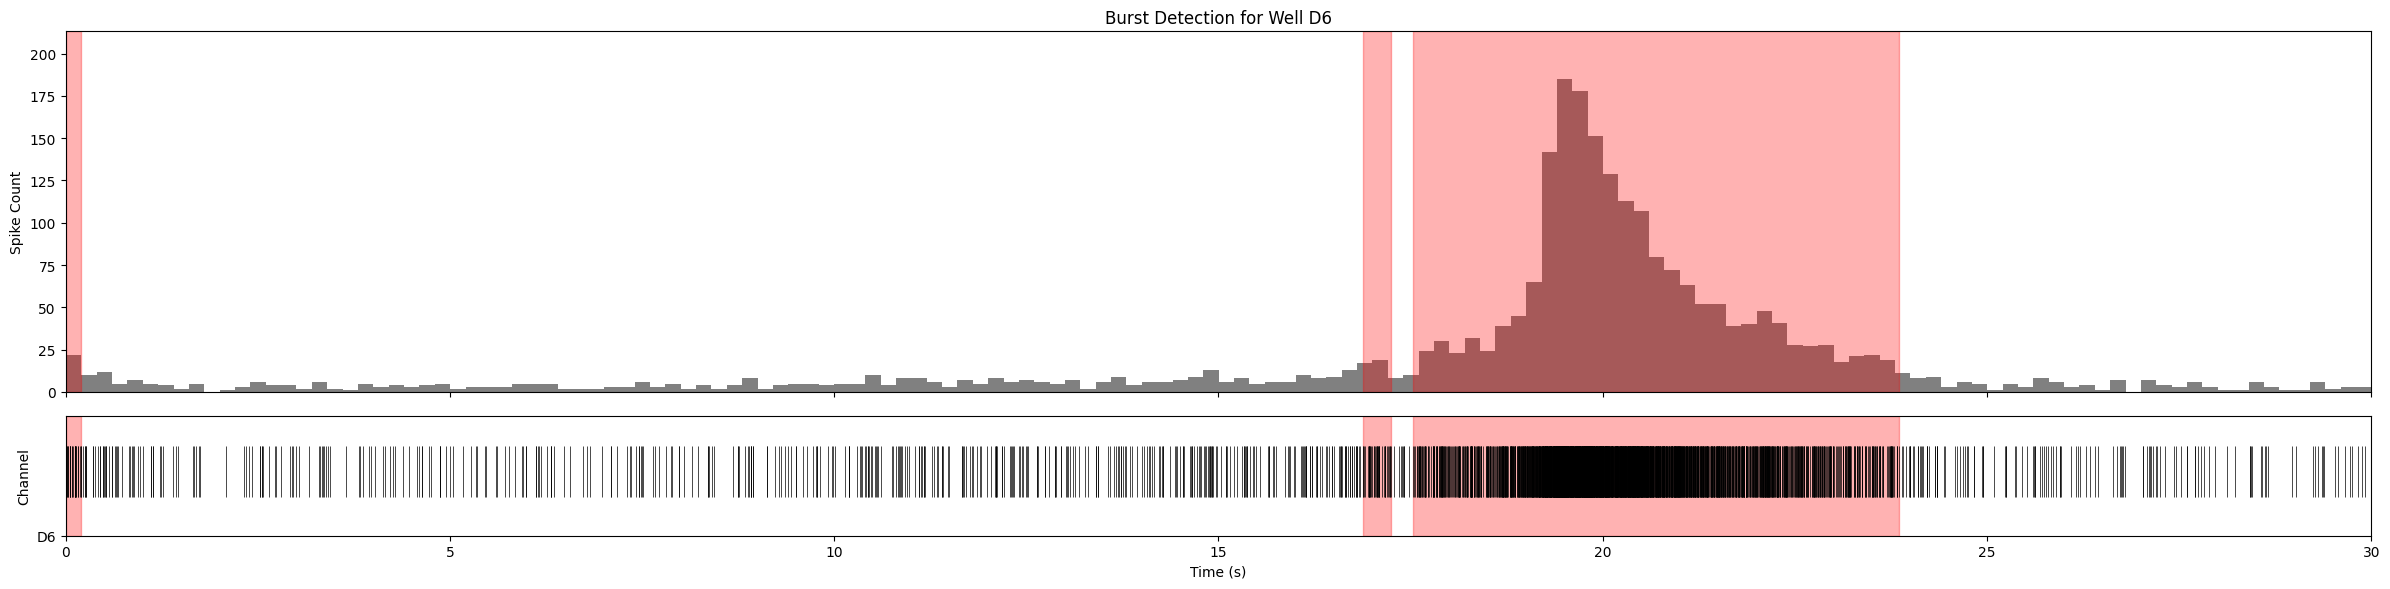

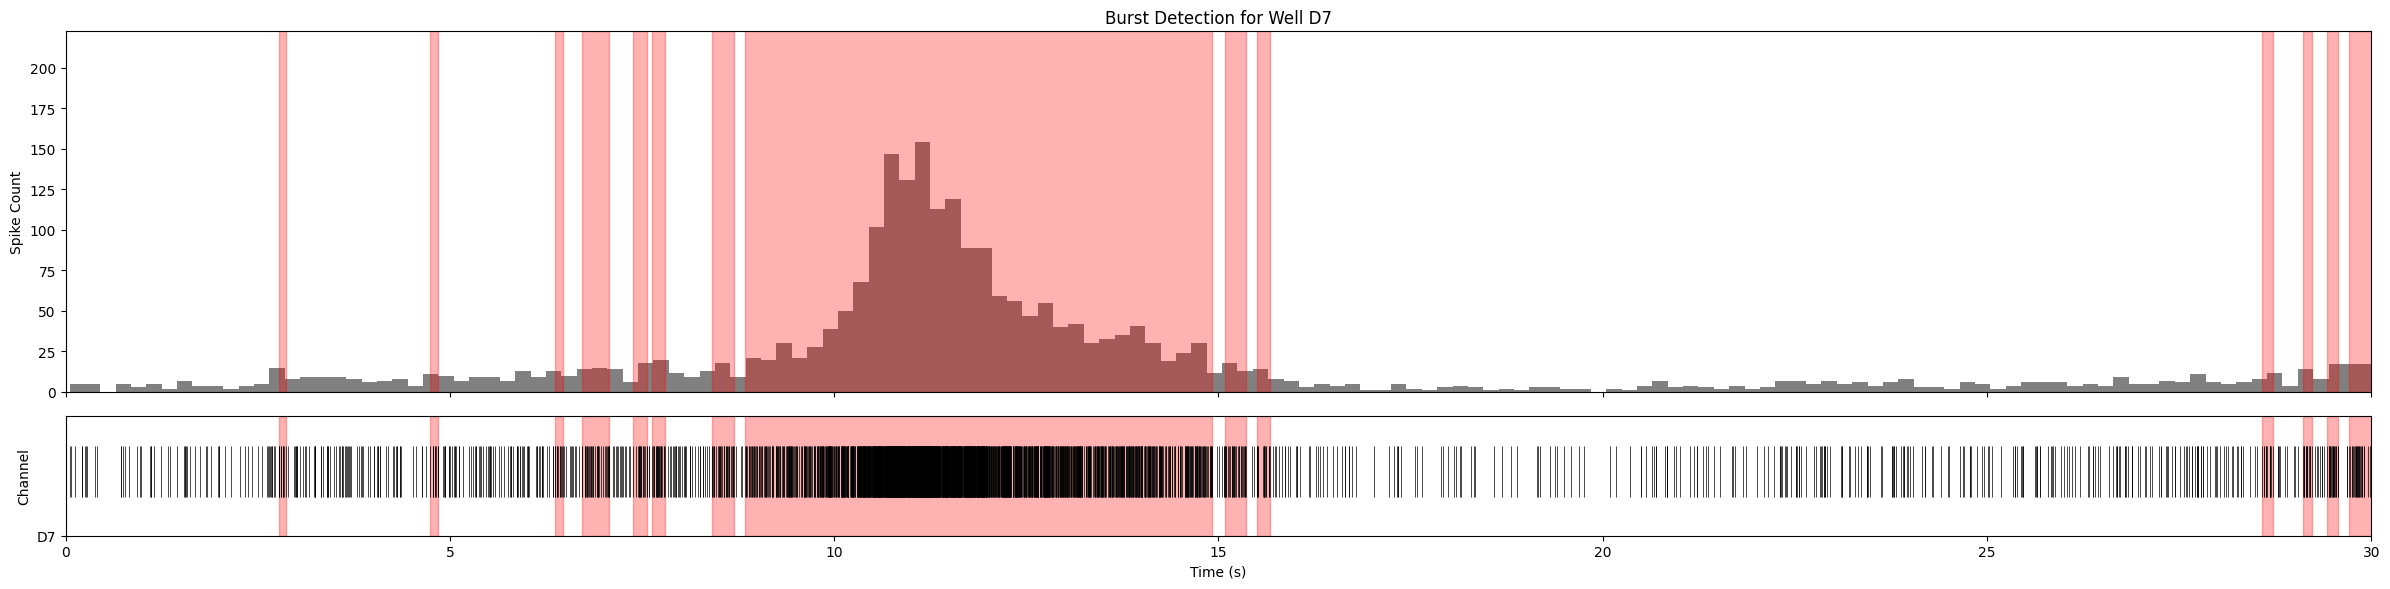

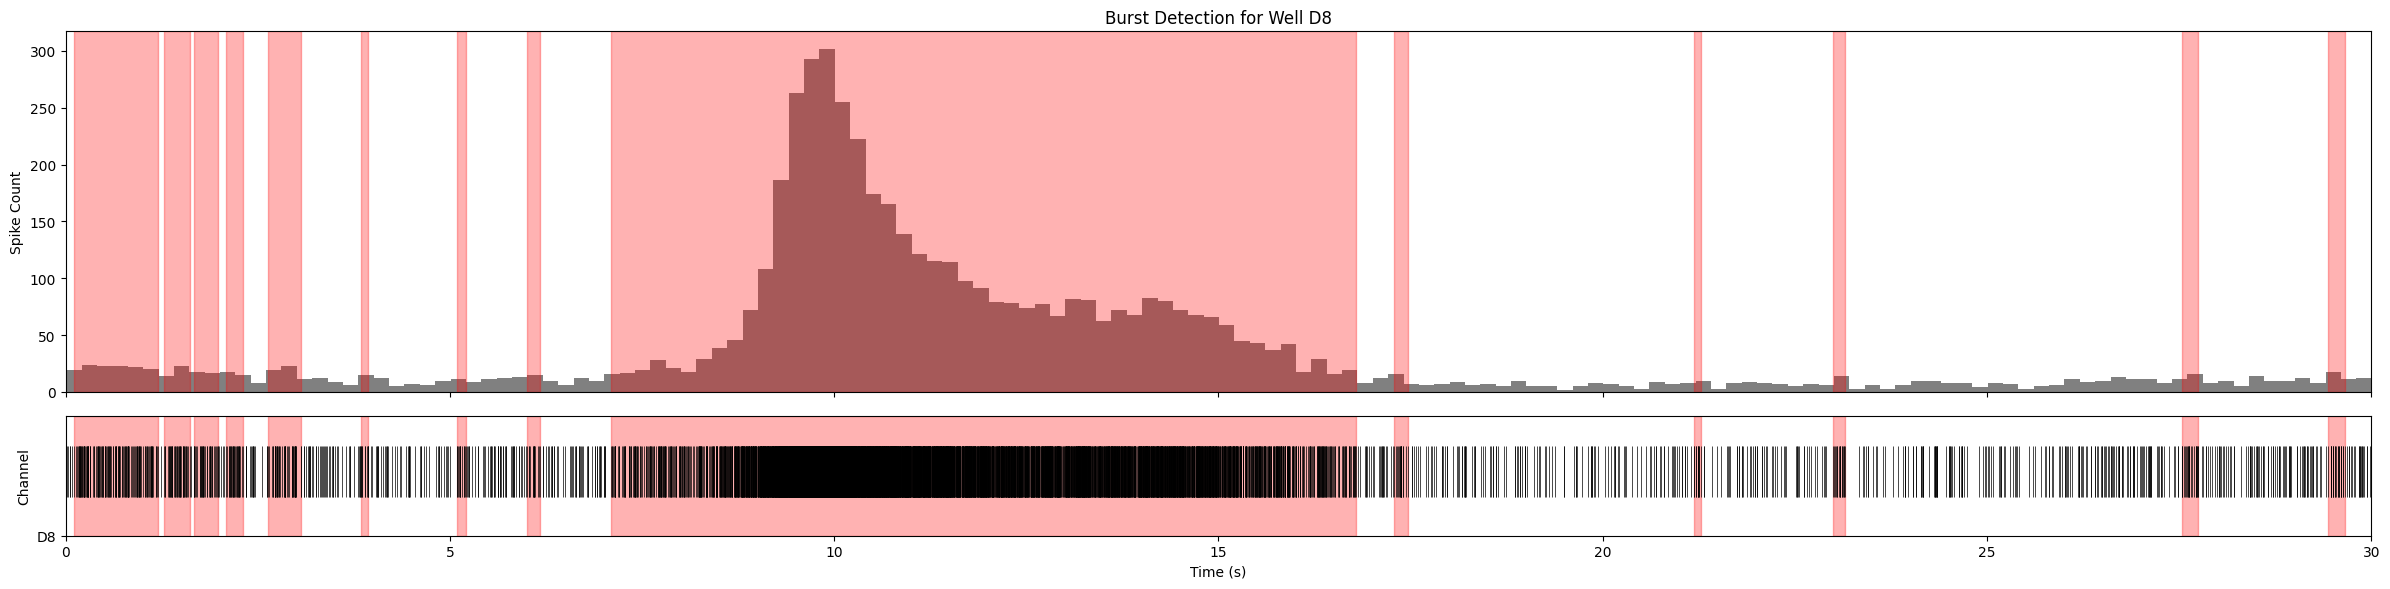

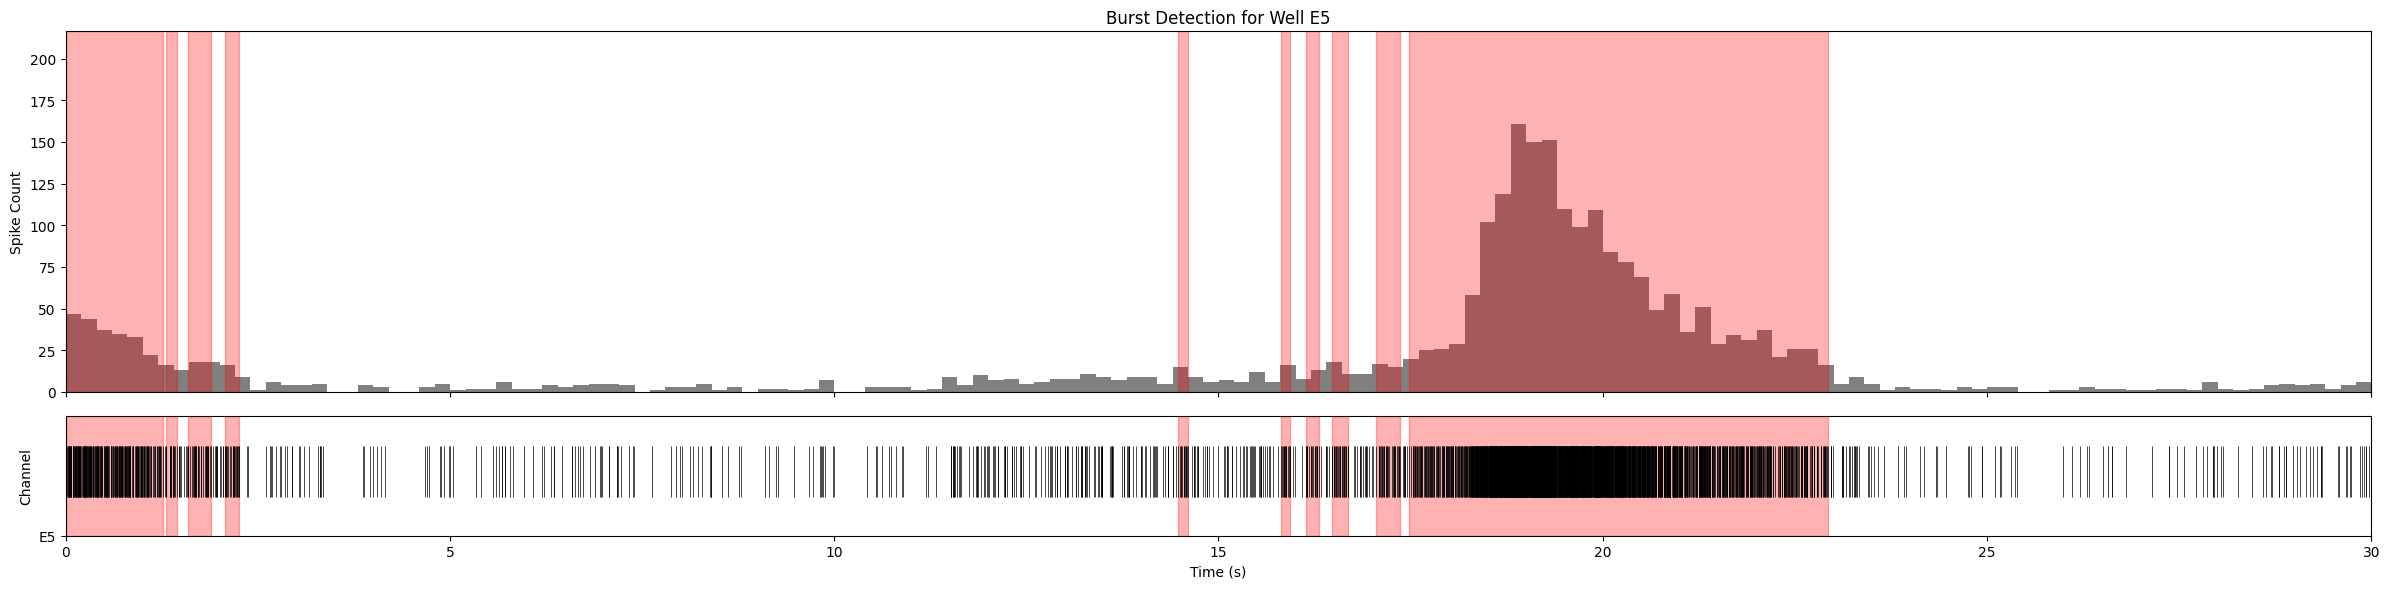

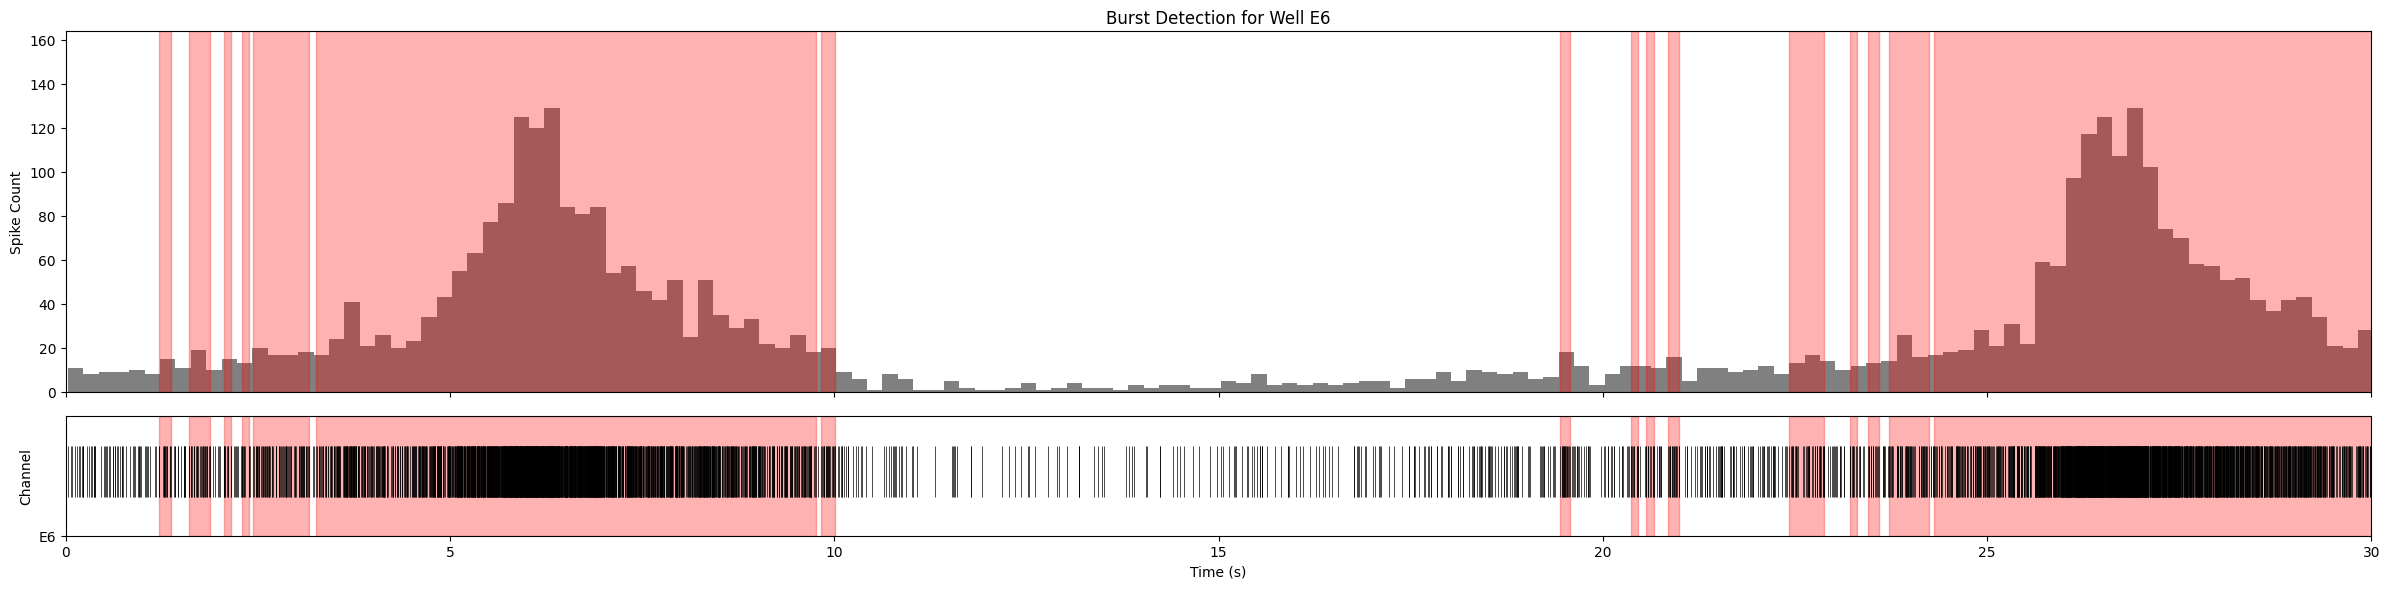

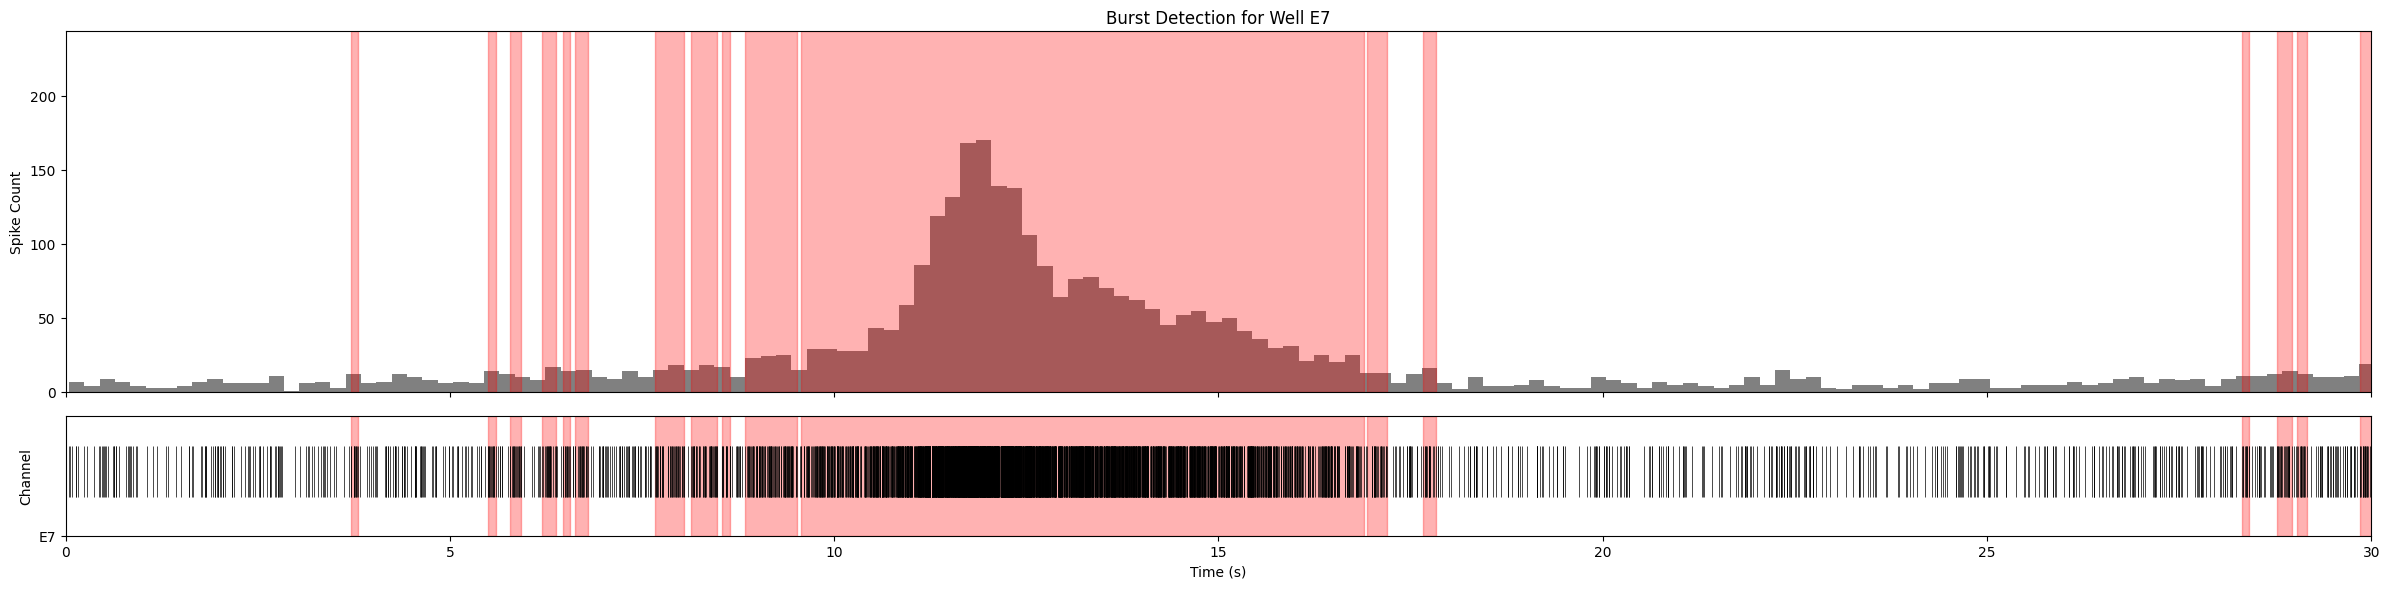

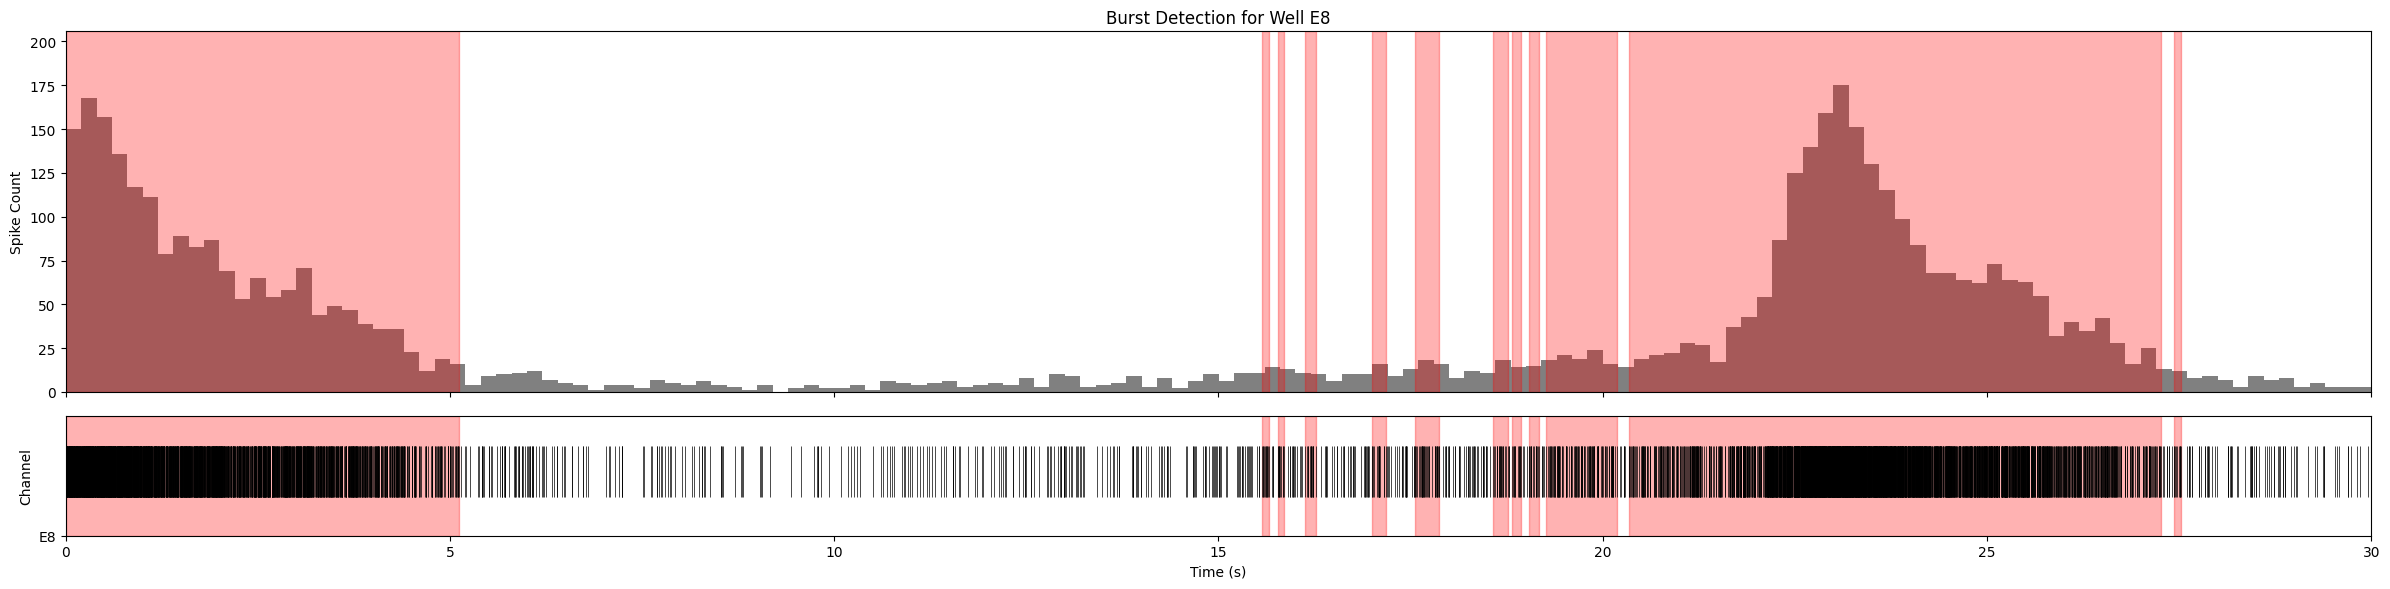

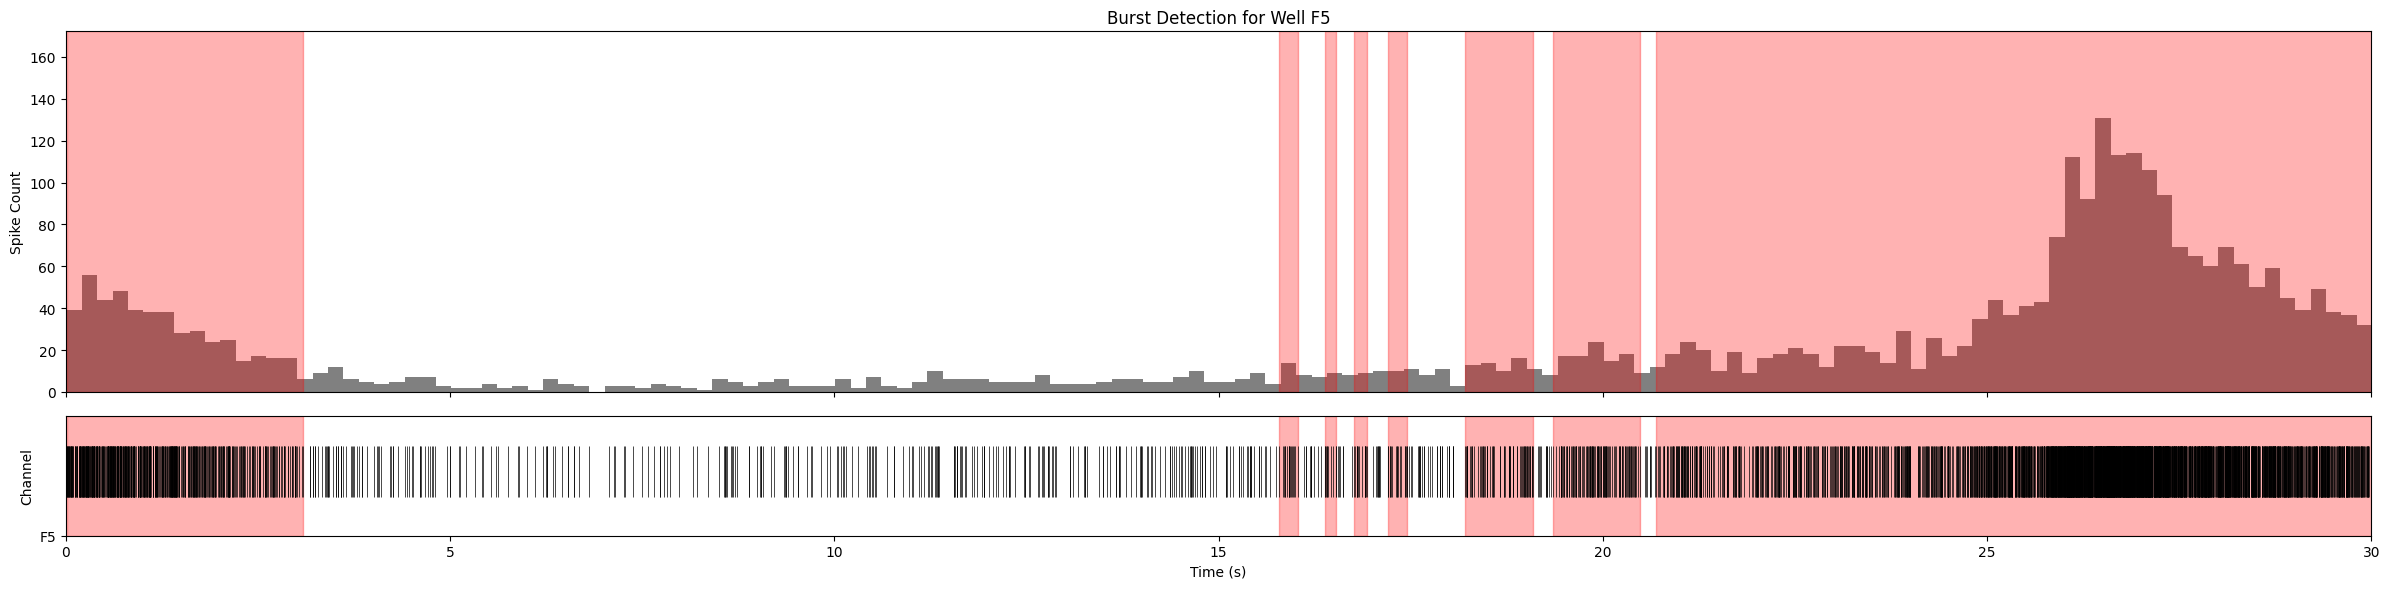

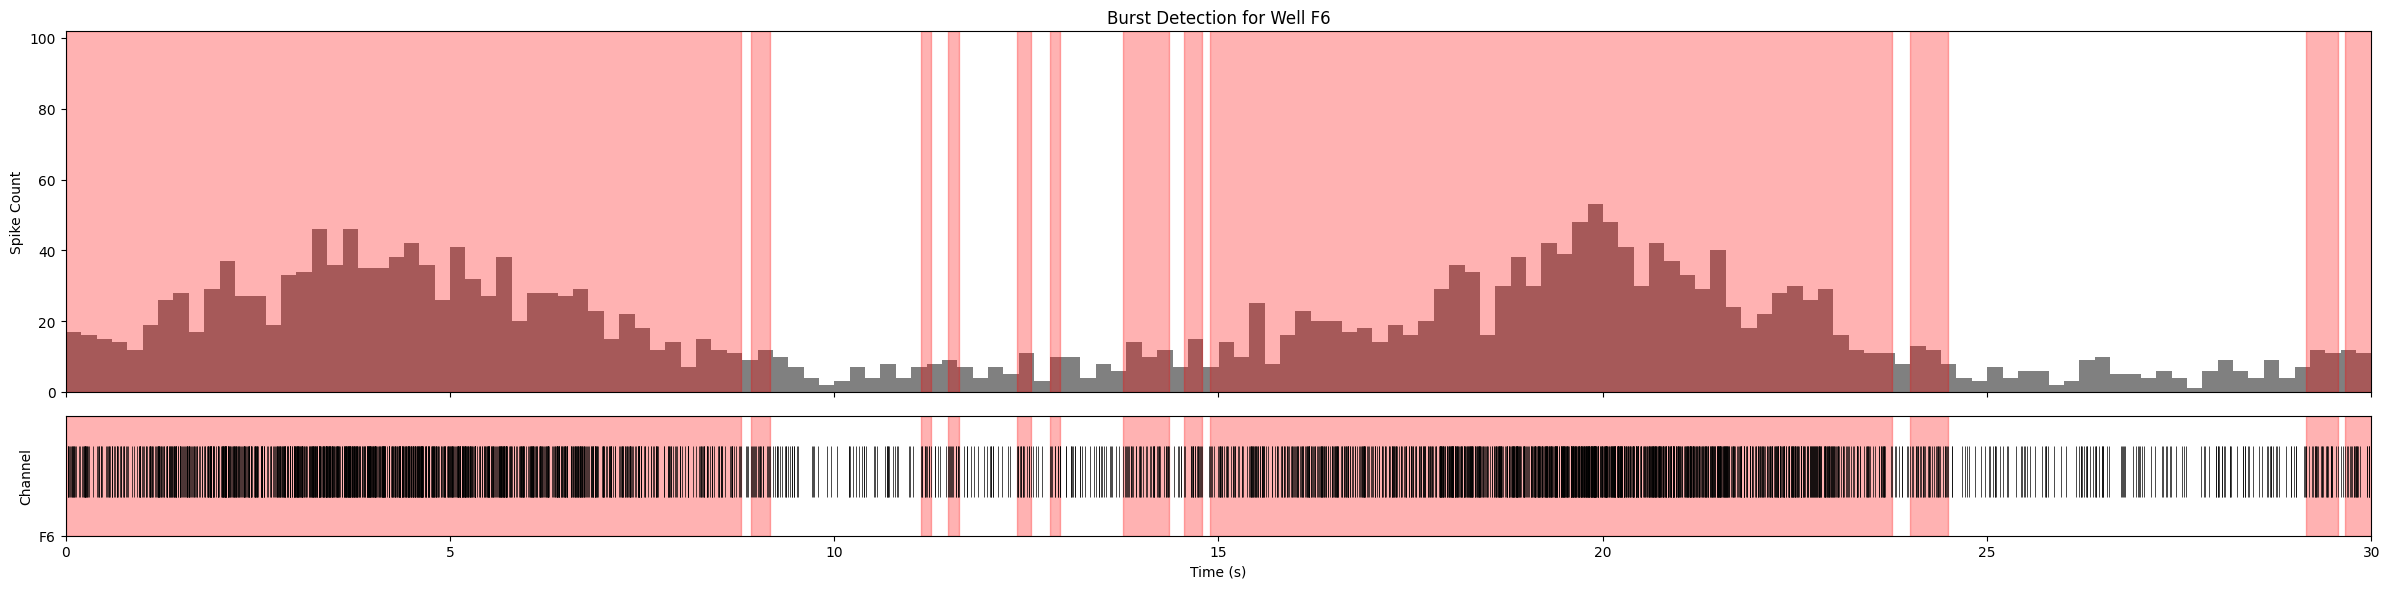

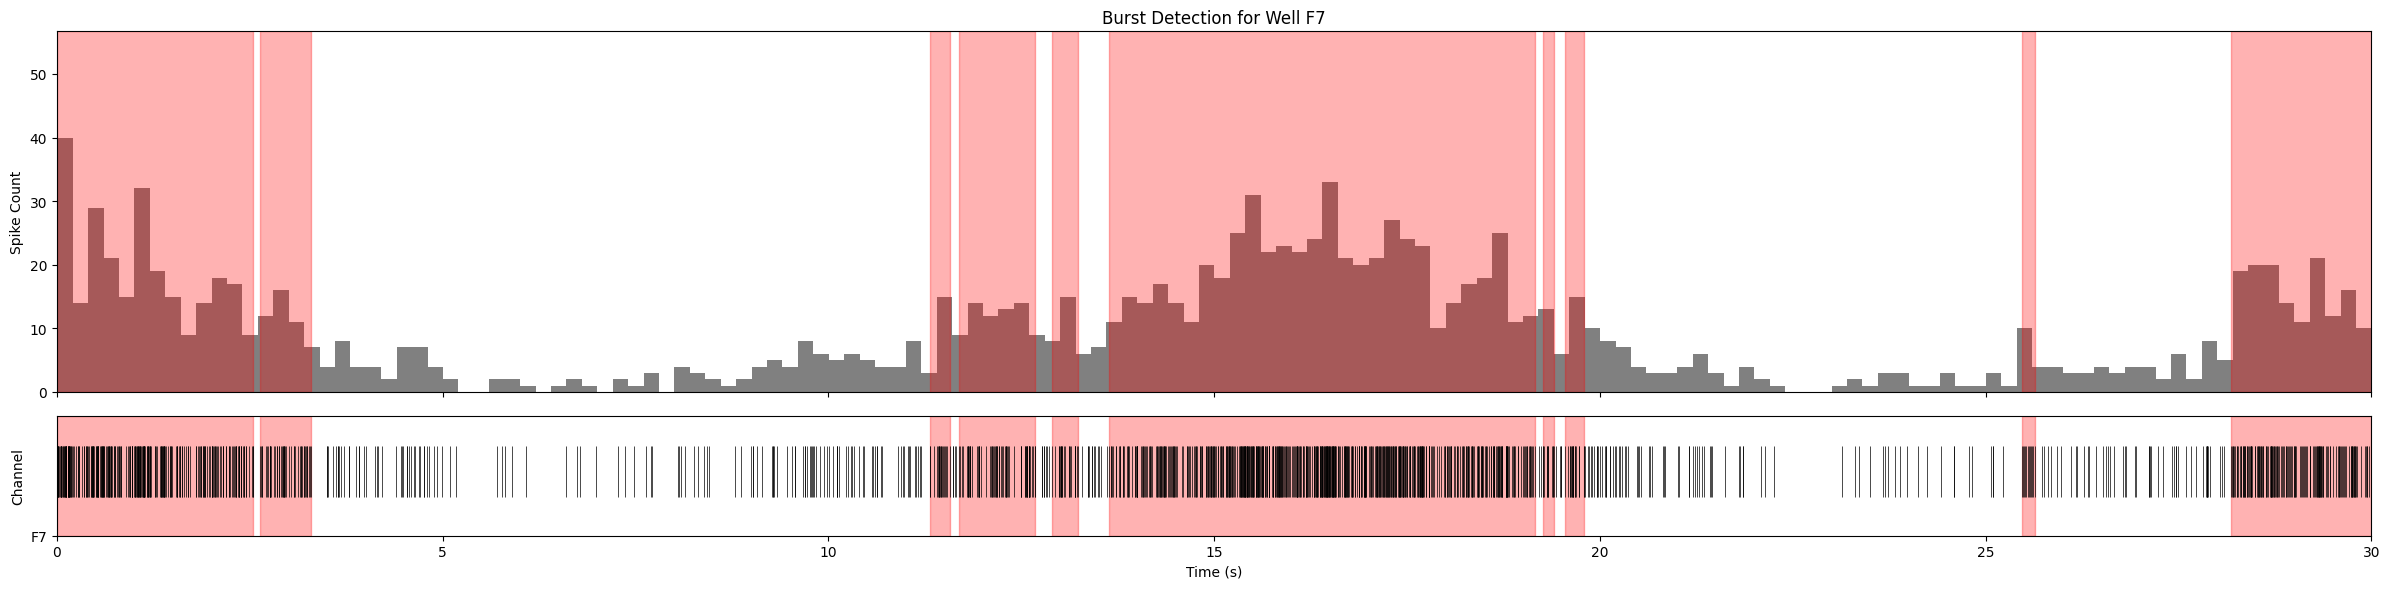

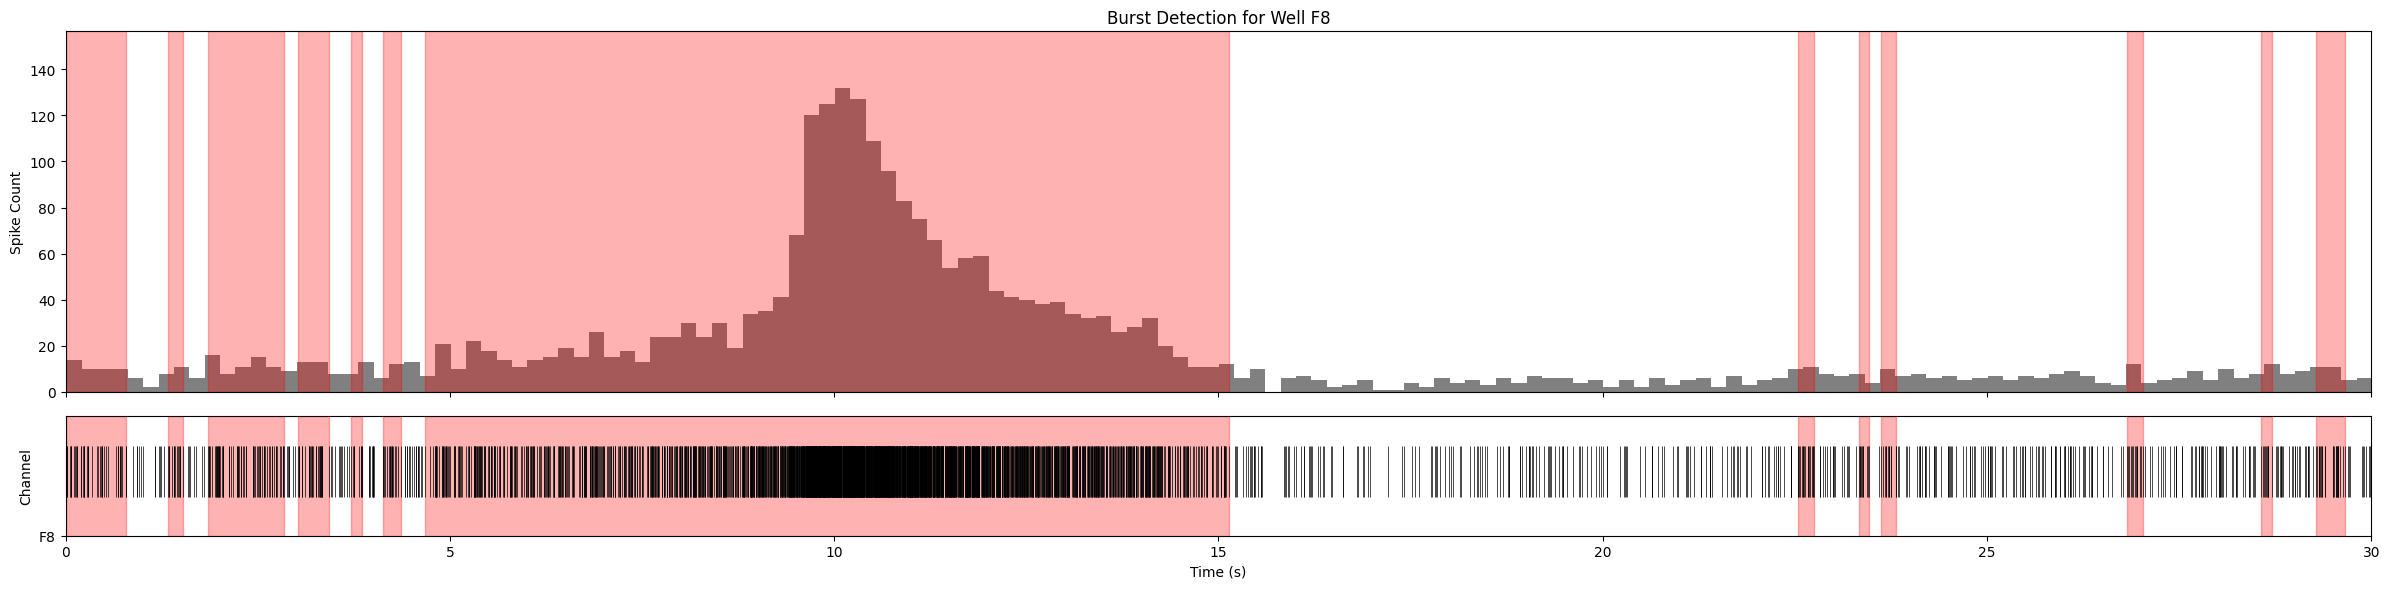

In [19]:
for well in wells:

    recording_per_ch_filtered = recording_per_ch[recording_per_ch["well"] == well].reset_index(drop=True)
    spike_time_stamps = get_spike_time_stamps(recording_per_ch_filtered)
    
    bursts = BurstDetector.detect(spiketime=spike_time_stamps, n=n, threshold=threshold_dict[well])
    plot_histogram_with_bursts(spike_time_stamps, bursts, duration=duration, well=well, title=f"Burst Detection for Well {well}")

# Treatment Burst Detection

### Treatment

In [20]:
recording_per_ch = pd.read_pickle('./data/spikes_treatment_processed.pkl')

/Users/mehdiazad/Library/CloudStorage/OneDrive-GeorgeBrownCollege/Epiloid/PROJECTS/MEA_Project/.venv/lib/python3.12/site-packages/ISIn/burst_detector.py:60: RuntimeWarning: invalid value encountered in divide
  y = hist / np.sum(hist)
/Users/mehdiazad/Library/CloudStorage/OneDrive-GeorgeBrownCollege/Epiloid/PROJECTS/MEA_Project/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/mehdiazad/Library/CloudStorage/OneDrive-GeorgeBrownCollege/Epiloid/PROJECTS/MEA_Project/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


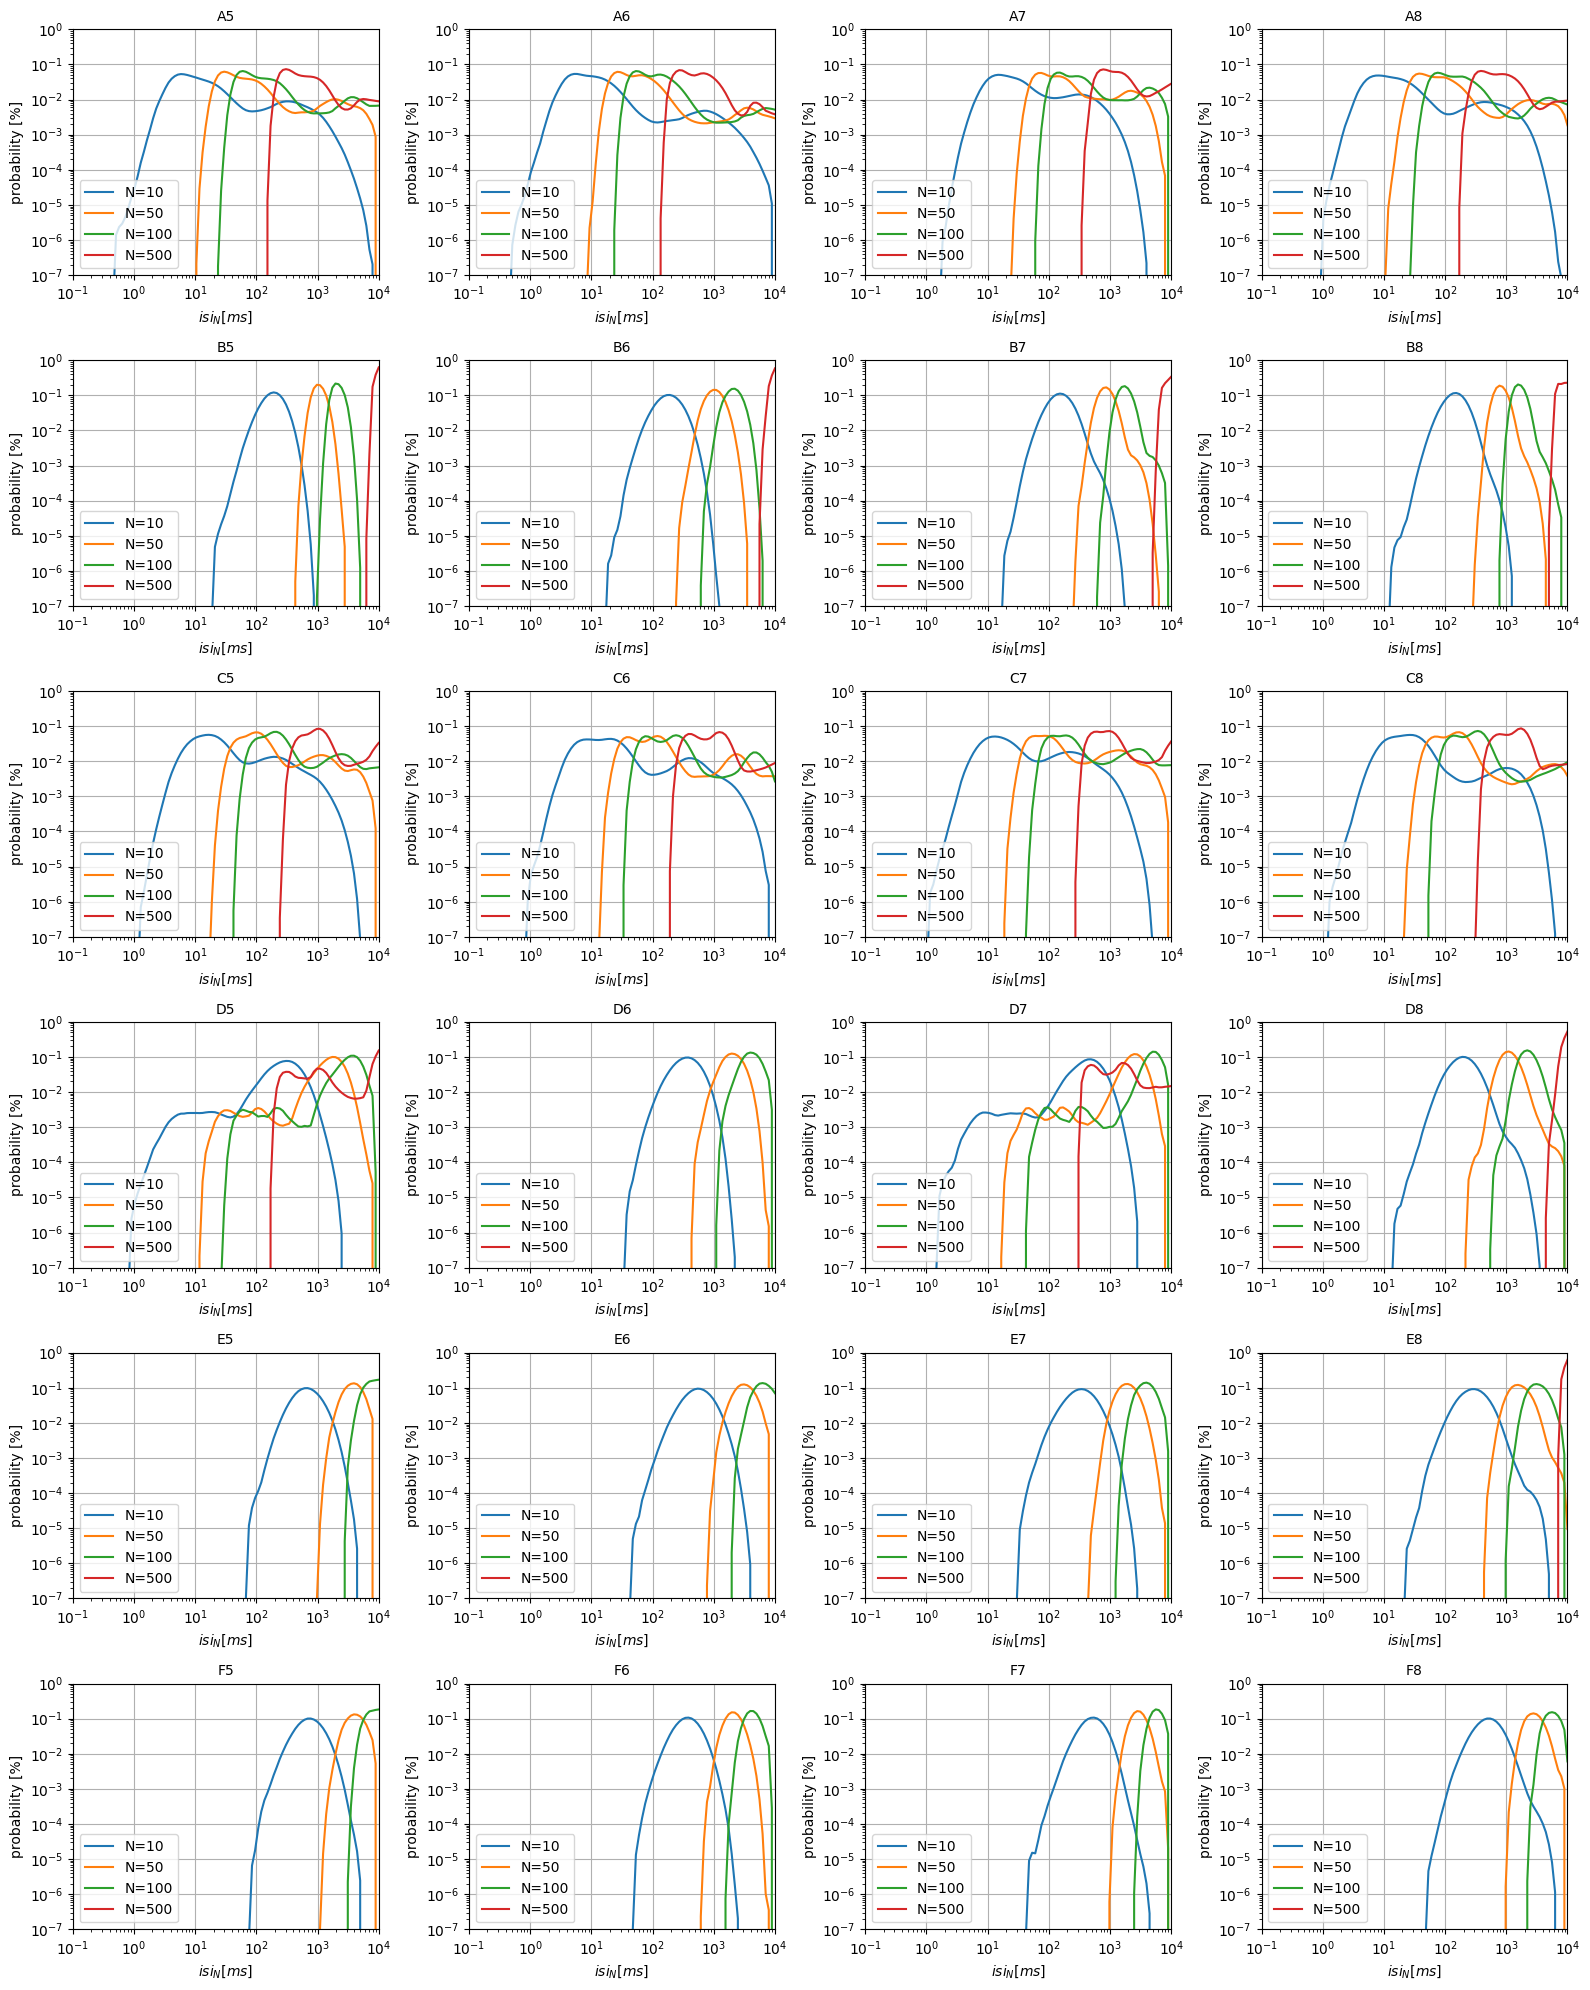

In [21]:
# Create figure with 6x4 subplots (24 wells total)
fig, axes = plt.subplots(6, 4, figsize=(16, 20))
axes = axes.flatten()

for idx, well in enumerate(wells):
    recording_per_ch_filtered = recording_per_ch[recording_per_ch["well"] == well].reset_index(drop=True)

    spike_time_stamps = get_spike_time_stamps(recording_per_ch_filtered)
    
    # Plot on the specific subplot
    ax = BurstDetector.plot(
        spiketime=spike_time_stamps  ,
        n_list=[10, 50, 100, 500],
        ax=axes[idx]  # Specify which axis to plot on
    )
    axes[idx].set_title(f"{well}", fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
n = 10

threshold_dict = {
    "A5": 100, "A6": 100, "A7": 100, "A8": 100,
    "B5": 160, "B6": 160, "B7": 160, "B8": 160,
    "C5": 100, "C6": 100, "C7": 100, "C8": 100,
    "D5": 220, "D6": 220, "D7": 220, "D8": 220,
    "E5": 400, "E6": 400, "E7": 300, "E8": 300,
    "F5": 500, "F6": 300, "F7": 400, "F8": 400,
}

duration = 60 #sec

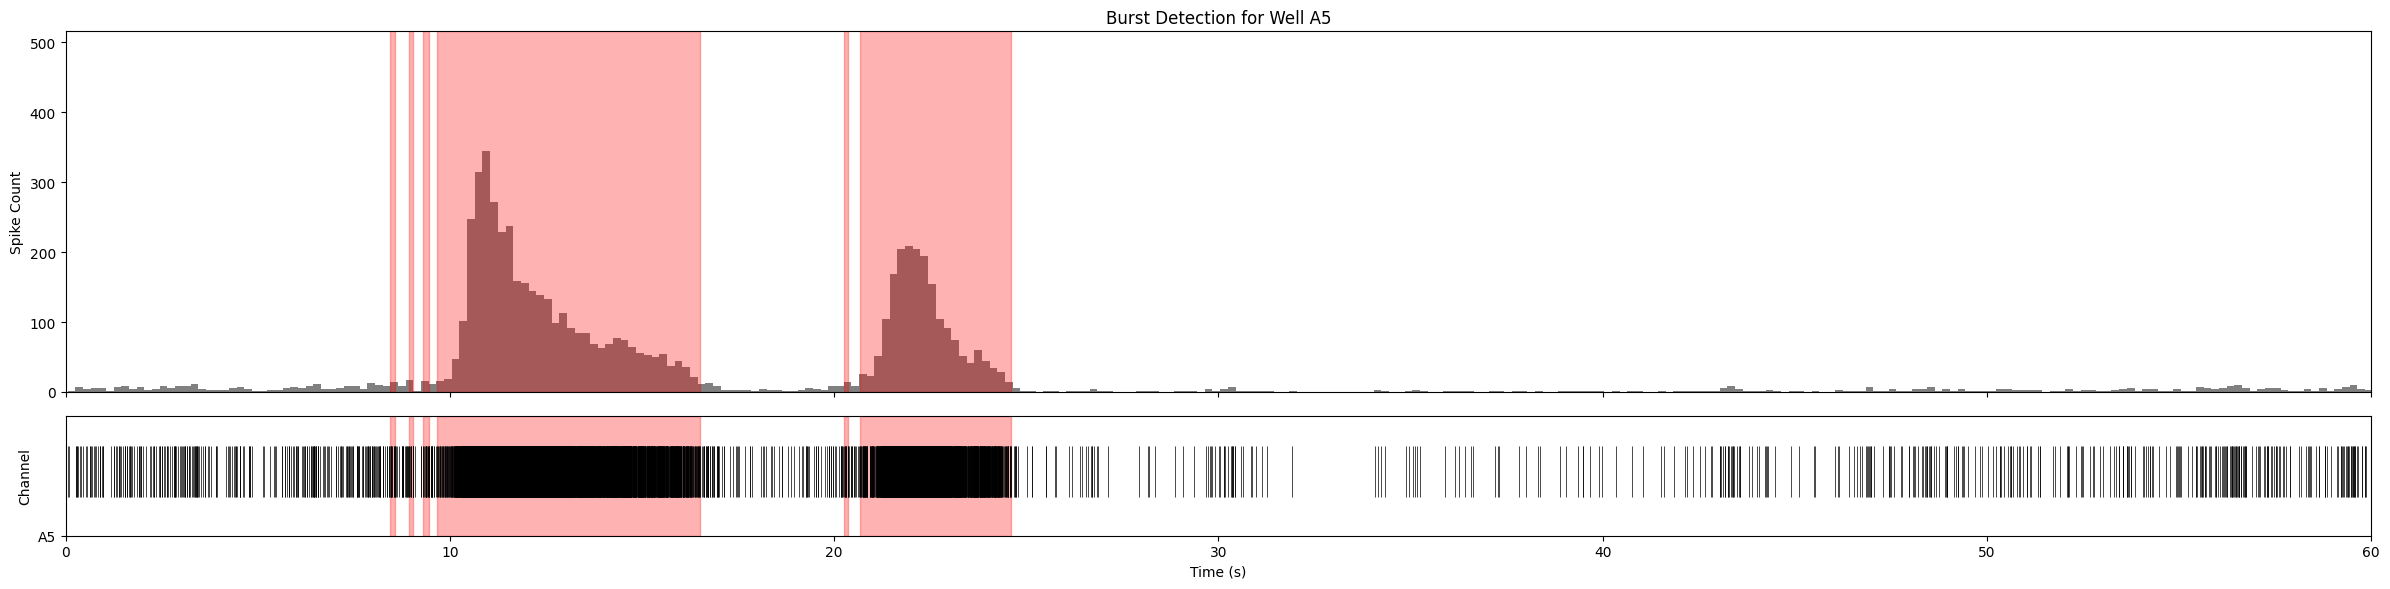

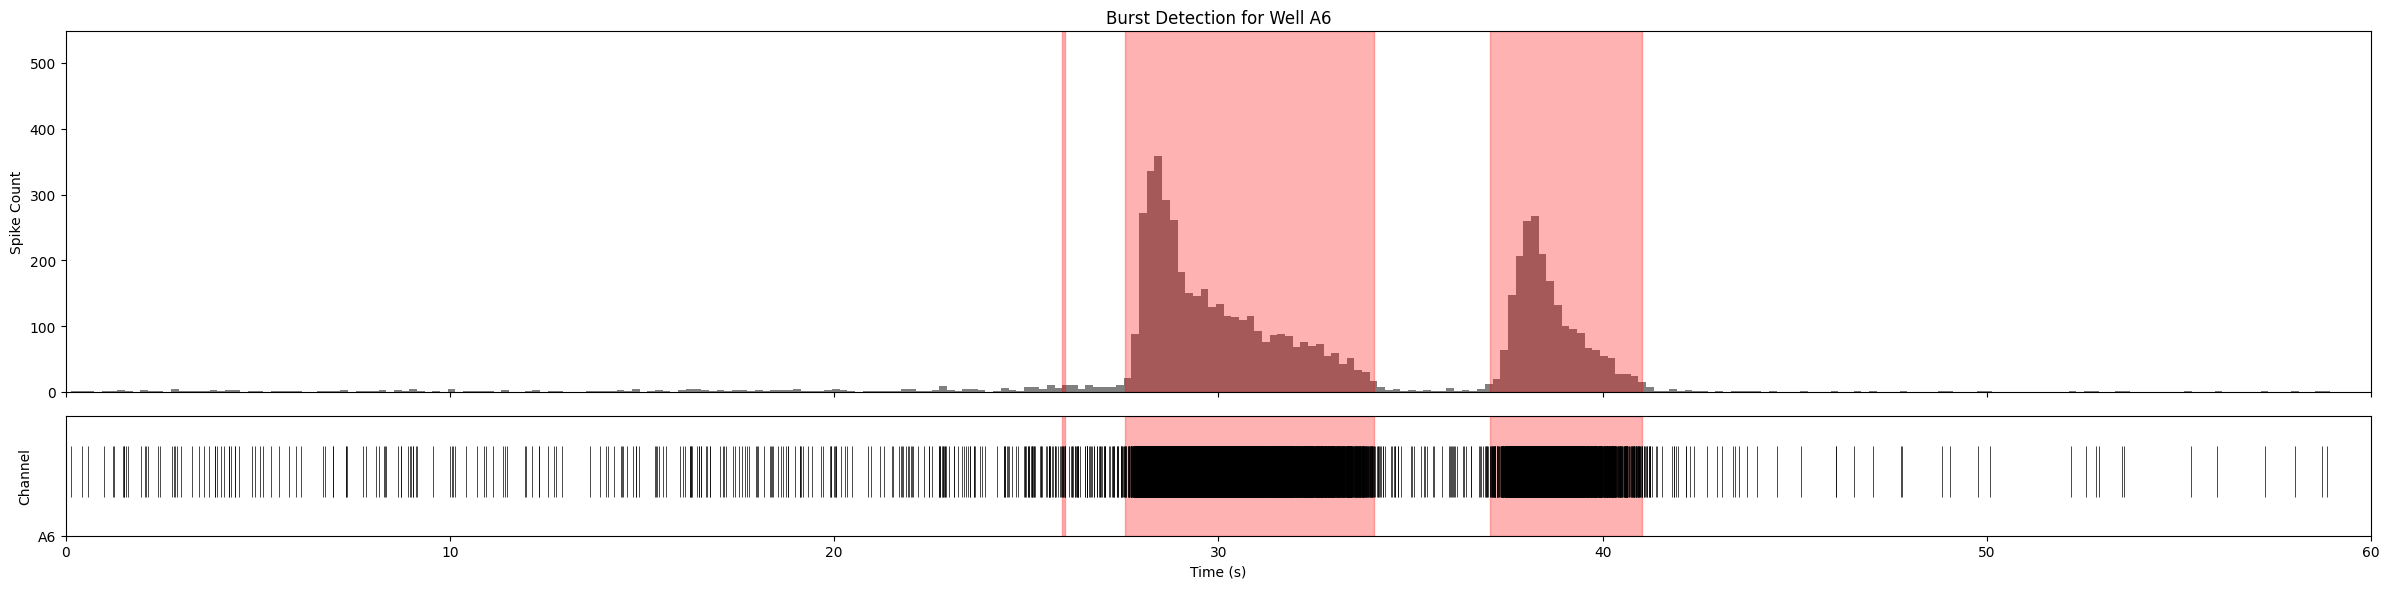

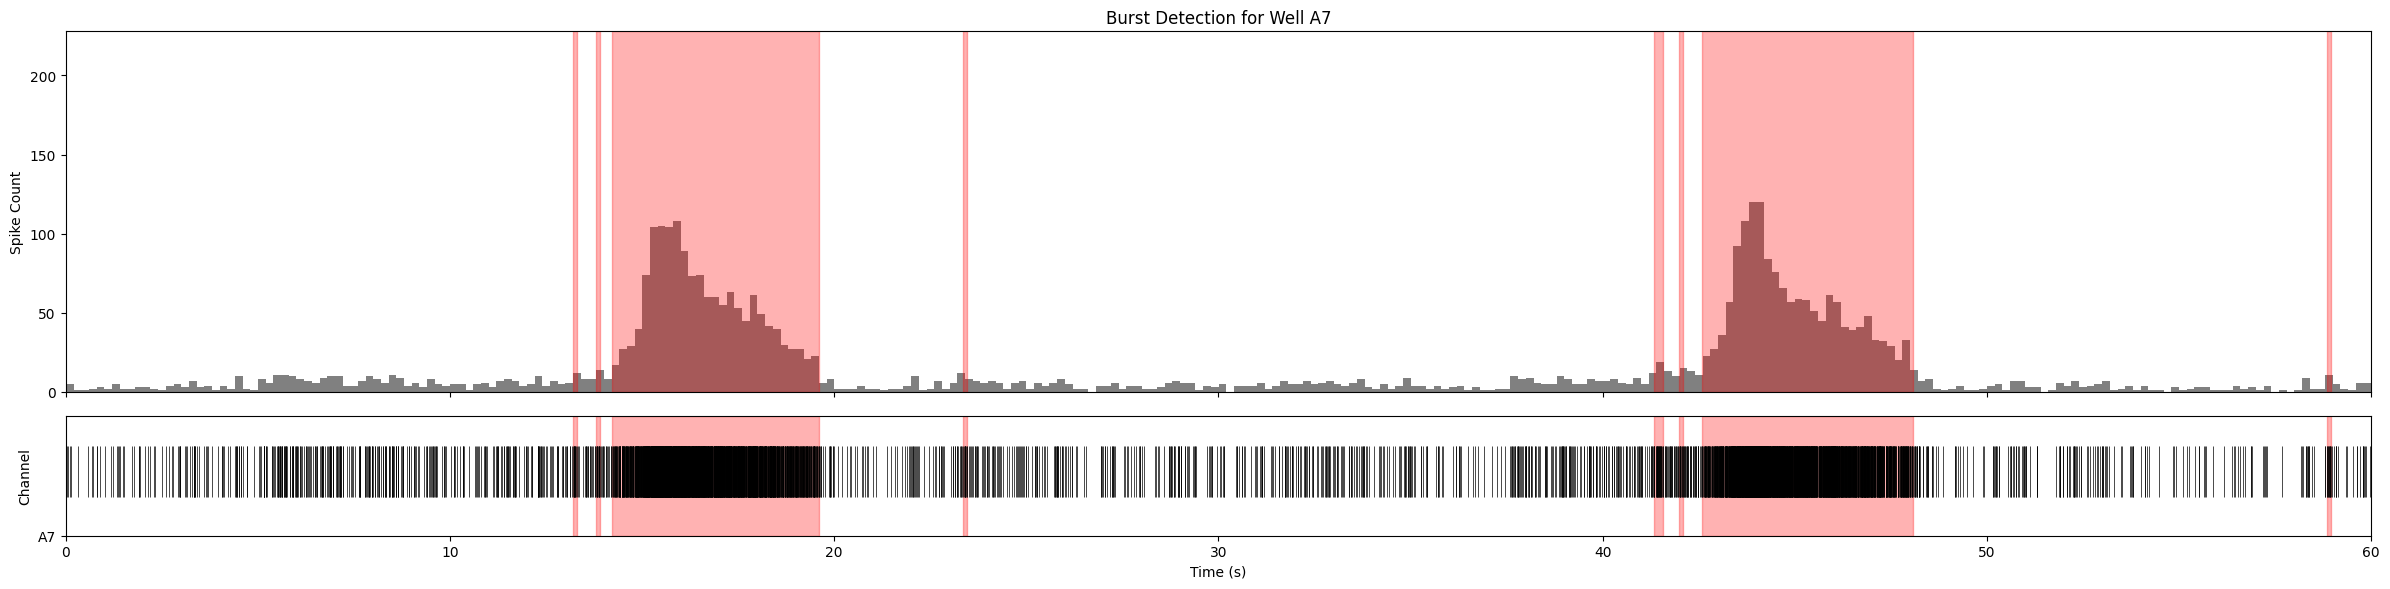

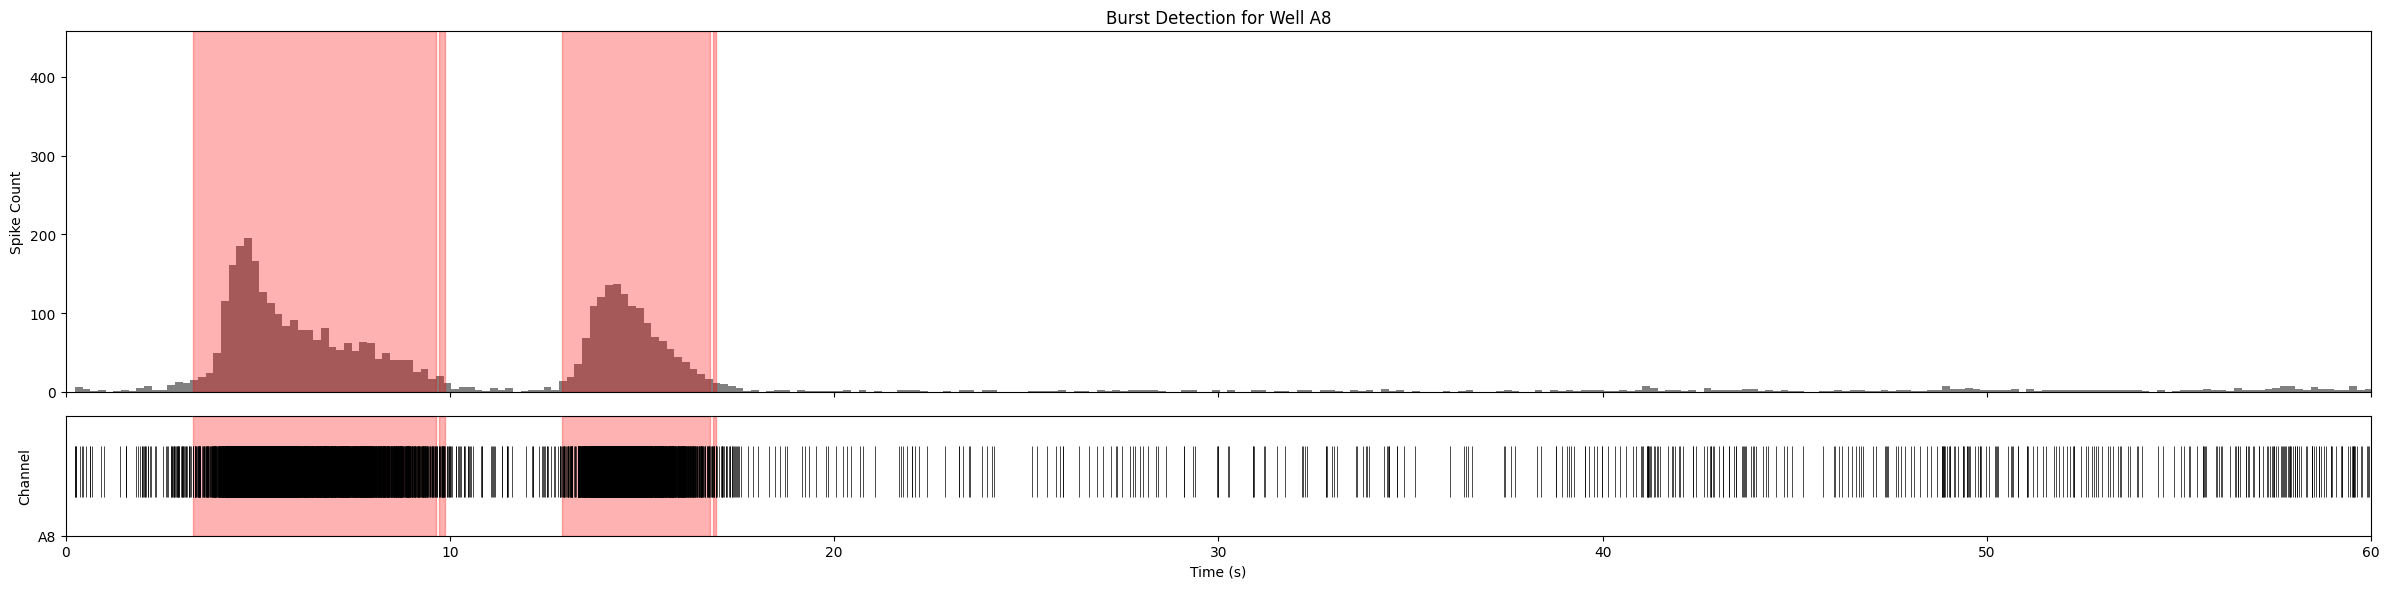

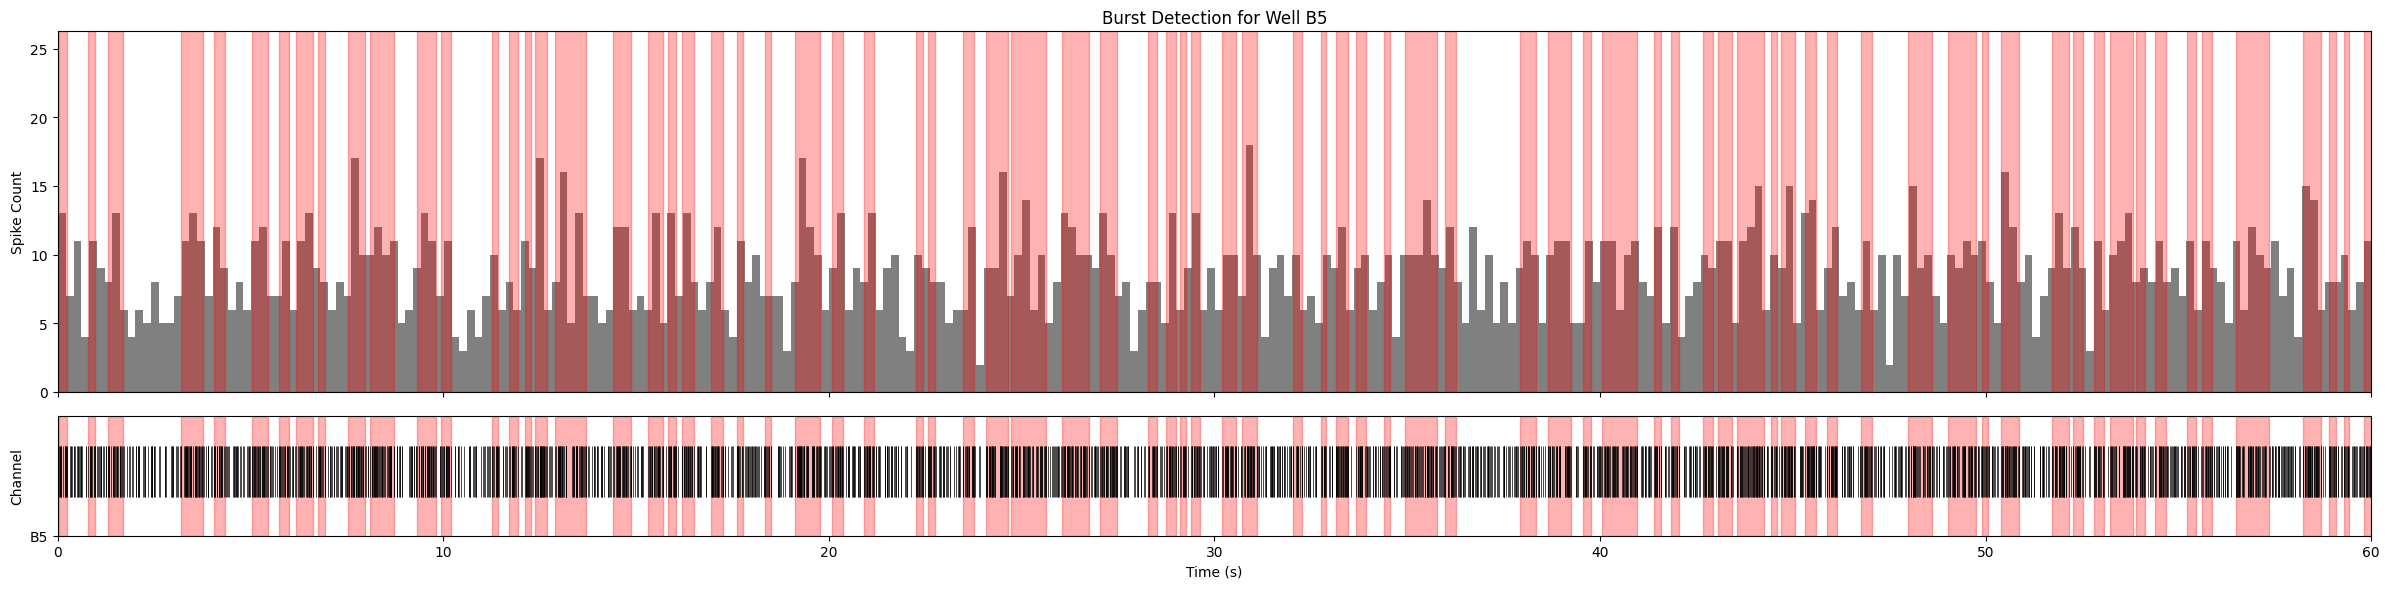

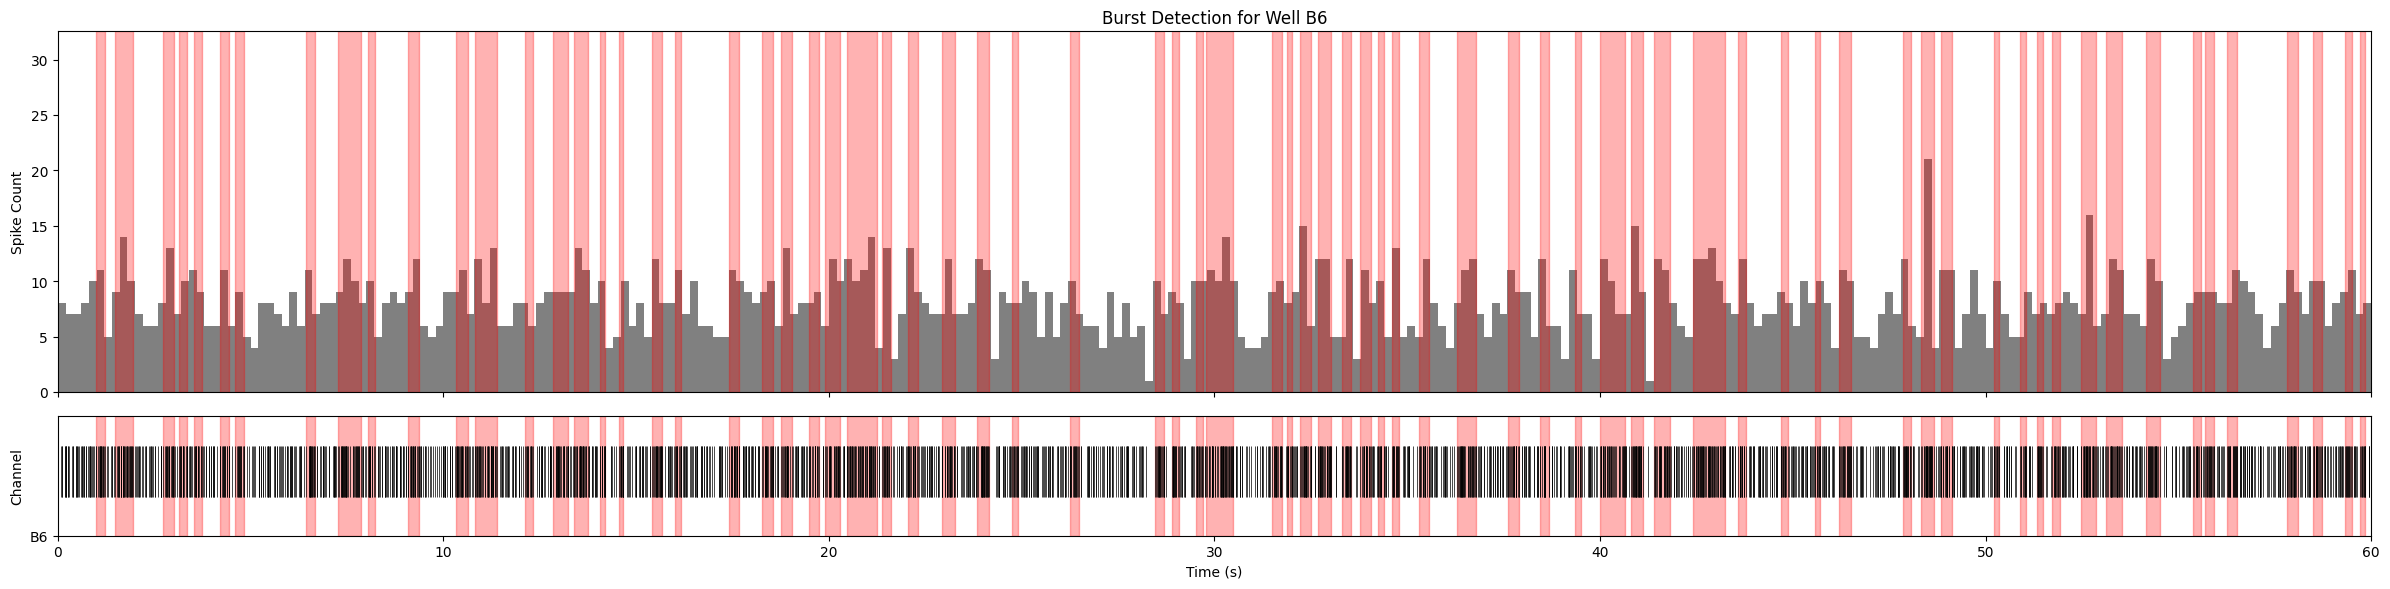

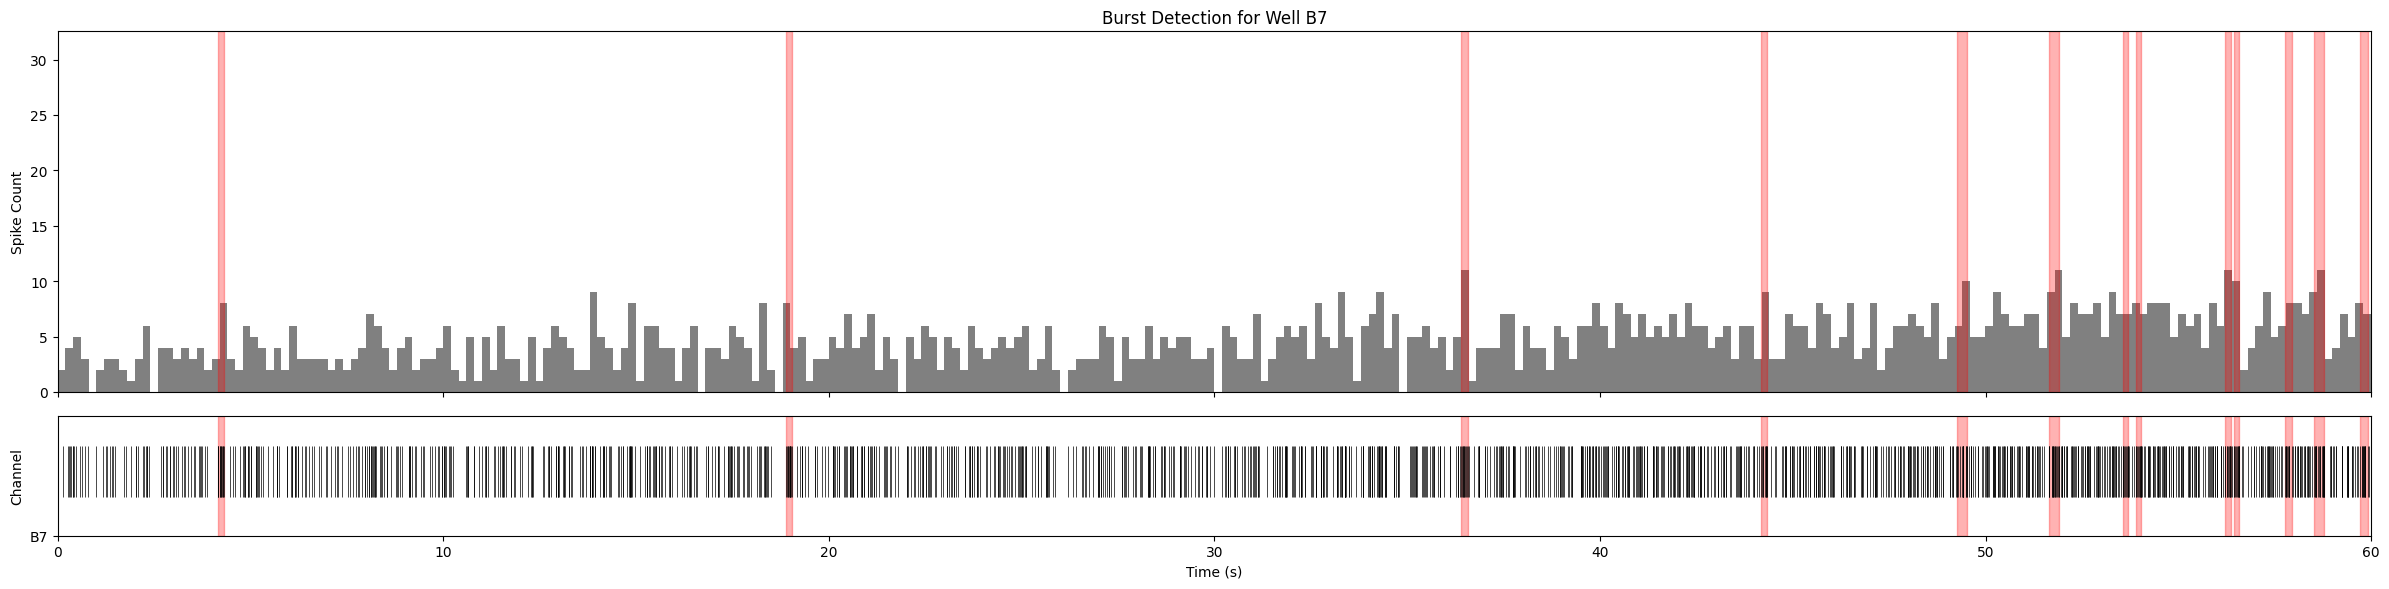

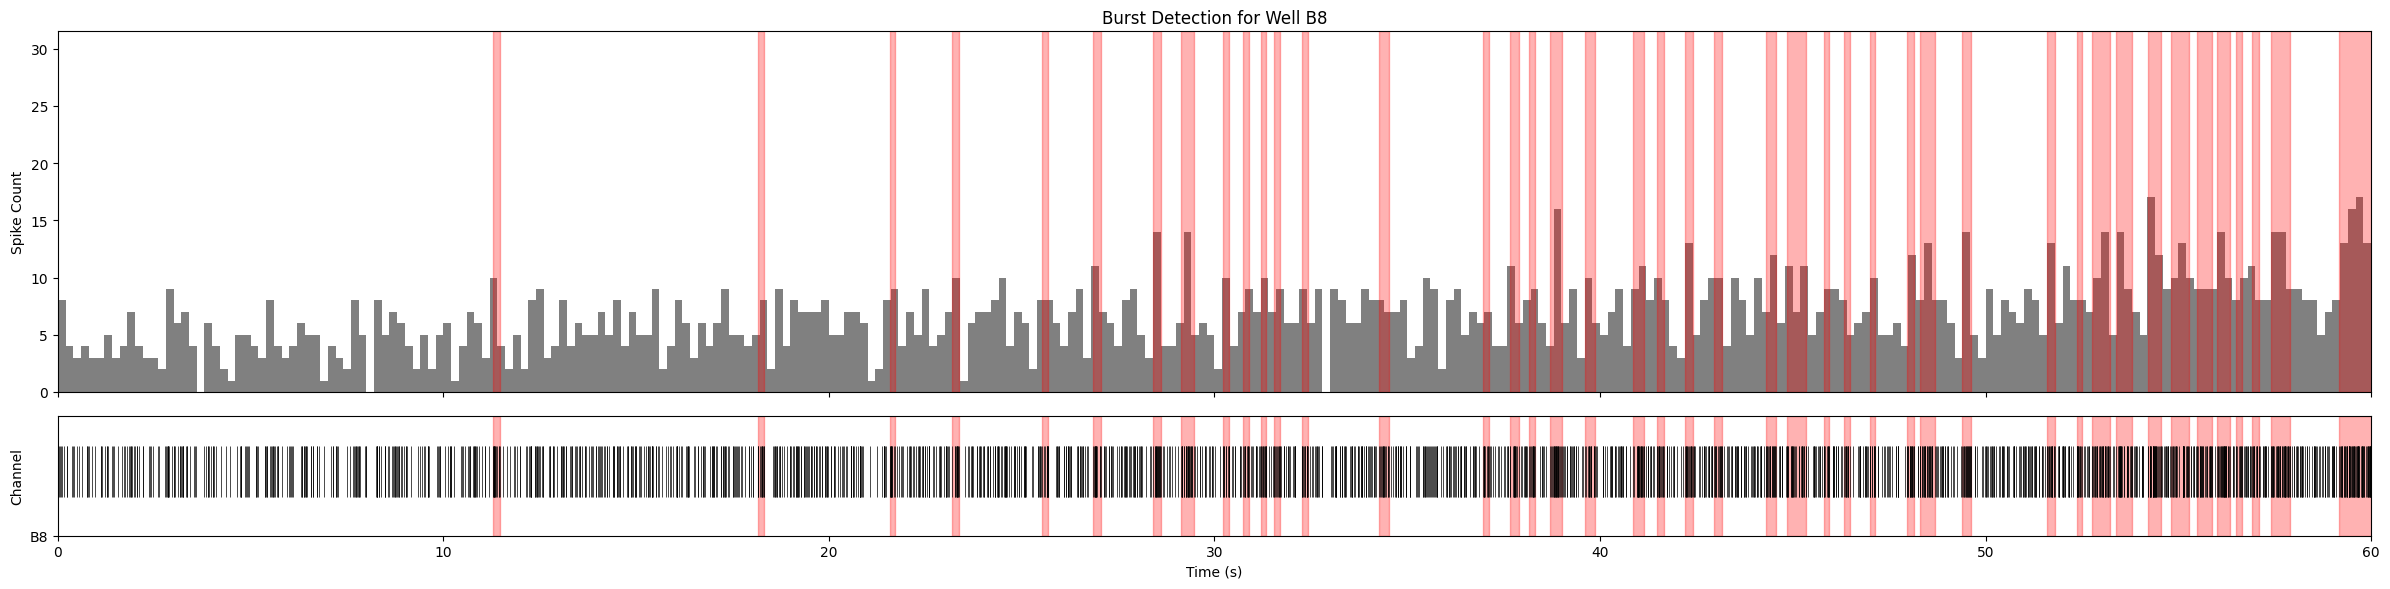

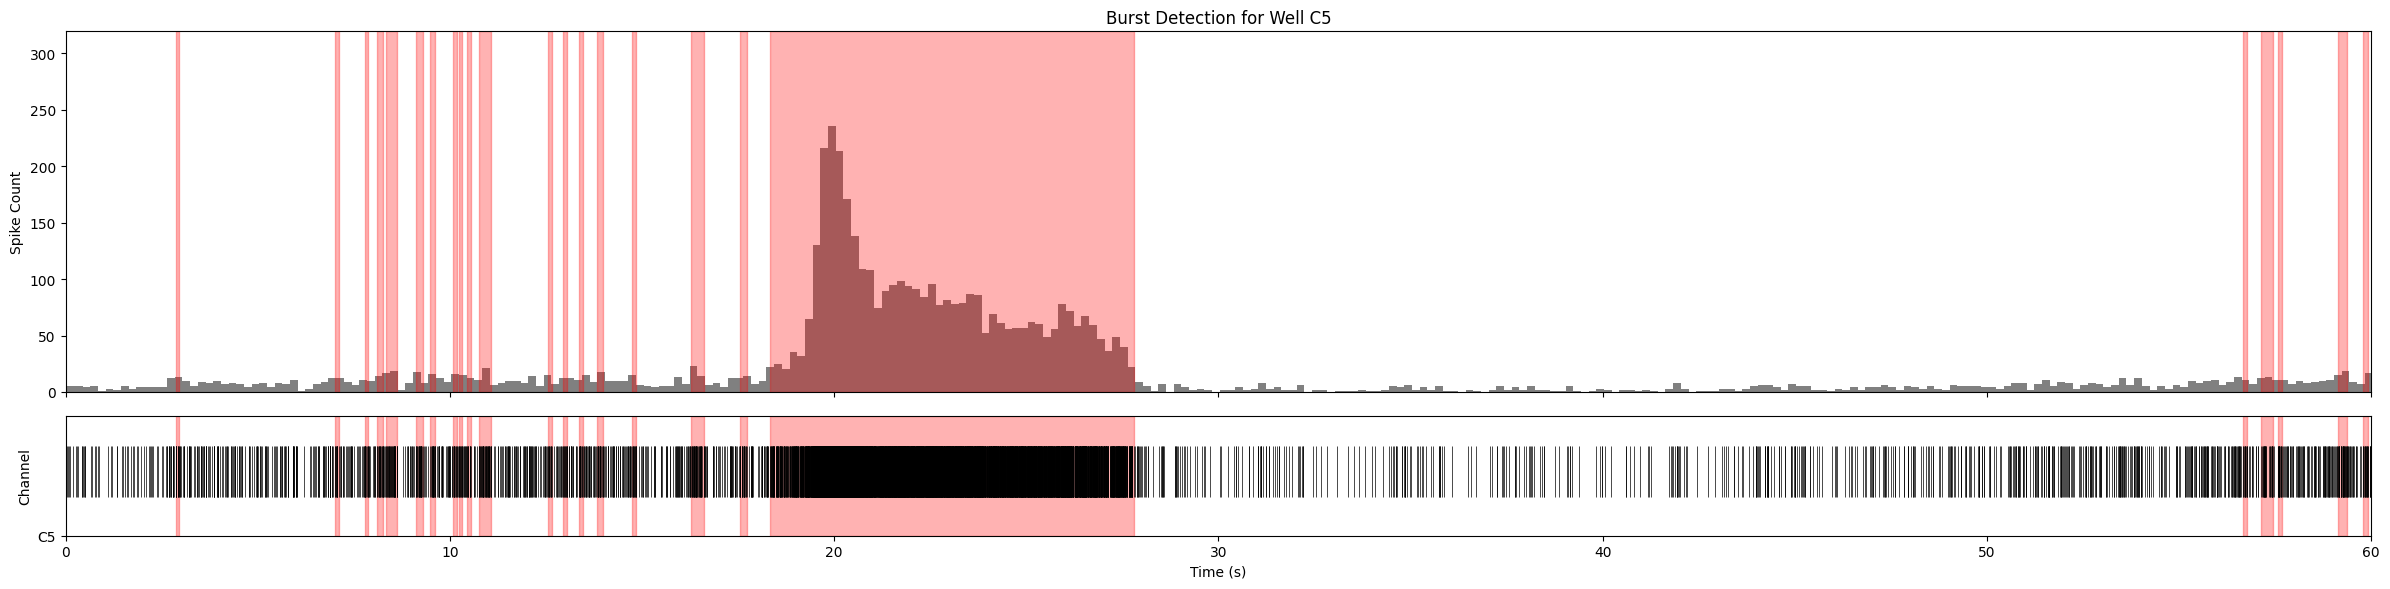

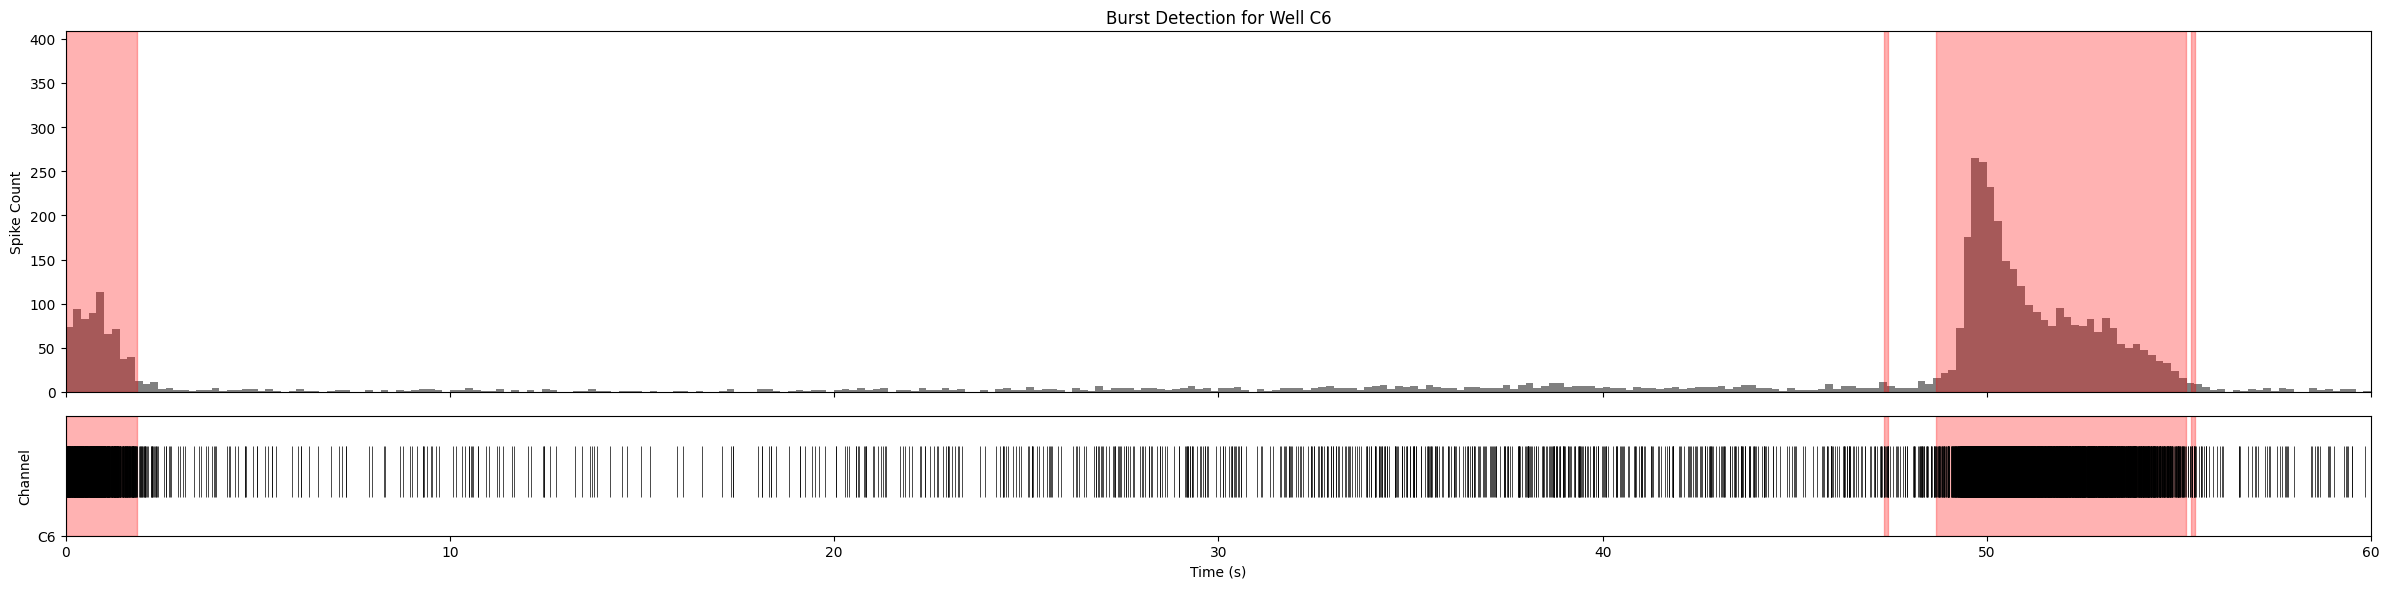

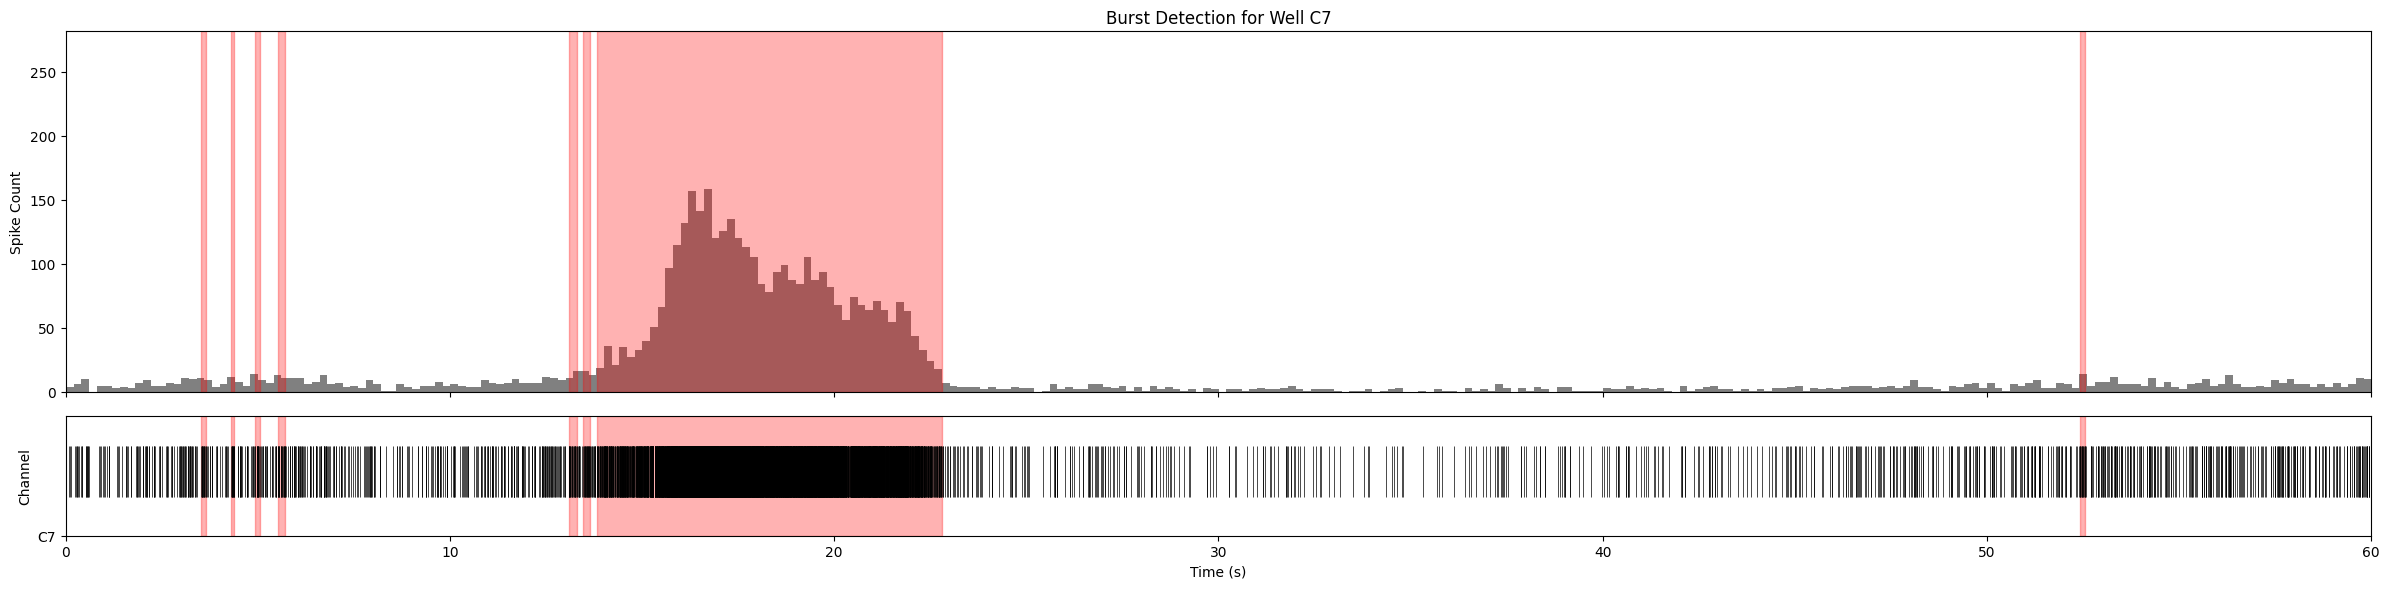

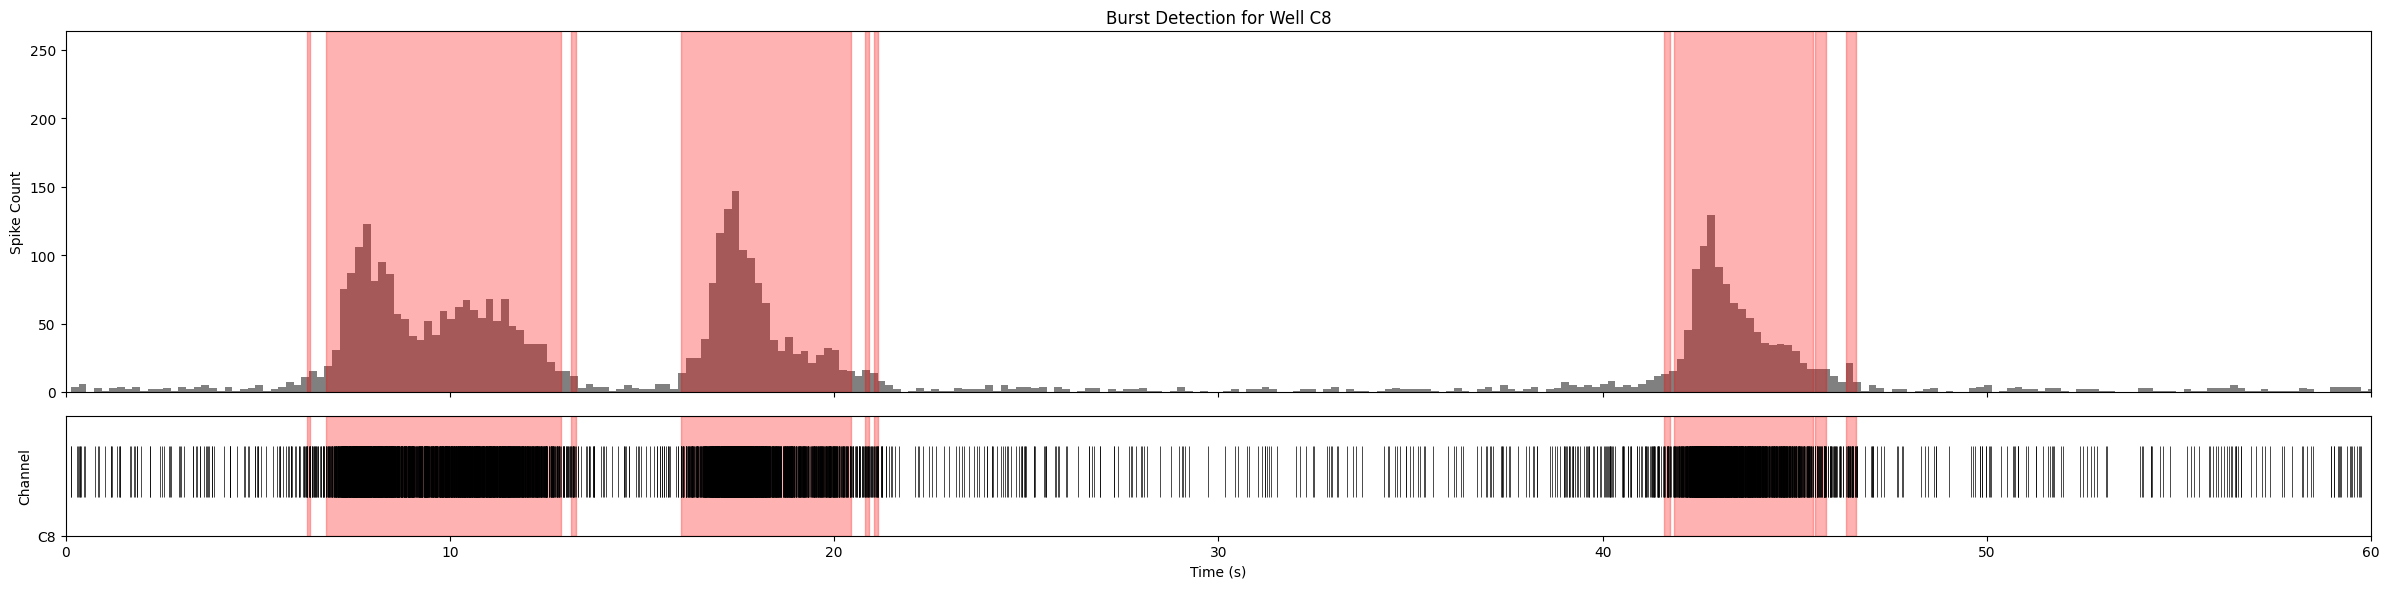

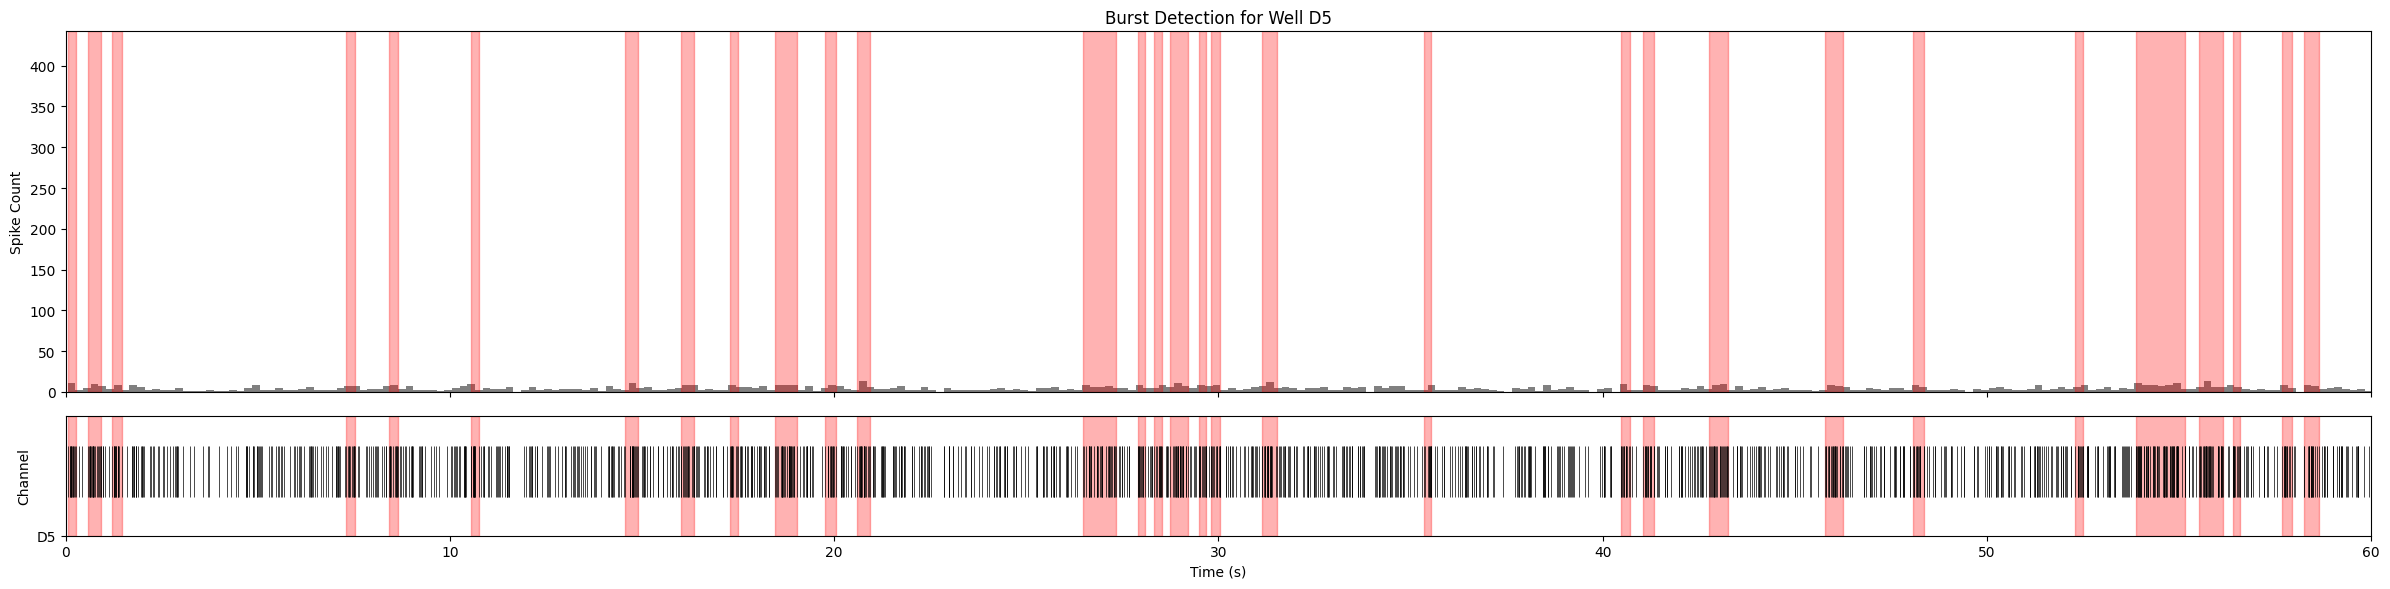

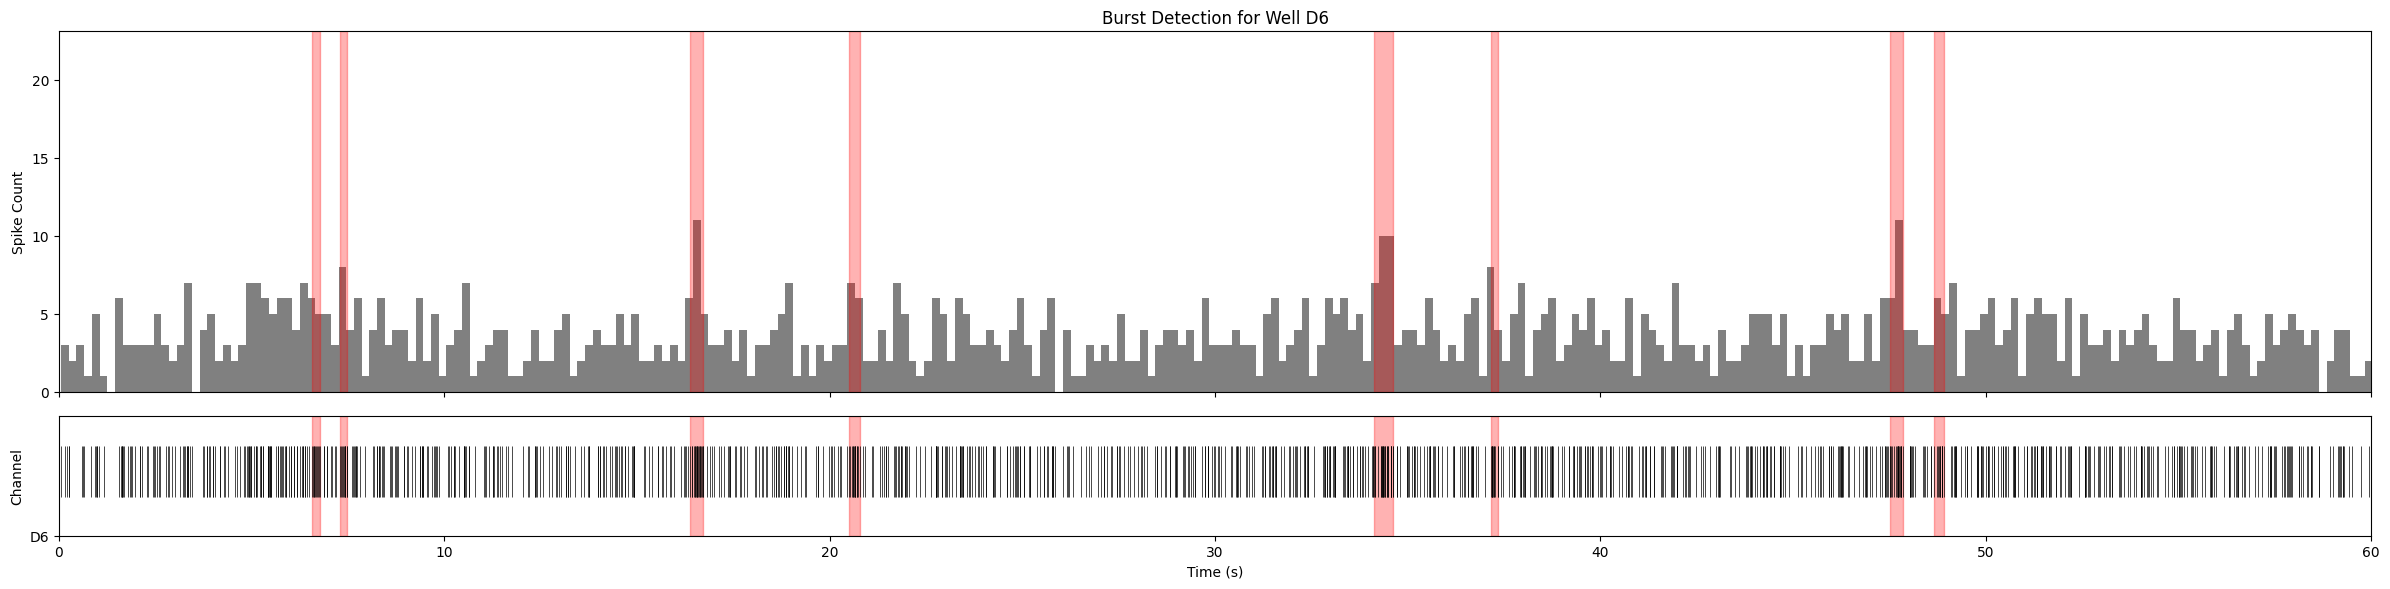

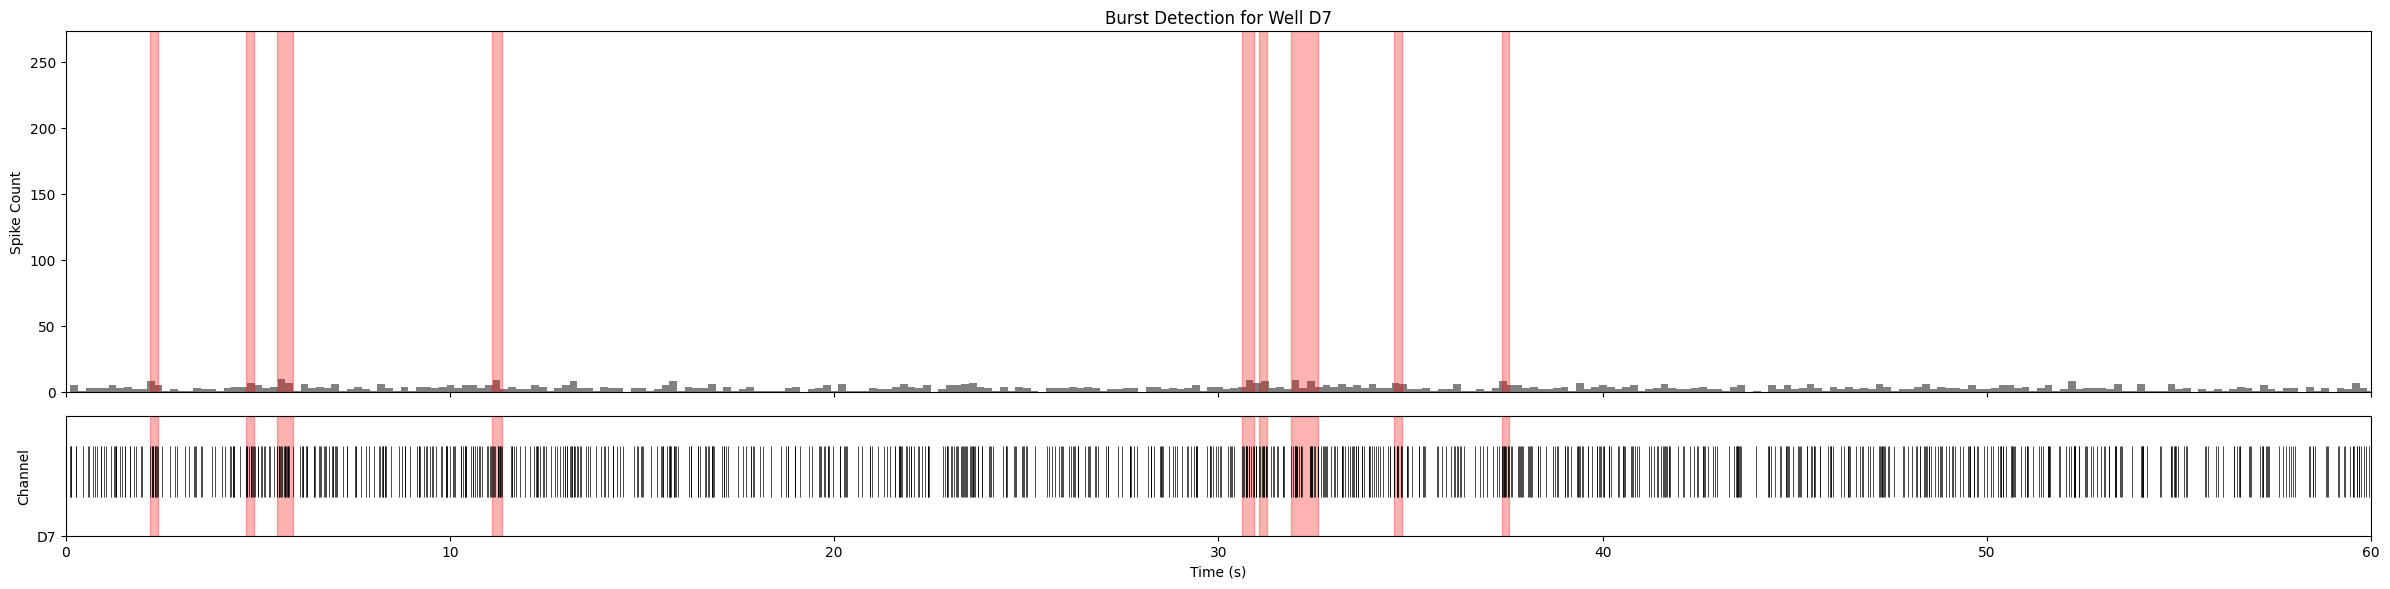

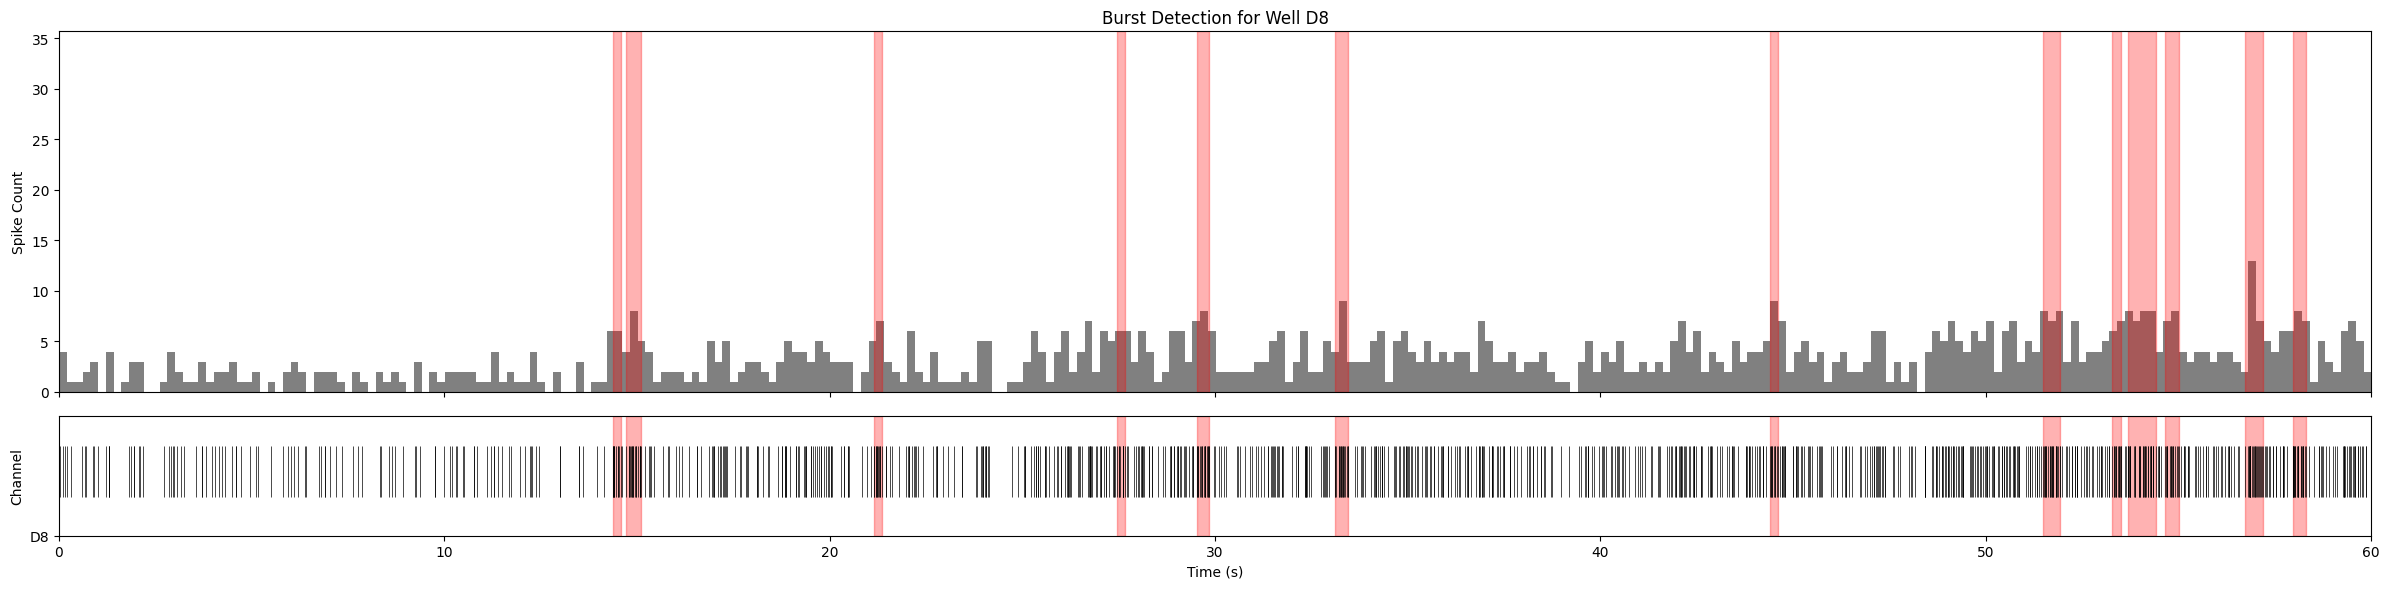

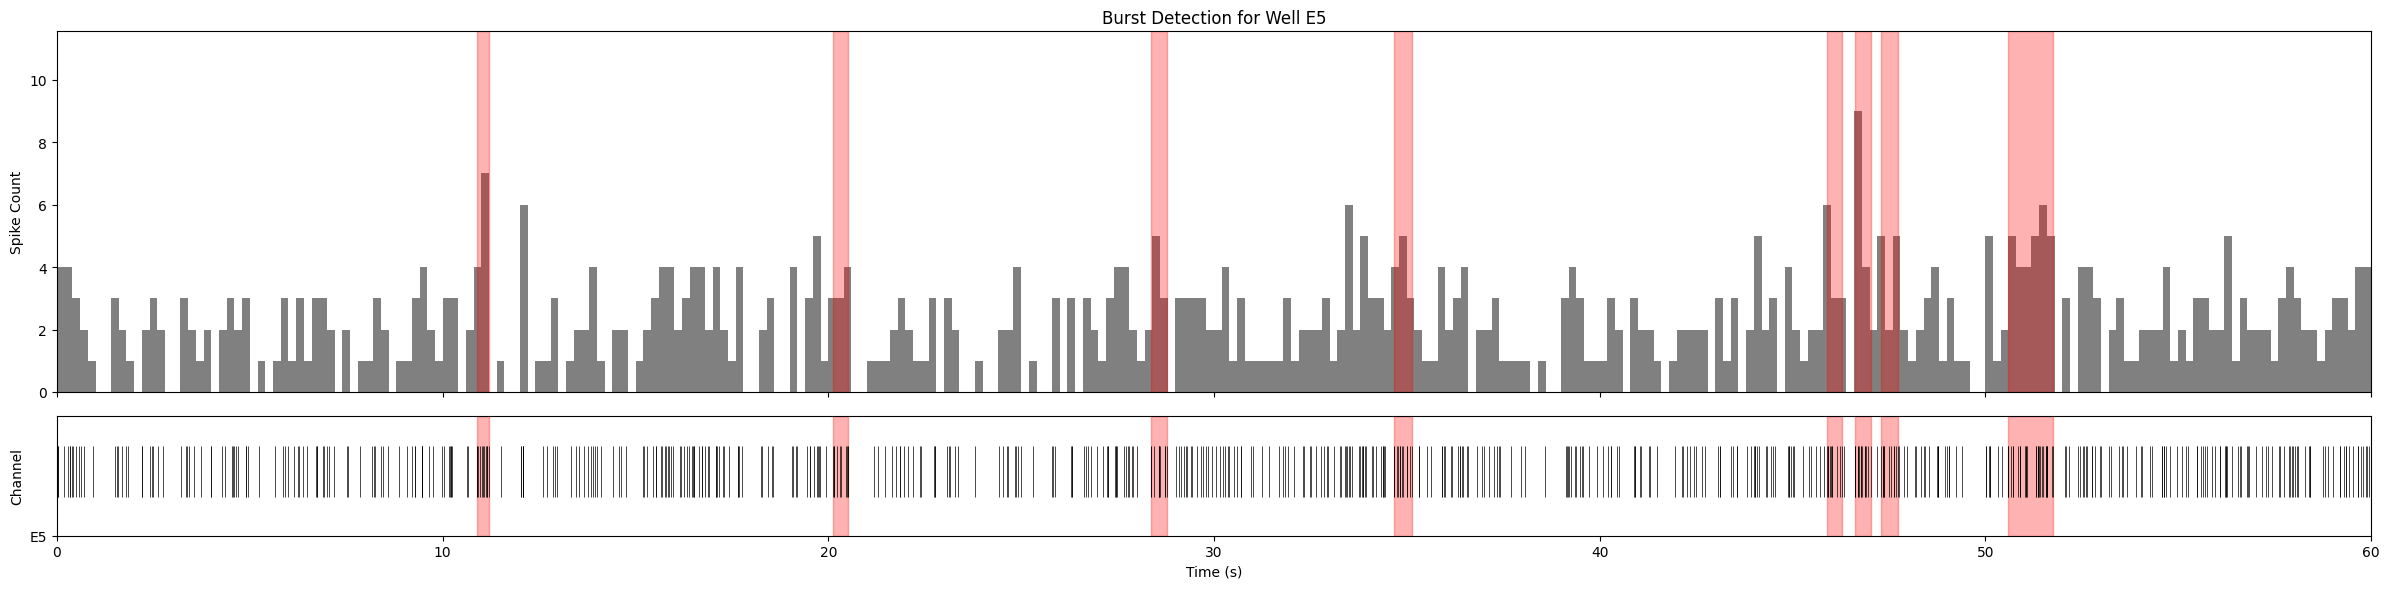

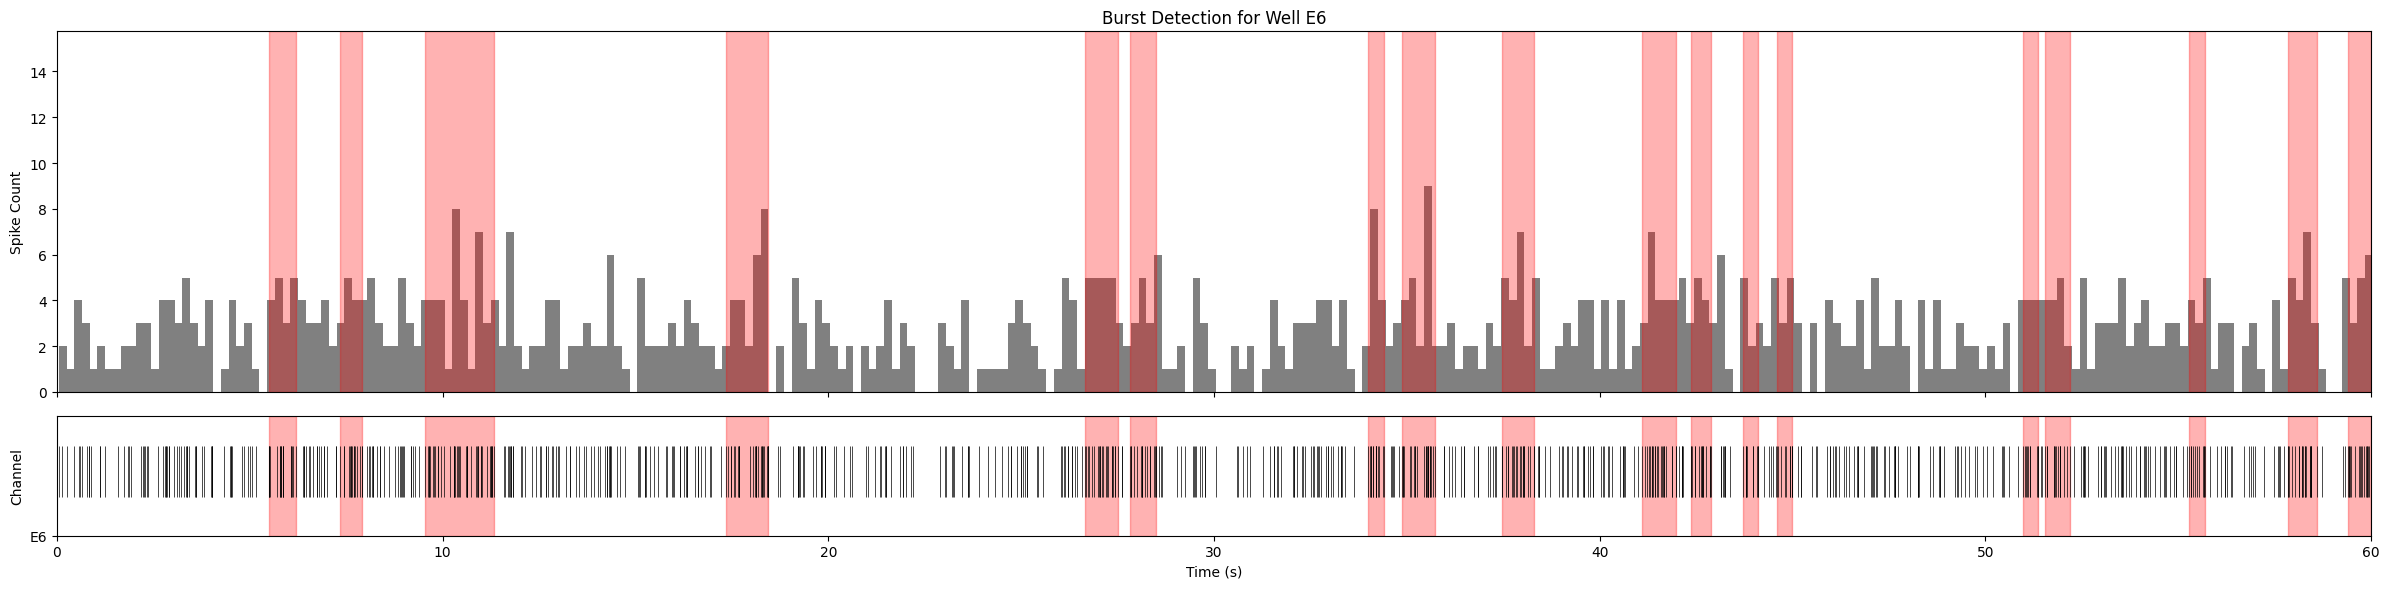

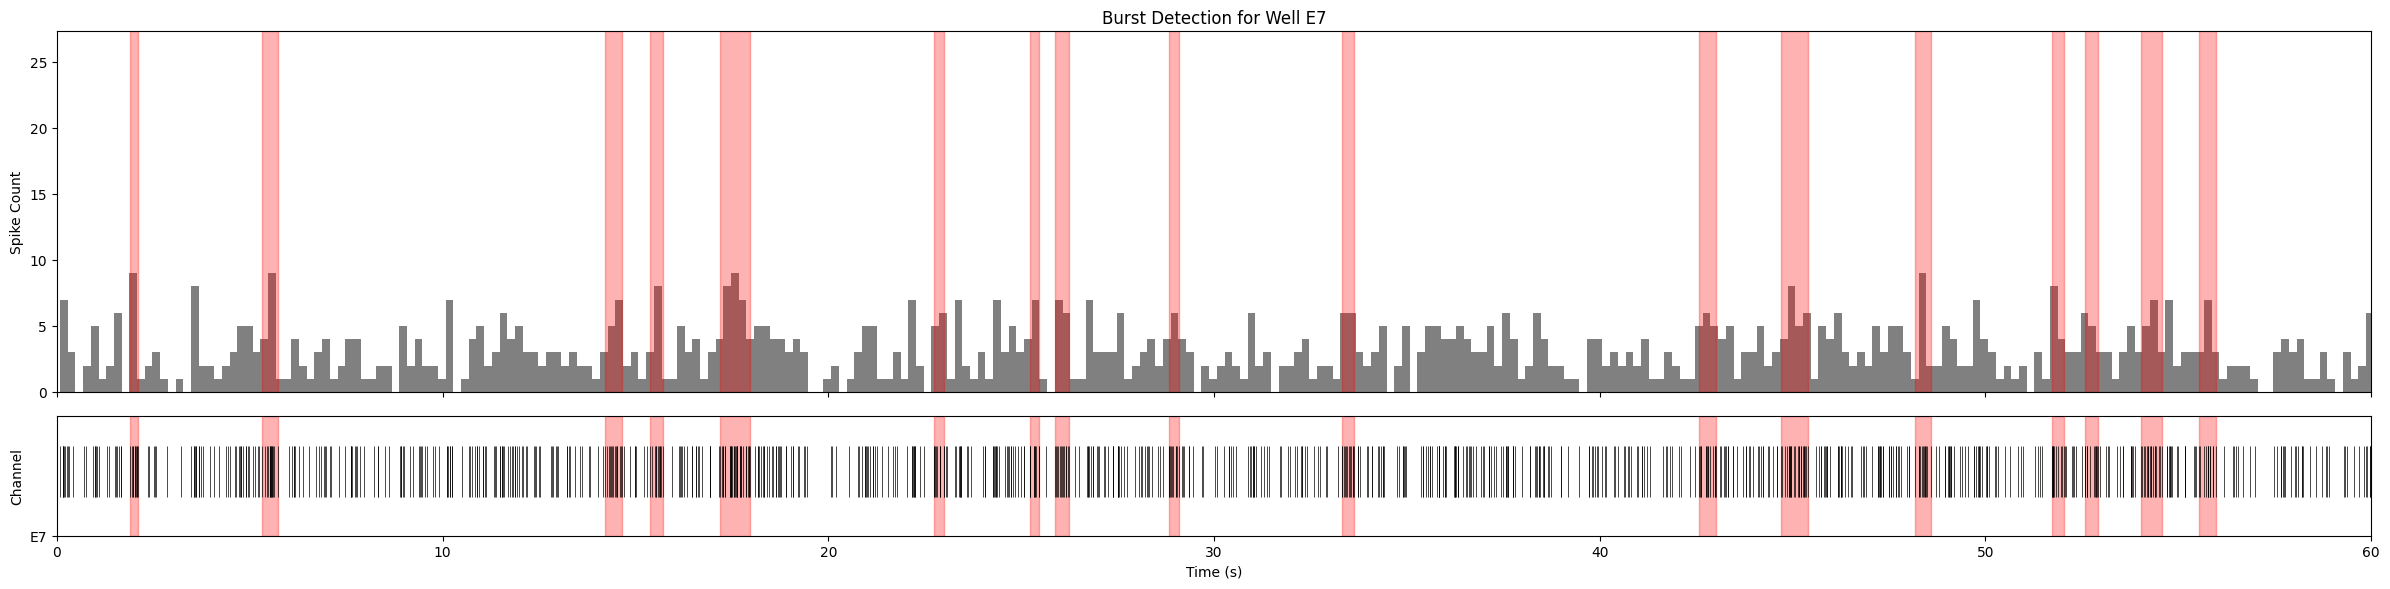

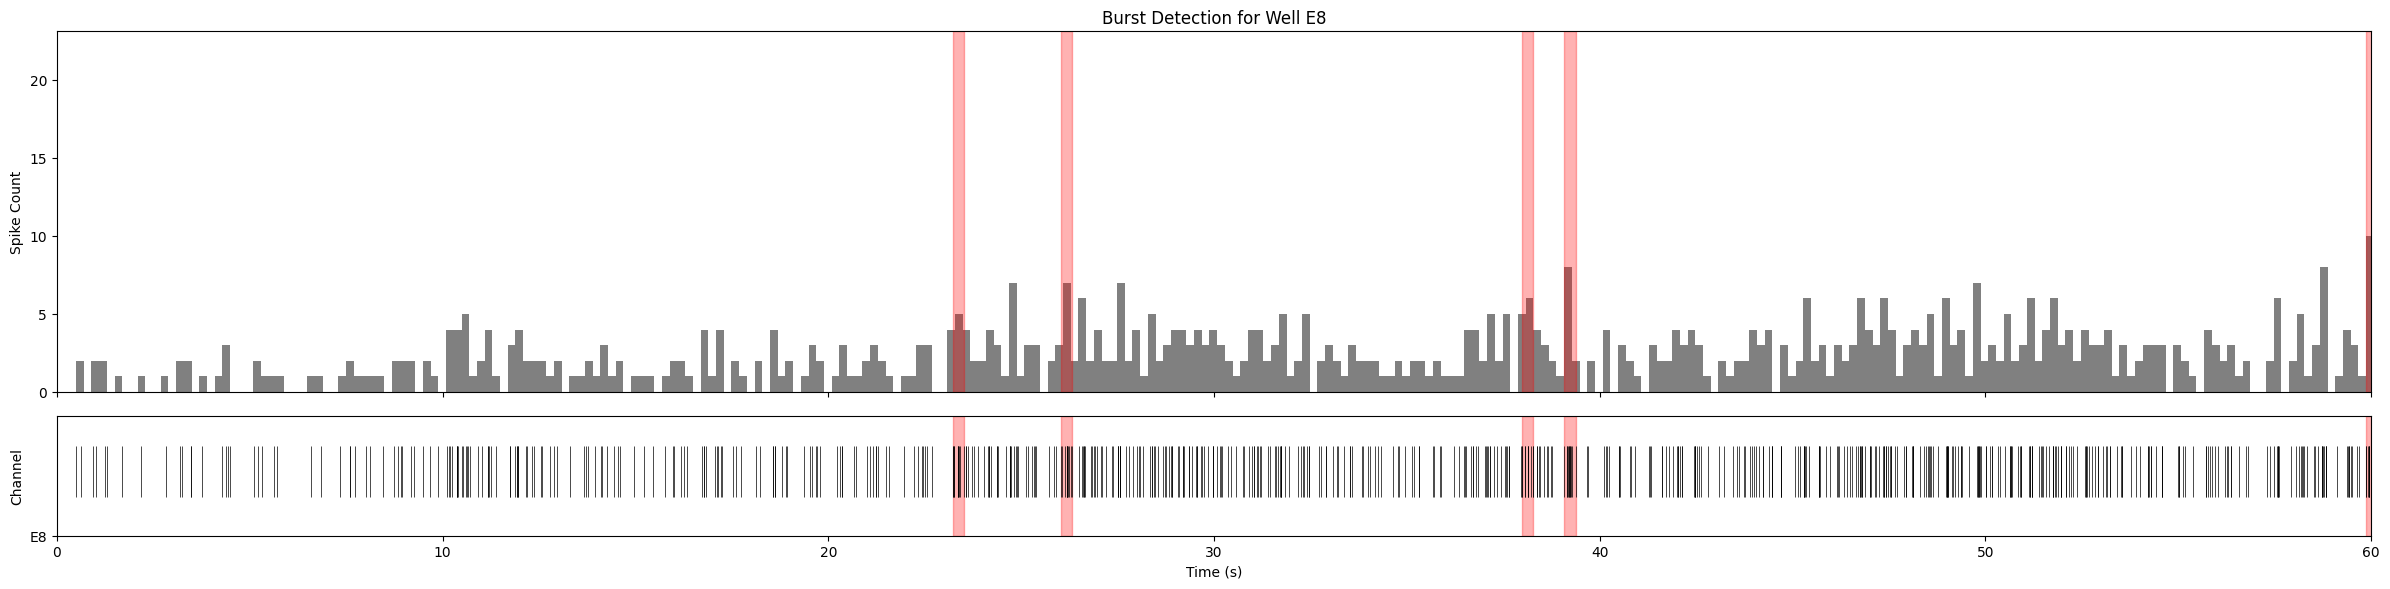

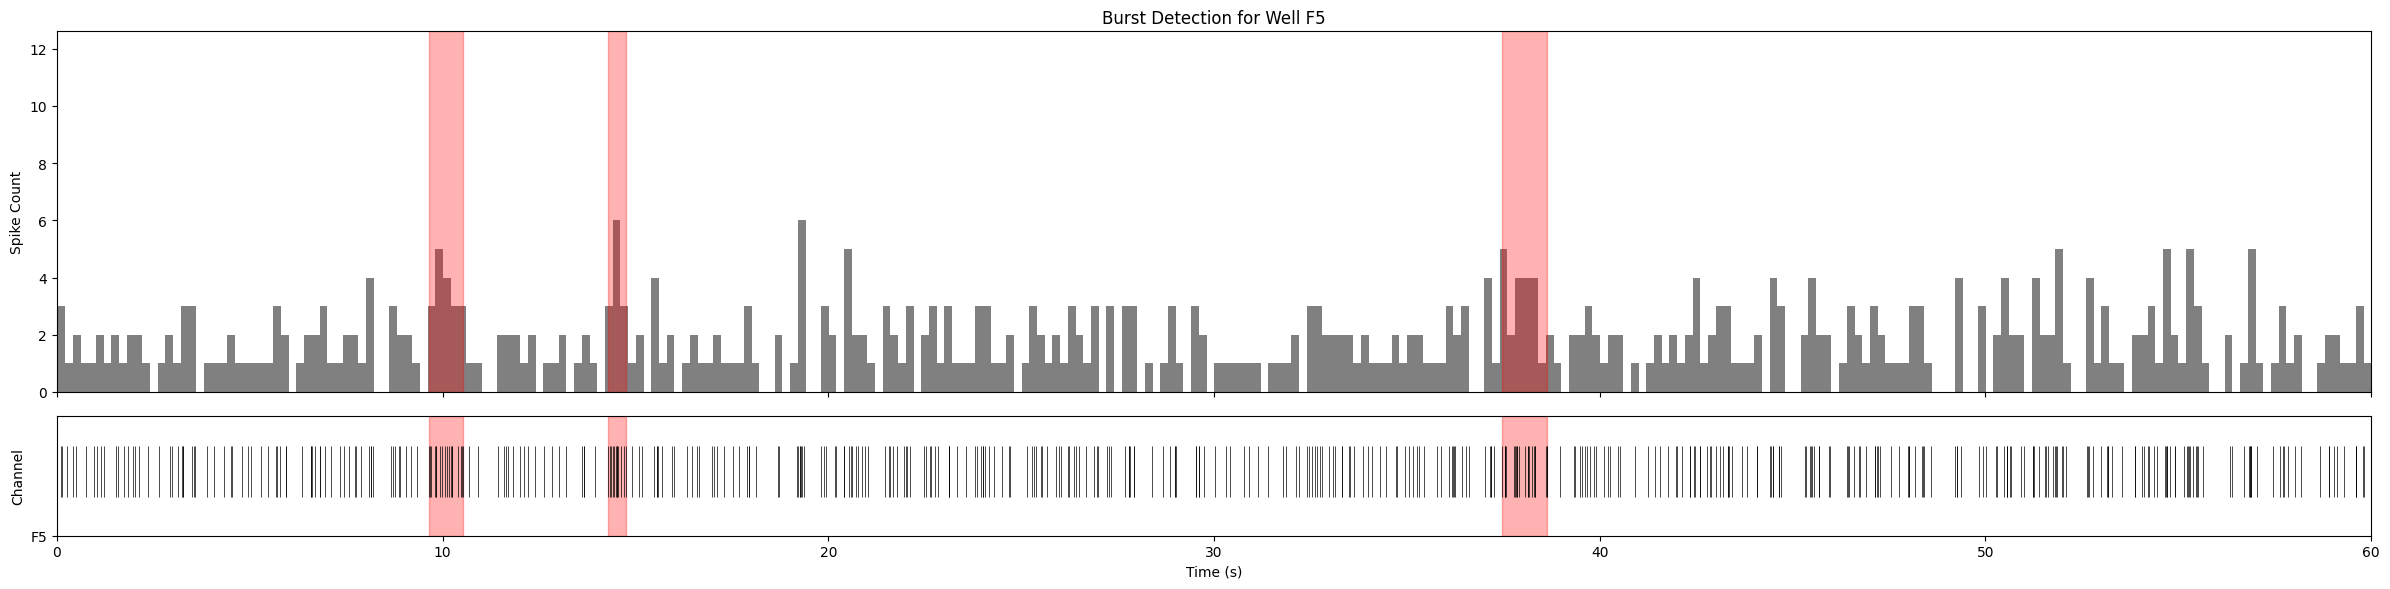

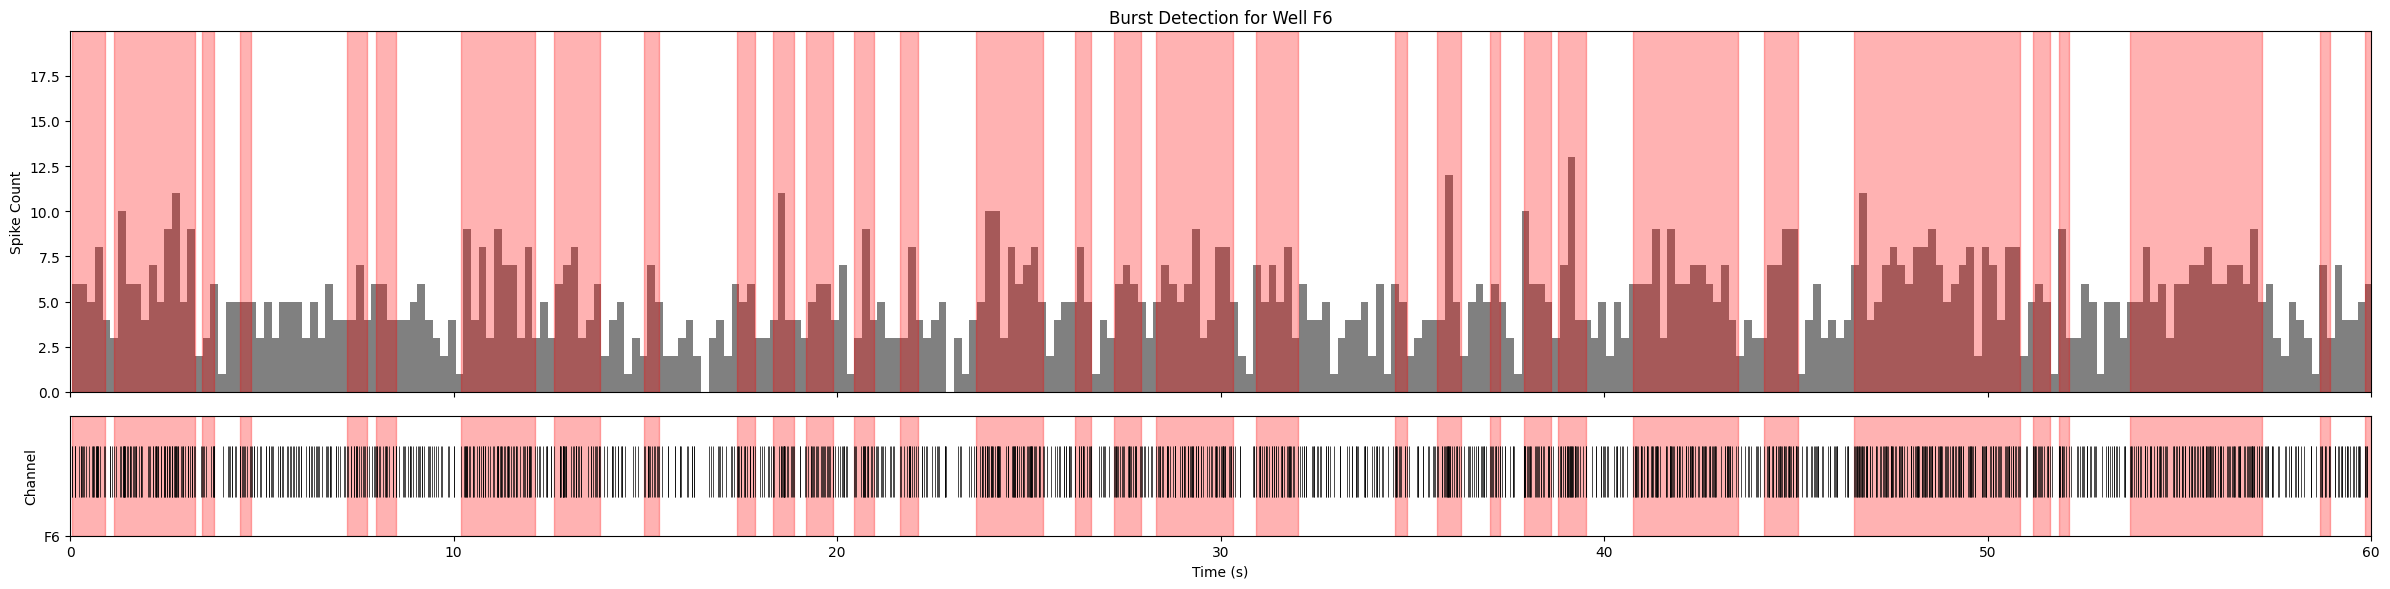

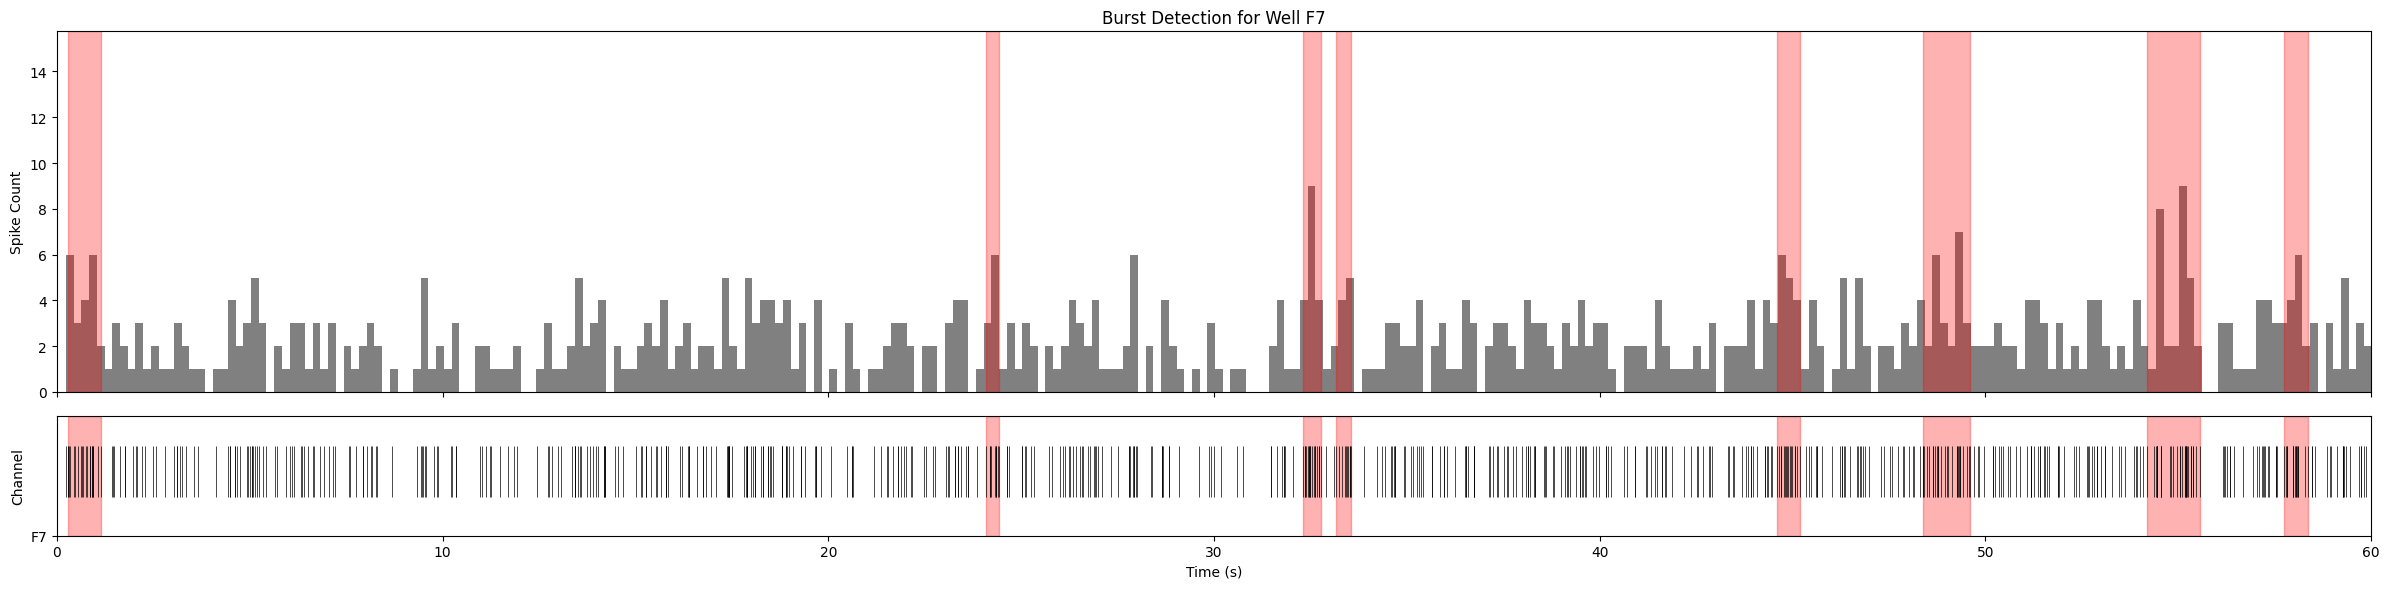

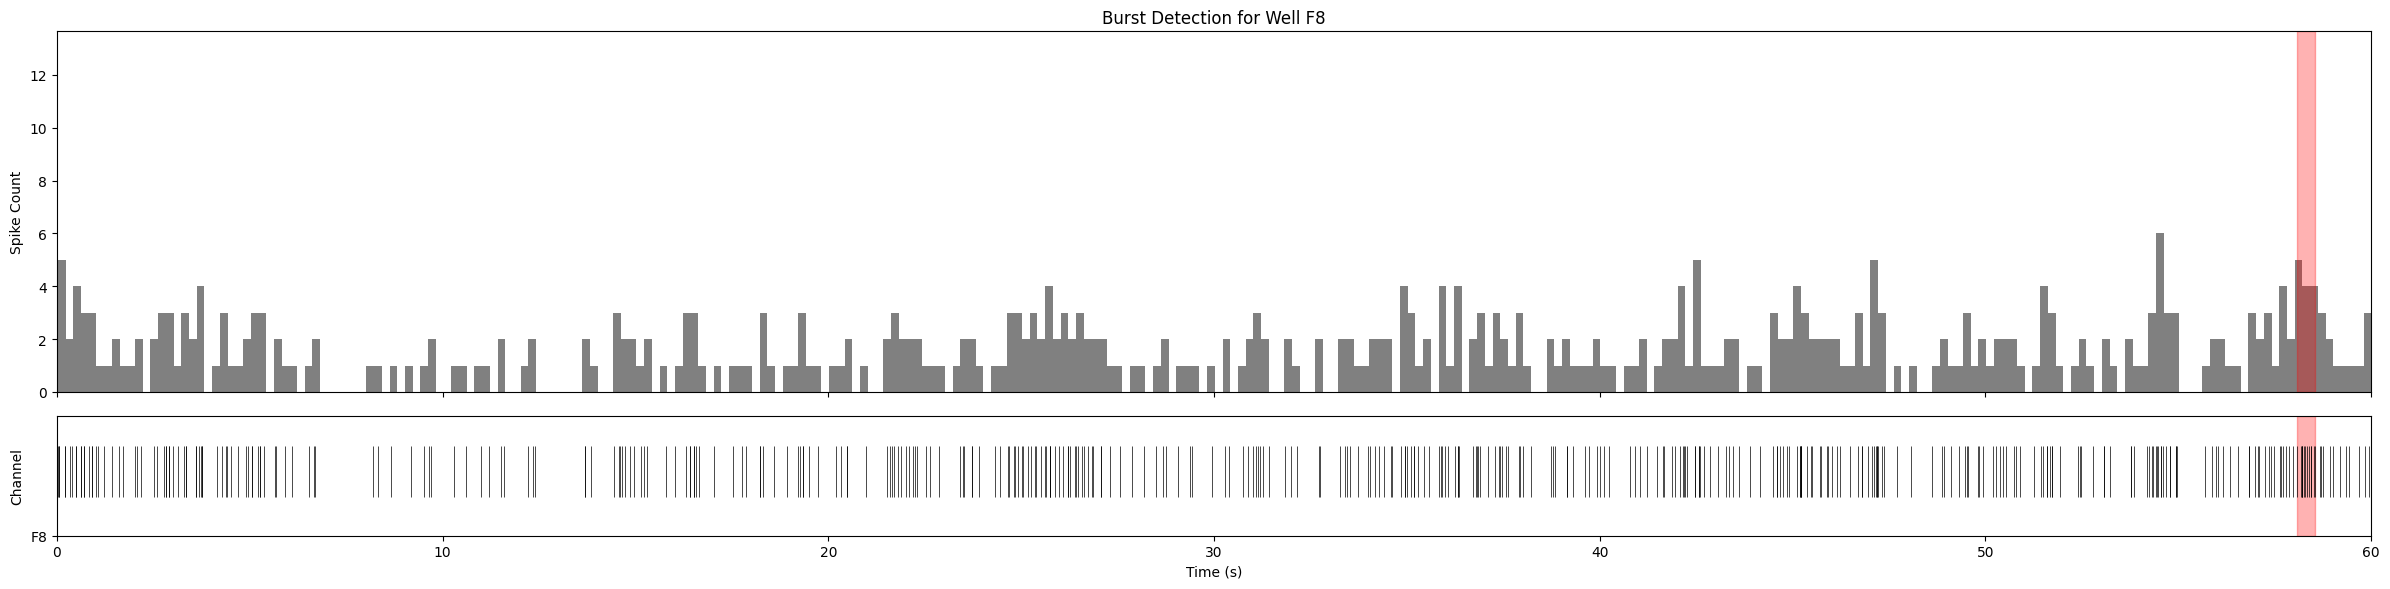

In [32]:
wells = [
        "A5", "A6", "A7", "A8", 
        "B5", "B6", "B7", "B8", 
        "C5", "C6", "C7", "C8",
        "D5", "D6", "D7", "D8",
        "E5", "E6", "E7", "E8",
        "F5", "F6", "F7", "F8"
]

for well in wells:

    recording_per_ch_filtered = recording_per_ch[recording_per_ch["well"] == well].reset_index(drop=True)
    spike_time_stamps = get_spike_time_stamps(recording_per_ch_filtered)
    
    bursts = BurstDetector.detect(spiketime=spike_time_stamps, n=n, threshold=threshold_dict[well])
    plot_histogram_with_bursts(spike_time_stamps, bursts, duration=duration, well=well, title=f"Burst Detection for Well {well}")